# Geopolitical Blocs at the UN: Do They Persist, What Causes Deviations, and Can They Predict How Canada Votes?

**Course:** SCS3523 Machine Learning  
**Team:** Jiahui Song, Manasi Kanade, Afsane Amiri, Bobbie Williams, Myriam Dilindi  
**Dataset:** United Nations General Assembly (UNGA) voting records — resolutions 1 (11 December 1946) through 80/246 (30 December 2025)

---

## Research Questions

This project investigates three connected questions about UN voting behaviour:

1. **Do geopolitical blocs exist and persist?** Can unsupervised learning identify stable voting coalitions among UN member states, and do countries stay in those coalitions over time?
2. **What causes deviations?** Which issues pull countries away from their bloc's consensus, and which countries are the most independent actors within their cluster?
3. **Can bloc membership predict how Canada votes?** Using each country's vote on a resolution as features, can we build a classifier that accurately predicts Canada's vote and does Canada always follow its bloc?

---

## Dataset

The raw dataset contains one row per country per resolution, recording each member state's vote as **Y** (yes), **N** (no), **A** (abstain), or **X** (absent). Resolutions are tagged with subject categories (e.g. `HUMAN RIGHTS`, `PALESTINE QUESTION`, `NUCLEAR DISARMAMENT`) that allow us to group votes by issue area.

For the main analysis we filter to **2000 onwards** to reflect the stabilised post-Cold War membership structure. A separate temporal analysis extends back to **1980** to capture decade-by-decade bloc transitions. Historical states (USSR, Yugoslavia, Czechoslovakia, etc.) are removed; country names are standardised across naming conventions.

Source: UN General Assembly voting records: https://digitallibrary.un.org/record/4060887?ln=en

---

## Introduction

Understanding how countries align on global issues is key to analyzing international relations. While formal alliances such as NATO provide visible partnerships, many geopolitical relationships are reflected more subtly through voting behavior in the United Nations General Assembly.

In this project, we analyze UN General Assembly voting records from the United Nations Digital Library to group countries based on similarities in their foreign policy behavior. Using machine learning clustering techniques, we identify latent voting blocs and examine whether these clusters correspond to known geopolitical alliances. We also explore how these alignments evolve over time and which global issues generate the most disagreement.

A key extension focuses on war-related dynamics. We study alignment patterns among U.S. allies and track how relationships—such as U.S.–Israel and U.S.–Ukraine—change across political periods, including during the presidency of Donald Trump. We also analyze long-term voting behavior of major global actors and include a forward-looking scenario to estimate how countries might vote on a hypothetical Iran-related resolution.

Finally, we provide a focused case study on Canada, examining its position within global voting blocs, its consistency over time, and whether its voting behavior can be predicted based on other countries.

---

## Notebook Structure

| Section | Method | Question addressed |
|---|---|---|
| Data Cleaning | Filtering, standardisation, vote encoding | — |
| Clustering | K-Means, Agglomerative, DBSCAN + PCA | Q1 — do blocs exist? |
| Topic & Temporal Analysis | Variance, transition matrices, cosine similarity | Q1 & Q2 — do they persist, what disrupts them? |
| UNSC Application | Logistic Regression (leave-one-out) | Q1 — real-world bloc prediction test |
| Climate Voting and Nato Cohesion | Cosine Similarity| Q2 — What disrupts them application exploration |
| Canada Vote Prediction | Random Forest, Decision Tree, Logistic Regression | Q3 — predicting Canada |
| Bloc & Topic Deep Dives | Alignment rates, deviation analysis, trend charts | Q2 & Q3 — deviations and Canada's independence |

---

##  Relevant resources

Literature: https://toc.library.ethz.ch/objects/pdf/z01_978-90-04-16714-8_01.pdf
Literature: https://gupea.ub.gu.se/server/api/core/bitstreams/bfa967e6-ff71-47ec-9a6b-f5af31e9d5bb/content
United Nations Digital Library

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import re as re
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the UN General Assembly voting dataset from the repository
df = pd.read_csv("data/2026_02_06_ga_voting.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Initial inspection
df.describe()

,undl_id,total_yes,total_no,total_abstentions,total_non_voting,total_ms
count,9.474340e+05,947434.000000,947434.000000,947434.000000,947434.000000,947434.000000
mean,1.083347e+06,128.987453,8.649133,18.207253,16.200528,172.044368
std,1.263825e+06,30.633032,13.703936,18.798762,12.047300,25.310736
min,2.783400e+05,14.000000,0.000000,0.000000,0.000000,51.000000
25%,2.845040e+05,111.000000,1.000000,4.000000,9.000000,158.000000
50%,6.329660e+05,129.000000,2.000000,12.000000,13.000000,185.000000
75%,7.650100e+05,152.000000,9.000000,26.000000,20.000000,193.000000
max,4.096575e+06,191.000000,71.000000,118.000000,127.000000,193.000000


In [ ]:
df.head()

,undl_id,ms_code,ms_name,ms_vote,date,session,resolution,draft,committee_report,meeting,title,agenda_title,subjects,vote_note,total_yes,total_no,total_abstentions,total_non_voting,total_ms,undl_link
0,507407,AFG,AFGHANISTAN,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
1,507407,ALB,ALBANIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
2,507407,DZA,ALGERIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
3,507407,AND,ANDORRA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
4,507407,AGO,ANGOLA,X,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407



 # **Data Preprocessing Pipeline**

Key Steps:

1.   Load and clean raw dataset
2.   Filter data for modern era (year >= 2000)
3.   Standardize country names
4.   Remove obsolete / historical countries
5.   Convert categorical votes into numerical format
6.   Handle multi-label subject categories
7.   Check and clean missing values


In [ ]:
# Create working copy (avoid modifying original dataset)
df_filtered = df.copy()
df_filtered.shape

(947434, 20)

In [ ]:
# Filter Data for Year >= 2000
# Focus on modern geopolitical structure for more stable analysis

df_filtered['date'] = pd.to_datetime(df_filtered['date'])
df_filtered['year'] = df_filtered['date'].dt.year

df_filtered = df_filtered[df_filtered['year'] >= 2000]

print("After year filter:", len(df_filtered))
df_filtered

After year filter: 429216


,undl_id,ms_code,ms_name,ms_vote,date,session,resolution,draft,committee_report,meeting,...,agenda_title,subjects,vote_note,total_yes,total_no,total_abstentions,total_non_voting,total_ms,undl_link,year
0,507407,AFG,AFGHANISTAN,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
1,507407,ALB,ALBANIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
2,507407,DZA,ALGERIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
3,507407,AND,ANDORRA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
4,507407,AGO,ANGOLA,X,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947429,4088513,VEN,VENEZUELA (BOLIVARIAN REPUBLIC OF),X,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025
947430,4088513,VNM,VIET NAM,Y,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025
947431,4088513,YEM,YEMEN,Y,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025
947432,4088513,ZMB,ZAMBIA,X,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025


In [ ]:
# Normalize country naming inconsistencies across dataset
country_map = {
    "IVORY COAST": "COTE D'IVOIRE",
    "CÔTE D'IVOIRE": "COTE D'IVOIRE",
    "IRAN (ISLAMIC REPUBLIC OF)": "IRAN",
    "VENEZUELA (BOLIVARIAN REPUBLIC OF)": "VENEZUELA",
    "SYRIAN ARAB REPUBLIC": "SYRIA",
    "BURMA": "MYANMAR",
    "SWAZILAND": "ESWATINI",
    "CZECH REPUBLIC": "CZECHIA",
    "TURKEY": "TURKIYE",
    "TÜRKİYE": "TURKIYE",
    "TÜRKÝYE": "TURKIYE",
    "CAPE VERDE": "CABO VERDE",
    "BOLIVIA (PLURINATIONAL STATE OF)": "BOLIVIA",
    "NETHERLANDS (KINGDOM OF THE)": "NETHERLANDS",
    "CONGO": "REPUBLIC OF THE CONGO",
    "THE FORMER YUGOSLAV REPUBLIC OF MACEDONIA": "NORTH MACEDONIA",
}

df_filtered['ms_name'] = df_filtered['ms_name'].replace(country_map)

print("After country mapping:", df_filtered['ms_name'].nunique())

After country mapping: 196


In [ ]:
# Remove Historical / Invalid Countries
invalid = [
    "USSR", "YUGOSLAVIA", "CZECHOSLOVAKIA",
    "BYELORUSSIAN SSR", "UKRAINIAN SSR",
    "GERMAN DEMOCRATIC REPUBLIC",
    "SERBIA AND MONTENEGRO",
    "UNITED ARAB REPUBLIC",
    "ZAIRE", "UPPER VOLTA", "DAHOMEY",
    "LIBYAN ARAB JAMAHIRIYA"
]

df_filtered = df_filtered[~df_filtered['ms_name'].isin(invalid)]

print("After removing invalid:", df_filtered['ms_name'].nunique())

After removing invalid: 193


In [ ]:
# pre-explode with vote_num AND subject_split, not yet exploded
# this is a copy that will be used for secondary analysis (supervised)
df_pre_explode = df_filtered.copy()

In [ ]:
# Clean and Encode Voting Data

# Remove whitespace and ensure consistent formatting
df_filtered['ms_vote'] = df_filtered['ms_vote'].astype(str).str.strip()

df_filtered['ms_vote'].value_counts()

# Drop duplicate voting records (if any)
df_filtered = df_filtered.drop_duplicates()

# Map categorical votes to numeric values for modeling
# Y = Yes (1), N = No (-1), A/X = Neutral/Absent (0)
map_votes = { 'Y' : 1, 'N': -1, 'A': 0, 'X': 0}

# Keep only valid vote categories
df_filtered = df_filtered[df_filtered['ms_vote'].isin(map_votes.keys())]
df_filtered['vote_num'] = df_filtered['ms_vote'].map(map_votes)

print("Missing vote_num:", df_filtered['vote_num'].isna().sum())

Missing vote_num: 0


In [ ]:
# Handle Subjects

# Split subjects into multiple categories
df_filtered["subject_split"] = df_filtered["subjects"].str.split("|")

# explode into multiple rows
df_filtered = df_filtered.explode("subject_split")

print("After explode:", len(df_filtered))

After explode: 488890


In [ ]:
# Check Missing Values
missing_values = df_filtered.isnull().sum().sort_values(ascending=False)

missing_percent = (df_filtered.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
})

print(missing_summary)


                   missing_count  missing_percent
vote_note                 488890       100.000000
committee_report           81850        16.742007
draft                      38306         7.835300
subjects                     191         0.039068
subject_split                191         0.039068
ms_code                        0         0.000000
undl_id                        0         0.000000
resolution                     0         0.000000
session                        0         0.000000
date                           0         0.000000
ms_vote                        0         0.000000
ms_name                        0         0.000000
title                          0         0.000000
agenda_title                   0         0.000000
meeting                        0         0.000000
total_yes                      0         0.000000
total_no                       0         0.000000
total_non_voting               0         0.000000
total_abstentions              0         0.000000


In [ ]:
# Drop Irrelevant Columns
drop_cols = ['undl_id', 'undl_link', 'draft', 'meeting', 'committee_report', 'vote_note']
df_filtered = df_filtered.drop(drop_cols, axis=1)
df_filtered

,ms_code,ms_name,ms_vote,date,session,resolution,title,agenda_title,subjects,total_yes,total_no,total_abstentions,total_non_voting,total_ms,year,vote_num,subject_split
0,AFG,AFGHANISTAN,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,1,PALESTINE QUESTION
1,ALB,ALBANIA,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,1,PALESTINE QUESTION
2,DZA,ALGERIA,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,1,PALESTINE QUESTION
3,AND,ANDORRA,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,1,PALESTINE QUESTION
4,AGO,ANGOLA,X,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,0,PALESTINE QUESTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947429,VEN,VENEZUELA,X,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,0,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...
947430,VNM,VIET NAM,Y,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,1,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...
947431,YEM,YEMEN,Y,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,1,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...
947432,ZMB,ZAMBIA,X,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,0,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...


In [ ]:
df_filtered['subject_split'].unique()

array(['PALESTINE QUESTION', 'ARMS RACE--OUTER SPACE',
       'ECONOMIC ASSISTANCE',
       'ECONOMIC ASSISTANCE--DEMOCRATIC REPUBLIC OF THE CONGO',
       'TERRITORIES OCCUPIED BY ISRAEL--SETTLEMENT POLICY',
       'INFORMATION--INTERNATIONAL SECURITY', 'BALLISTIC MISSILES',
       'SOUTHERN HEMISPHERE--NUCLEAR-WEAPON-FREE ZONES',
       'PEACE--CONVENTIONAL DISARMAMENT',
       'CENTRAL ASIAN--UCLEAR-WEAPON-FREE ZONE',
       'CONVENTIONAL ARMS--REGIONAL PROGRAMMES',
       'DISARMAMENT--GENERAL AND COMPLETE',
       'ARMS TRANSFERS--TRANSPARENCY', 'MIDDLE EAST SITUATION',
       'HUMAN RIGHTS--REPORTS', 'HUMAN RIGHTS--IRAQ',
       'INTERNATIONAL TRADE', 'MILLENNIUM SUMMIT--CONFERENCES',
       'MIDDLE EAST--NUCLEAR PROLIFERATION',
       'HUMAN RIGHTS--IRAN (ISLAMIC REPUBLIC OF)', 'UNRWA--ACTIVITIES',
       'TERRITORIES OCCUPIED BY ISRAEL--HUMAN RIGHTS--REPORTS',
       'NON-SELF-GOVERNING TERRITORIES--ECONOMIC INTERESTS',
       'DECOLONIZATION',
       'ORGANIZATION FOR SECURITY

In [ ]:
# Ensure key analytical columns have no missing values

df_filtered = df_filtered.dropna(subset=['vote_num', 'subject_split'])

# **Part 1: Unsupervised Learning: Clustering**

 ## Choose Clustering Method

Key Design Choice: Original Space vs PCA

A central methodological decision in this analysis is how to select the optimal number of clusters (k).

We explicitly:

Choose k in the ORIGINAL scaled feature space
Use PCA only for visualization and robustness checks
Why NOT choose k after PCA?

Principal Component Analysis (PCA) reduces dimensionality by projecting data into a lower-dimensional space that maximizes variance. However:

Problem: PCA compresses information It can distort pairwise distances Clustering metrics depend heavily on distances: Silhouette score Inertia (within-cluster SSE) Consequence:

If k is chosen after PCA:

We optimize clustering in a transformed (and potentially distorted) space, not the original behavioral structure.

Final Decision Rationale

We therefore:

Select k using the original standardized feature space Preserves true geopolitical distance structure Ensures clustering reflects actual voting similarity
Use PCA only for: Visualization (2D projection) Robustness checks Interpretability of clusters

### Step 1: Construct Country–Topic Voting Matrix

In [ ]:
# Construct country × topic voting matrix

# Each row = country
# Each column = UN topic
# Values = average vote behavior across resolutions
# (-1 = No, 0 = Abstain/neutral, 1 = Yes)

country_subject_votes = df_filtered.pivot_table(
    index="ms_name",
    columns="subject_split",
    values="vote_num",
    aggfunc="mean"
).fillna(0)

print("Final shape:", country_subject_votes.shape)

country_subject_votes.head()

Final shape: (193, 283)


subject_split,2030 AGENDA--PROGRAMME IMPLEMENTATION,AFGHANISTAN SITUATION,AFRICA--DEVELOPMENT,AFRICA--SUSTAINABLE DEVELOPMENT--PARTNERSHIP,AFRICAN UNION--UN,AGEING PERSONS,AGEING PERSONS--2ND WORLD ASSEMBLY (2002),AGENDA 21--PROGRAMME IMPLEMENTATION,ALBINISM,AMERICAN SAMOA QUESTION,...,UNITED STATES VIRGIN ISLANDS QUESTION,UNRWA--ACTIVITIES,WEAPONS OF MASS DESTRUCTION,WEAPONS--OUTER SPACE,WESTERN SAHARA QUESTION,WOMEN MIGRANT WORKERS,WOMEN'S ADVANCEMENT,WOMEN'S ADVANCEMENT--CONFERENCES,WOMEN--DISARMAMENT,YOUTH
ms_name,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0.5,0.8,1.000000,1.000000,0.0,0.0,0.0,0.714286,1.0,0.5,...,0.0,0.830189,1.000000,0.833333,0.0,0.0,0.416667,0.0,1.0,0.0
ALBANIA,1.0,1.0,0.000000,0.000000,1.0,0.0,0.0,0.000000,1.0,1.0,...,1.0,0.792453,1.000000,-0.583333,0.0,1.0,0.500000,1.0,1.0,1.0
ALGERIA,1.0,1.0,1.000000,1.000000,1.0,0.0,0.0,0.857143,1.0,1.0,...,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.750000,1.0,1.0,1.0
ANDORRA,1.0,1.0,0.333333,0.333333,1.0,0.0,0.0,0.000000,1.0,1.0,...,1.0,1.000000,1.000000,-0.333333,0.0,1.0,1.000000,1.0,1.0,1.0
ANGOLA,0.5,0.8,1.000000,1.000000,1.0,0.0,0.0,1.000000,1.0,1.0,...,1.0,0.924528,0.857143,0.916667,1.0,1.0,0.750000,1.0,1.0,1.0


In [ ]:
# Sanity checks

print("Number of countries:", country_subject_votes.shape[0])
print("Number of topics:", country_subject_votes.shape[1])

print("\nSample countries:")
print(country_subject_votes.index[:10])

Number of countries: 193
Number of topics: 283

Sample countries:
Index(['AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'ANDORRA', 'ANGOLA',
       'ANTIGUA AND BARBUDA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA'],
      dtype='object', name='ms_name')


### Step 3: Feature Scaling

In [ ]:
# Standardize features before clustering

# Important because:
# - Topics have different variance
# - Distance-based models are scale-sensitive
X = country_subject_votes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Step 4: Generalized Inertia Function

In [ ]:
# Custom inertia computation (model-agnostic)

# Used for clustering methods that do not expose inertia
# (e.g., AgglomerativeClustering, DBSCAN)

def compute_inertia_general(X, labels):
    inertia = 0
    unique_labels = np.unique(labels)

    for label in unique_labels:
        if label == -1:  # skip noise (DBSCAN)
            continue

        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)

        inertia += np.sum((cluster_points - centroid) ** 2)

    return inertia


### Step 5: Model Evaluation Across k

In [ ]:
# evaluation loop
max_K = 10

results = {
    "kmeans": {"inertia": [], "silhouette": []},
    "agglo_ward": {"inertia": [], "silhouette": []},
    "agglo_average": {"inertia": [], "silhouette": []},
    "agglo_complete": {"inertia": [], "silhouette": []},
}

for k in range(2, max_K + 1):

    print(f"\n=== k = {k} ===")

    # ---------- KMEANS ----------
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_labels = kmeans.fit_predict(X_scaled)

    inertia_k = kmeans.inertia_
    sil_k = silhouette_score(X_scaled, k_labels)

    results["kmeans"]["inertia"].append(inertia_k)
    results["kmeans"]["silhouette"].append(sil_k)

    print(f"KMeans → inertia: {inertia_k:.2f}, silhouette: {sil_k:.3f}")

    # ---------- AGGLOMERATIVE ----------
    for linkage in ["ward", "average", "complete"]:

        agglo = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        a_labels = agglo.fit_predict(X_scaled)

        inertia_a = compute_inertia_general(X_scaled, a_labels)
        sil_a = silhouette_score(X_scaled, a_labels)

        results[f"agglo_{linkage}"]["inertia"].append(inertia_a)
        results[f"agglo_{linkage}"]["silhouette"].append(sil_a)

        print(f"Agglo-{linkage} → inertia: {inertia_a:.2f}, silhouette: {sil_a:.3f}")



=== k = 2 ===
KMeans → inertia: 41128.53, silhouette: 0.305
Agglo-ward → inertia: 42411.86, silhouette: 0.267
Agglo-average → inertia: 48076.68, silhouette: 0.641
Agglo-complete → inertia: 48076.68, silhouette: 0.641

=== k = 3 ===
KMeans → inertia: 33357.55, silhouette: 0.318
Agglo-ward → inertia: 34263.38, silhouette: 0.305
Agglo-average → inertia: 46138.81, silhouette: 0.311
Agglo-complete → inertia: 37191.08, silhouette: 0.288

=== k = 4 ===
KMeans → inertia: 29802.59, silhouette: 0.321
Agglo-ward → inertia: 30718.69, silhouette: 0.314
Agglo-average → inertia: 40990.73, silhouette: 0.316
Agglo-complete → inertia: 30426.58, silhouette: 0.322

=== k = 5 ===
KMeans → inertia: 27035.62, silhouette: 0.310
Agglo-ward → inertia: 27570.79, silhouette: 0.263
Agglo-average → inertia: 40571.98, silhouette: 0.312
Agglo-complete → inertia: 29398.76, silhouette: 0.318

=== k = 6 ===
KMeans → inertia: 25158.05, silhouette: 0.292
Agglo-ward → inertia: 25590.78, silhouette: 0.262
Agglo-average → i

### Step 6: DBSCAN

DBSCAN was evaluated as a density-based alternative; however, it failed to identify meaningful clusters in the high-dimensional voting space, as the data does not exhibit clear density-separated structures. This confirms that UN voting behavior is better represented as a continuous similarity spectrum rather than compact density clusters.

In [ ]:
# DBSCAN parameter sensitivity test

dbscan_results = []

eps_values = [0.3, 0.5, 0.7, 1.0]

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    db_labels = db.fit_predict(X_scaled)

    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

    if n_clusters > 1:
        sil = silhouette_score(X_scaled[db_labels != -1], db_labels[db_labels != -1])
    else:
        sil = np.nan

    print(f"DBSCAN (eps={eps}) → clusters: {n_clusters}, silhouette: {sil}")

    dbscan_results.append((eps, n_clusters, sil))


DBSCAN (eps=0.3) → clusters: 0, silhouette: nan
DBSCAN (eps=0.5) → clusters: 0, silhouette: nan
DBSCAN (eps=0.7) → clusters: 0, silhouette: nan
DBSCAN (eps=1.0) → clusters: 0, silhouette: nan


### Step 7: Evaluation Visualization

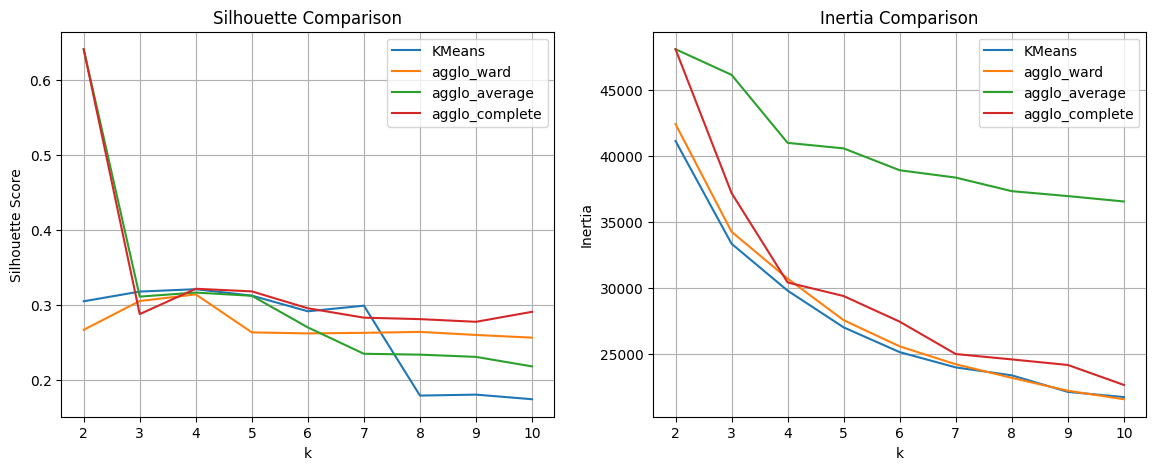

In [ ]:
# Visual comparison of clustering performance

k_range = range(2, max_K + 1)

plt.figure(figsize=(14,5))

# ---- Silhouette ----
plt.subplot(1,2,1)
plt.plot(k_range, results["kmeans"]["silhouette"], label="KMeans")

for key in ["agglo_ward", "agglo_average", "agglo_complete"]:
    plt.plot(k_range, results[key]["silhouette"], label=key)

plt.title("Silhouette Comparison")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid()

# ---- Inertia ----
plt.subplot(1,2,2)
plt.plot(k_range, results["kmeans"]["inertia"], label="KMeans")

for key in ["agglo_ward", "agglo_average", "agglo_complete"]:
    plt.plot(k_range, results[key]["inertia"], label=key)

plt.title("Inertia Comparison")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.legend()
plt.grid()

plt.show()


### Step 8: PCA for Visualization (95% variance)

In [ ]:
# PCA for dimensionality reduction (NOT for clustering)

# Select most informative topics first
top_topics = country_subject_votes.var().sort_values(ascending=False).head(100).index
X = country_subject_votes[top_topics]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce dimensions while preserving 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")
print("Explained variance ratio sum:", sum(pca.explained_variance_ratio_))

Original number of features: 100
Reduced number of features after PCA: 37
Explained variance ratio sum: 0.9504308155291527


### Step 9: Clustering in PCA Space (Visualization Only)

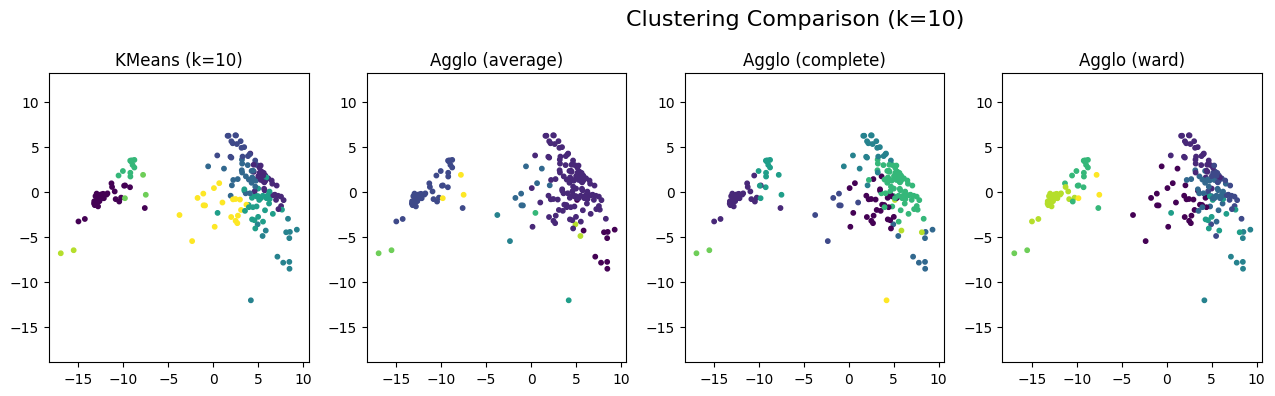

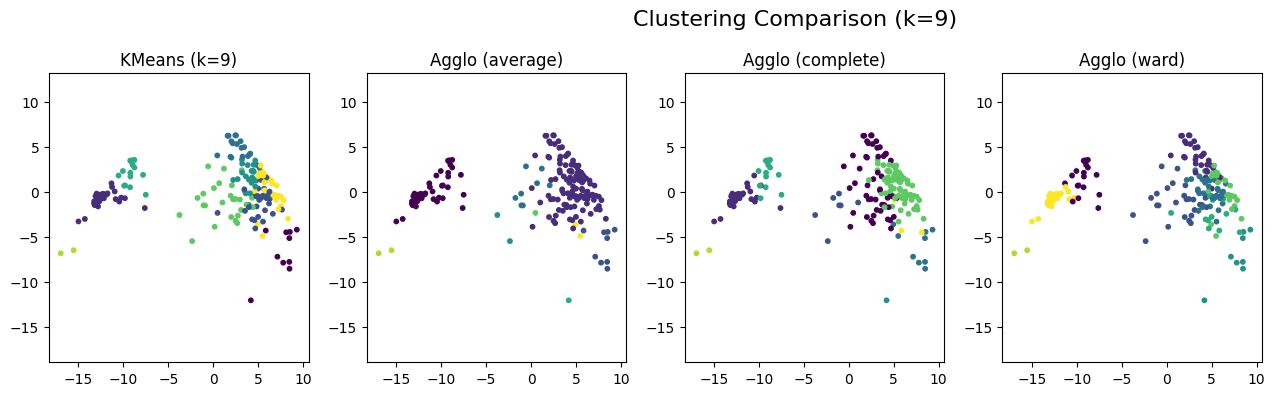

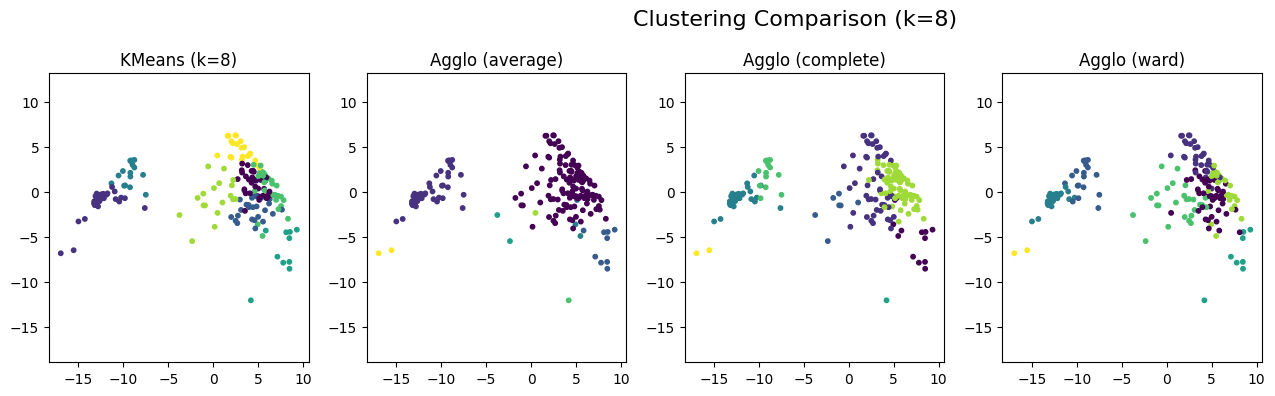

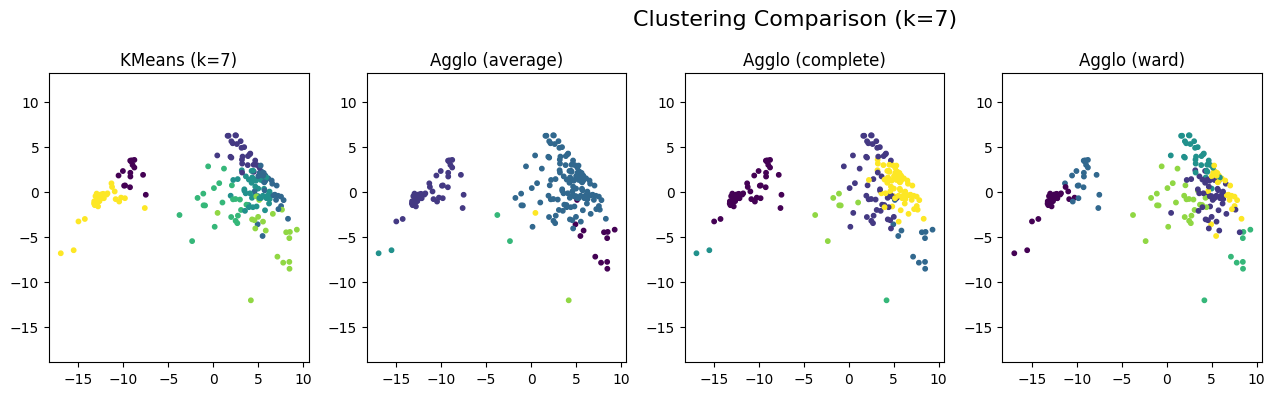

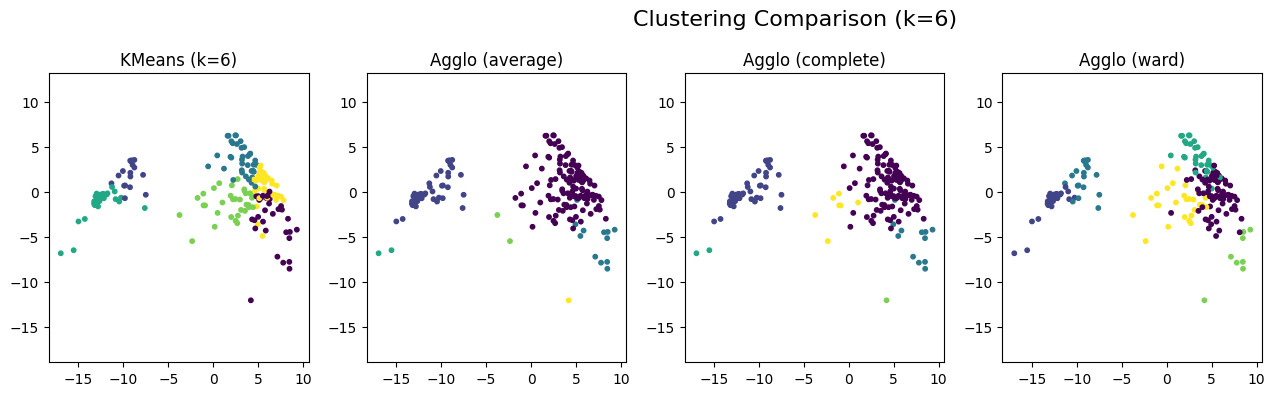

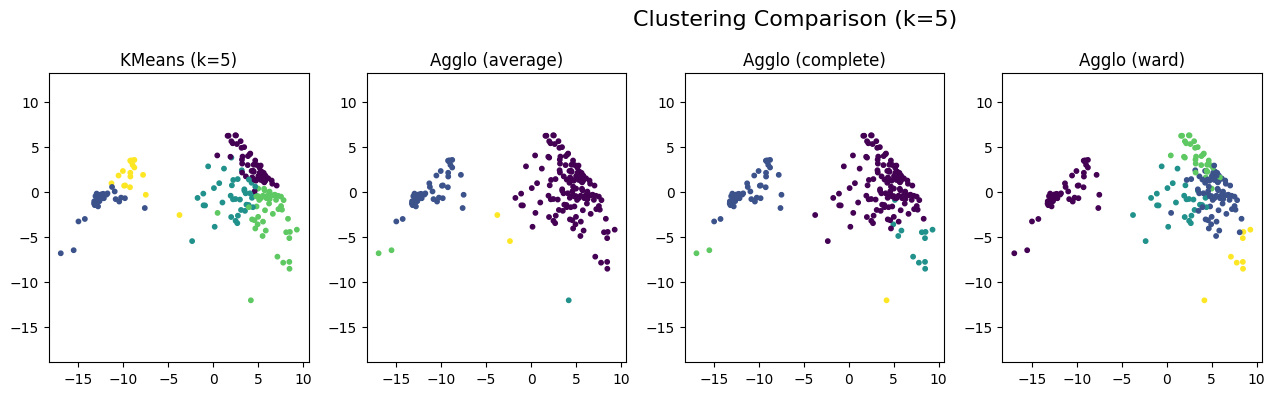

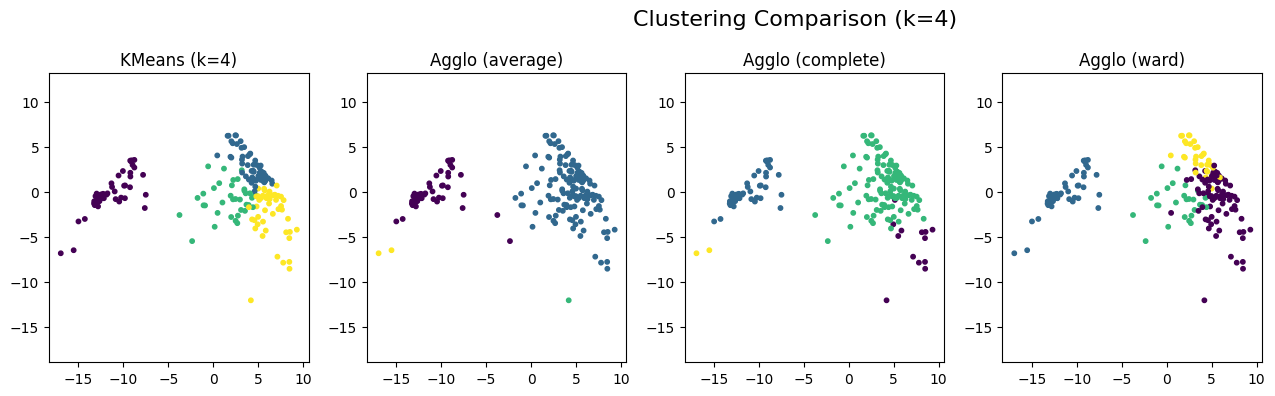

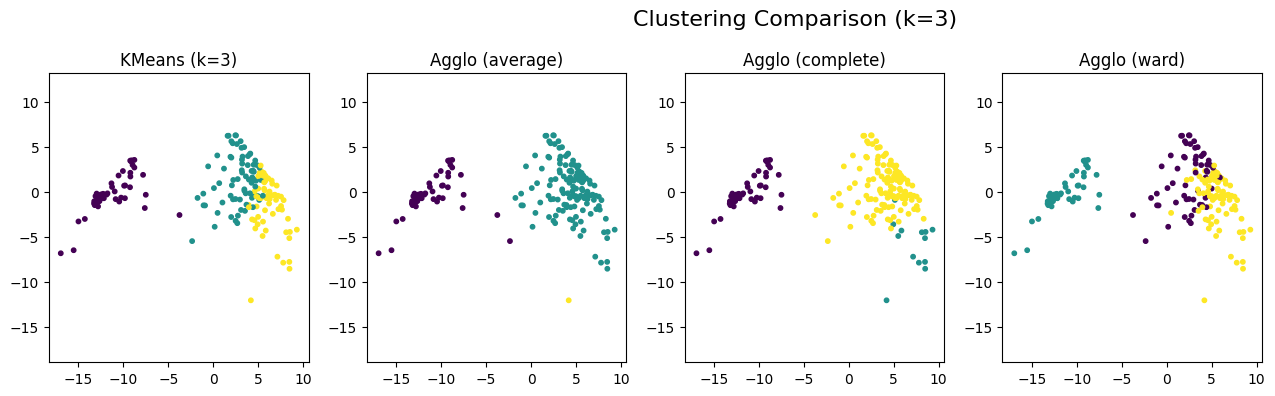

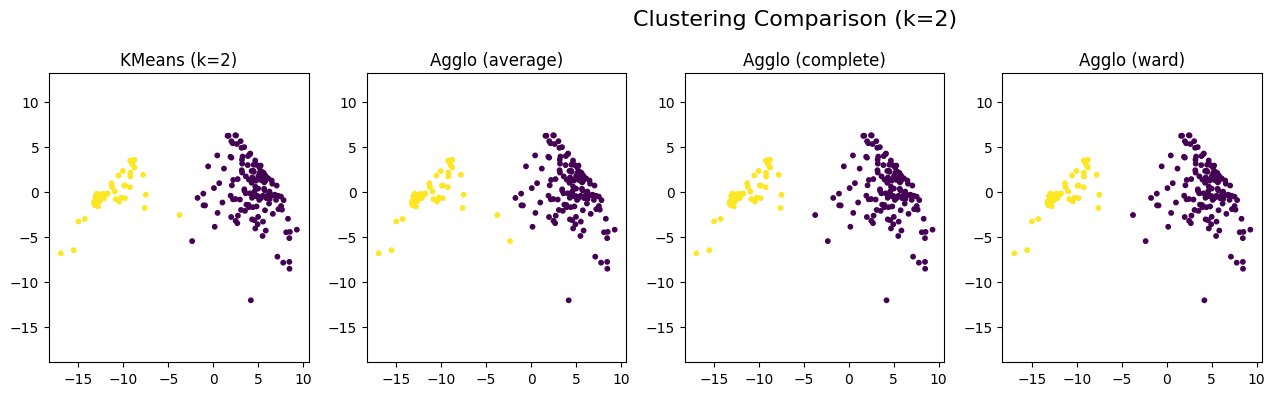

In [ ]:
# Loop over number of clusters (for methods that need k)
for k in reversed(np.arange(2, 11)):

    plt.figure(figsize=(16, 4))

    # ---- 1. KMeans ----
    plt.subplot(1, 5, 1)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    k_labels = kmeans.fit_predict(X_pca)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=k_labels, cmap='viridis', s=10)
    plt.title(f'KMeans (k={k})')
    plt.axis('equal')

    # ---- 2–4. Agglomerative ----
    for index, linkage in enumerate(('average', 'complete', 'ward')):

        plt.subplot(1, 5, index + 2)

        model = AgglomerativeClustering(linkage=linkage, n_clusters=k)
        labels = model.fit_predict(X_pca)

        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10)
        plt.title(f'Agglo ({linkage})')
        plt.axis('equal')

    # ---- Title ----
    plt.suptitle(f'Clustering Comparison (k={k})', size=16)

    plt.tight_layout()
    plt.show()


### Result:

Although k = 2 achieved the highest silhouette score, it resulted in an overly coarse and less informative partition of countries. This level of clustering essentially reduces global voting behavior into two broad groups, which limits geopolitical interpretability.

In contrast, k = 3 k-means provided a better balance between statistical performance and interpretability. This solution maintains strong cluster cohesion while producing more meaningful geopolitical structure.

Importantly, the three-cluster solution captures a more nuanced representation of global voting behavior, which can be interpreted as:

A Western-aligned bloc An opposing or alternative alignment bloc A non-aligned or mixed-position bloc

Overall, while k = 2 optimizes the clustering metric, k = 3 is preferred as it preserves structural validity while offering substantially improved interpretability for geopolitical analysis.

## Clustering Analysis

In [ ]:
# clustering
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

country_subject_votes['cluster'] = clusters


In [ ]:
country_subject_votes[["cluster"]].head(20)

subject_split,cluster
ms_name,
AFGHANISTAN,1
ALBANIA,0
ALGERIA,2
ANDORRA,0
ANGOLA,1
ANTIGUA AND BARBUDA,1
ARGENTINA,1
ARMENIA,1
AUSTRALIA,0


In [ ]:
# Get Countries in Each Cluster
cluster_countries = (
    country_subject_votes.reset_index()
    .groupby('cluster')['ms_name']
    .apply(list)
)
for cluster_id, countries in cluster_countries.items():
    print(f"\nCluster {cluster_id} ({len(countries)} countries):")
    print(countries)


Cluster 0 (54 countries):
['ALBANIA', 'ANDORRA', 'AUSTRALIA', 'AUSTRIA', 'BELGIUM', 'BOSNIA AND HERZEGOVINA', 'BULGARIA', 'CANADA', 'CROATIA', 'CYPRUS', 'CZECHIA', 'DENMARK', 'ESTONIA', 'FINLAND', 'FRANCE', 'GEORGIA', 'GERMANY', 'GREECE', 'HUNGARY', 'ICELAND', 'IRELAND', 'ISRAEL', 'ITALY', 'JAPAN', 'LATVIA', 'LIECHTENSTEIN', 'LITHUANIA', 'LUXEMBOURG', 'MALTA', 'MARSHALL ISLANDS', 'MICRONESIA (FEDERATED STATES OF)', 'MONACO', 'MONTENEGRO', 'NETHERLANDS', 'NEW ZEALAND', 'NORTH MACEDONIA', 'NORWAY', 'PALAU', 'POLAND', 'PORTUGAL', 'REPUBLIC OF KOREA', 'REPUBLIC OF MOLDOVA', 'ROMANIA', 'SAN MARINO', 'SERBIA', 'SLOVAKIA', 'SLOVENIA', 'SPAIN', 'SWEDEN', 'SWITZERLAND', 'TURKIYE', 'UKRAINE', 'UNITED KINGDOM', 'UNITED STATES']

Cluster 1 (73 countries):
['AFGHANISTAN', 'ANGOLA', 'ANTIGUA AND BARBUDA', 'ARGENTINA', 'ARMENIA', 'BAHAMAS', 'BARBADOS', 'BELIZE', 'BENIN', 'BHUTAN', 'BOLIVIA', 'BOTSWANA', 'BRAZIL', 'CABO VERDE', 'CENTRAL AFRICAN REPUBLIC', 'CHAD', 'CHILE', 'COLOMBIA', 'COMOROS', 'COST

In [ ]:
# Attach Cluster Back to Original Data
df_filtered = pd.merge(df_filtered, country_subject_votes[['cluster']], left_on = 'ms_name', right_index=True )

### Which issues create the most disagreement?

In [ ]:
# group by cluster
cluster_topics = country_subject_votes.groupby("cluster").mean()

# OPTIONAL: focus on most important topics (top 30)
top_topics = country_subject_votes.drop(columns='cluster').var().sort_values(ascending=False).head(30).index

cluster_topics_top = cluster_topics[top_topics]

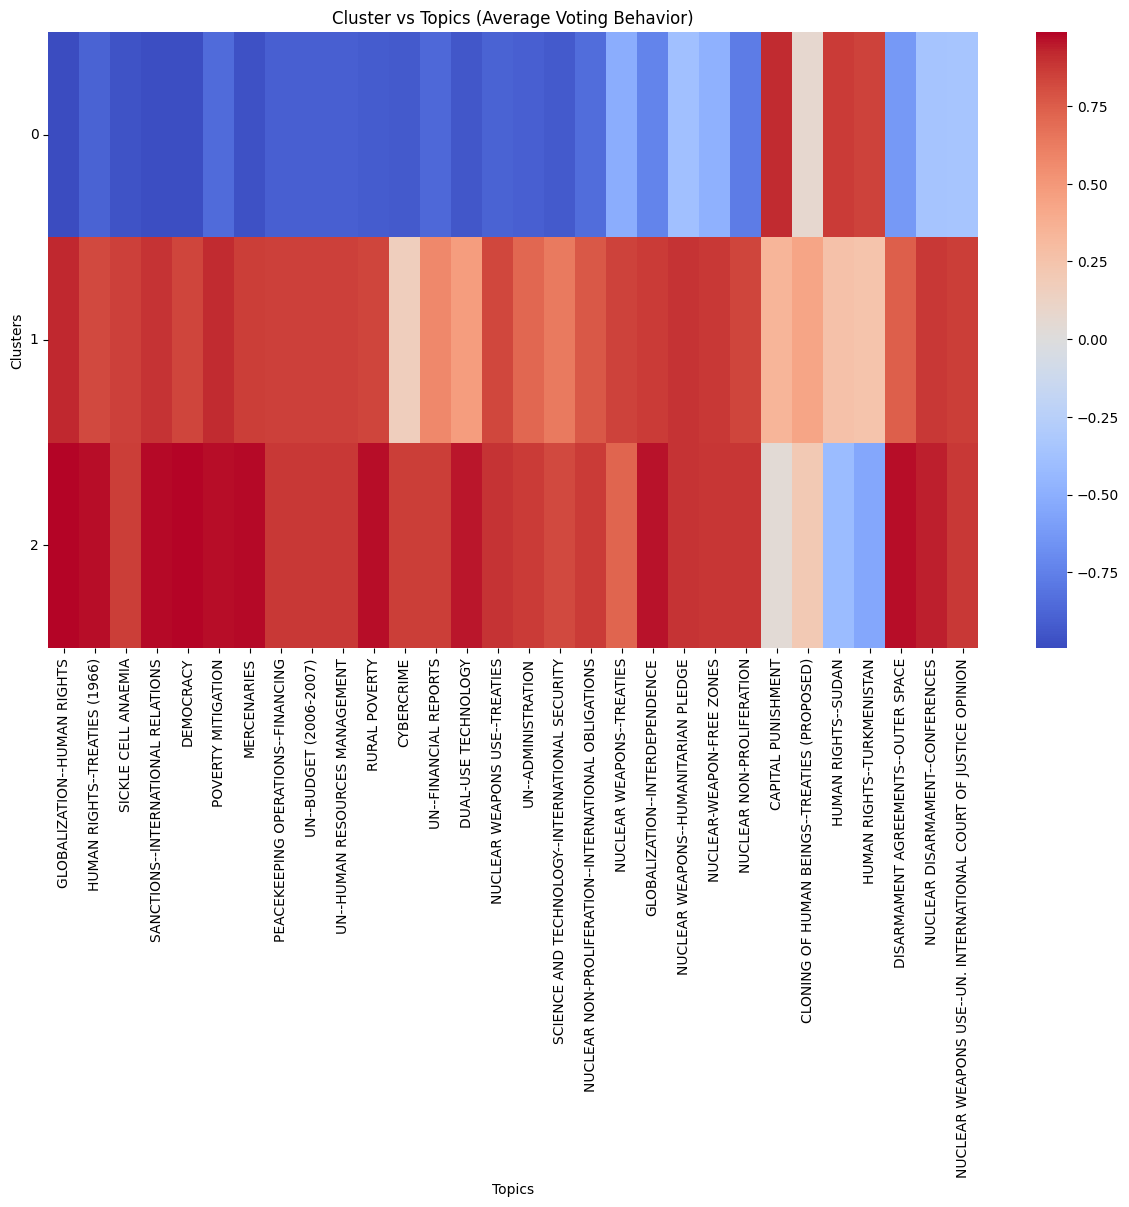

In [ ]:
# Heatmap of Clusters VS issues

plt.figure(figsize=(15, 8))

sns.heatmap(cluster_topics_top, cmap="coolwarm", center=0)

plt.title("Cluster vs Topics (Average Voting Behavior)")
plt.xlabel("Topics")
plt.ylabel("Clusters")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [ ]:
topic_variance = country_subject_votes.drop(columns='cluster').var().sort_values(ascending=False)

In [ ]:
top_topics = topic_variance.head(15)
print(top_topics)

subject_split
GLOBALIZATION--HUMAN RIGHTS           0.778224
HUMAN RIGHTS--TREATIES (1966)         0.771211
SICKLE CELL ANAEMIA                   0.769484
SANCTIONS--INTERNATIONAL RELATIONS    0.757959
DEMOCRACY                             0.757413
POVERTY MITIGATION                    0.747733
MERCENARIES                           0.744322
PEACEKEEPING OPERATIONS--FINANCING    0.744171
UN--BUDGET (2006-2007)                0.744171
UN--HUMAN RESOURCES MANAGEMENT        0.744171
RURAL POVERTY                         0.725552
CYBERCRIME                            0.714216
UN--FINANCIAL REPORTS                 0.708279
DUAL-USE TECHNOLOGY                   0.698160
NUCLEAR WEAPONS USE--TREATIES         0.674968
dtype: float64


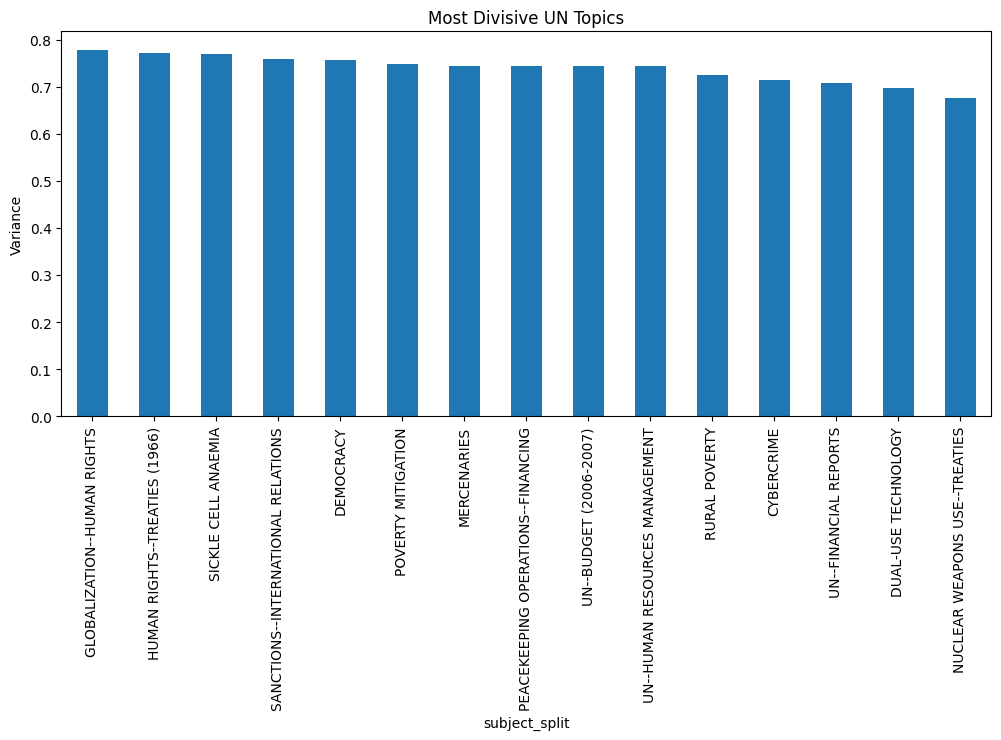

In [ ]:

top_topics.plot(kind='bar', figsize=(12,5))
plt.title("Most Divisive UN Topics")
plt.ylabel("Variance")
plt.show()

#### **Global polarization: Are resolutions becoming more consensual over time**

In [ ]:
# Aggregate by Cluster Year
cluster_year = (
    df_filtered.groupby(['cluster', 'year'])['vote_num']
    .mean()
    .reset_index()
)


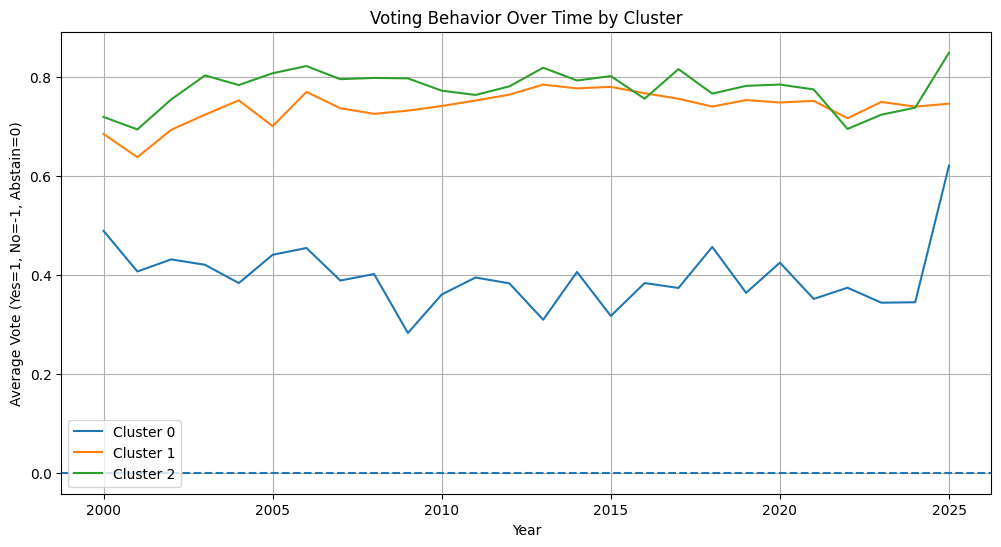

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for cluster_id in cluster_year['cluster'].unique():
    subset = cluster_year[cluster_year['cluster'] == cluster_id]

    plt.plot(
        subset['year'],
        subset['vote_num'],
        label=f'Cluster {cluster_id}'
    )

plt.axhline(0, linestyle='--')

plt.title("Voting Behavior Over Time by Cluster")
plt.xlabel("Year")
plt.ylabel("Average Vote (Yes=1, No=-1, Abstain=0)")
plt.legend()
plt.grid()

plt.show()


In [ ]:
#Smoothed Trends
cluster_year['rolling_vote'] = (
    cluster_year.groupby('cluster')['vote_num']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)


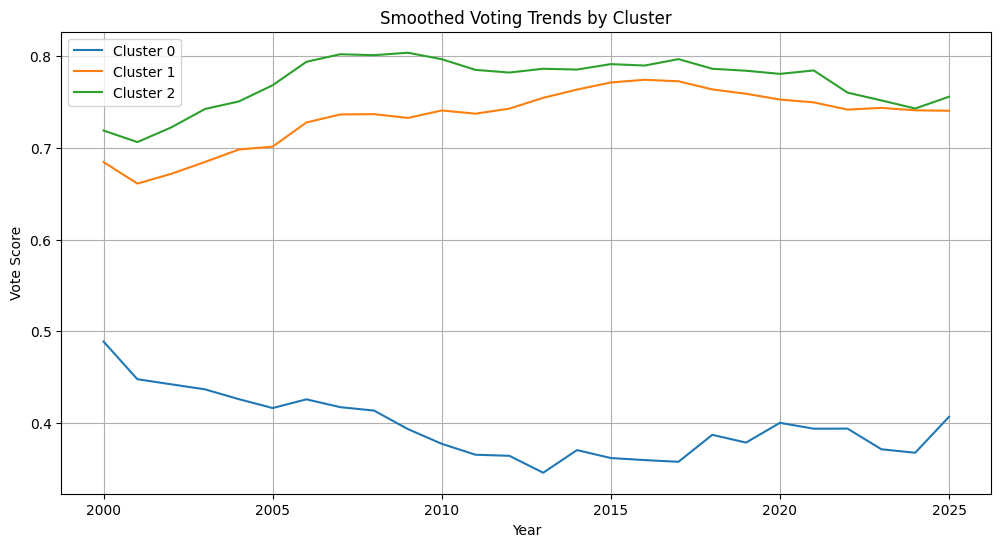

In [ ]:
plt.figure(figsize=(12, 6))

for cluster_id in cluster_year['cluster'].unique():
    subset = cluster_year[cluster_year['cluster'] == cluster_id]

    plt.plot(
        subset['year'],
        subset['rolling_vote'],
        label=f'Cluster {cluster_id}'
    )

plt.title("Smoothed Voting Trends by Cluster")
plt.xlabel("Year")
plt.ylabel("Vote Score")
plt.legend()
plt.grid()

plt.show()


#### **Which specific voting issues cause countries to deviate from their cluster?**

Since we've established that voting behavior reflects geopolitical alignment, we can start looknig at behaviors within clusters.

Issues causing most disagreement in Cluster 0 (top 10):
subject_split
CLONING OF HUMAN BEINGS--TREATIES (PROPOSED)                       0.862334
NUCLEAR WEAPONS--HUMANITARIAN PLEDGE                               0.694969
NUCLEAR-WEAPON-FREE ZONES                                          0.591572
NUCLEAR WEAPONS--TREATIES                                          0.588247
NUCLEAR DISARMAMENT--DECLARATIONS                                  0.549926
NUCLEAR DISARMAMENT--CONFERENCES                                   0.535018
NUCLEAR WEAPONS--HUMANITARIAN CONSEQUENCES                         0.486558
NUCLEAR WEAPONS USE--UN. INTERNATIONAL COURT OF JUSTICE OPINION    0.456885
NUCLEAR-WEAPON-FREE ZONE--SOUTHERN HEMISPHERE                      0.359976
TERRITORIES OCCUPIED BY ISRAEL--NATURAL RESOURCES                  0.341522
Name: 0, dtype: float64

Issues causing most disagreement in Cluster 1 (top 10):
subject_split
CAPITAL PUNISHMENT                                                         

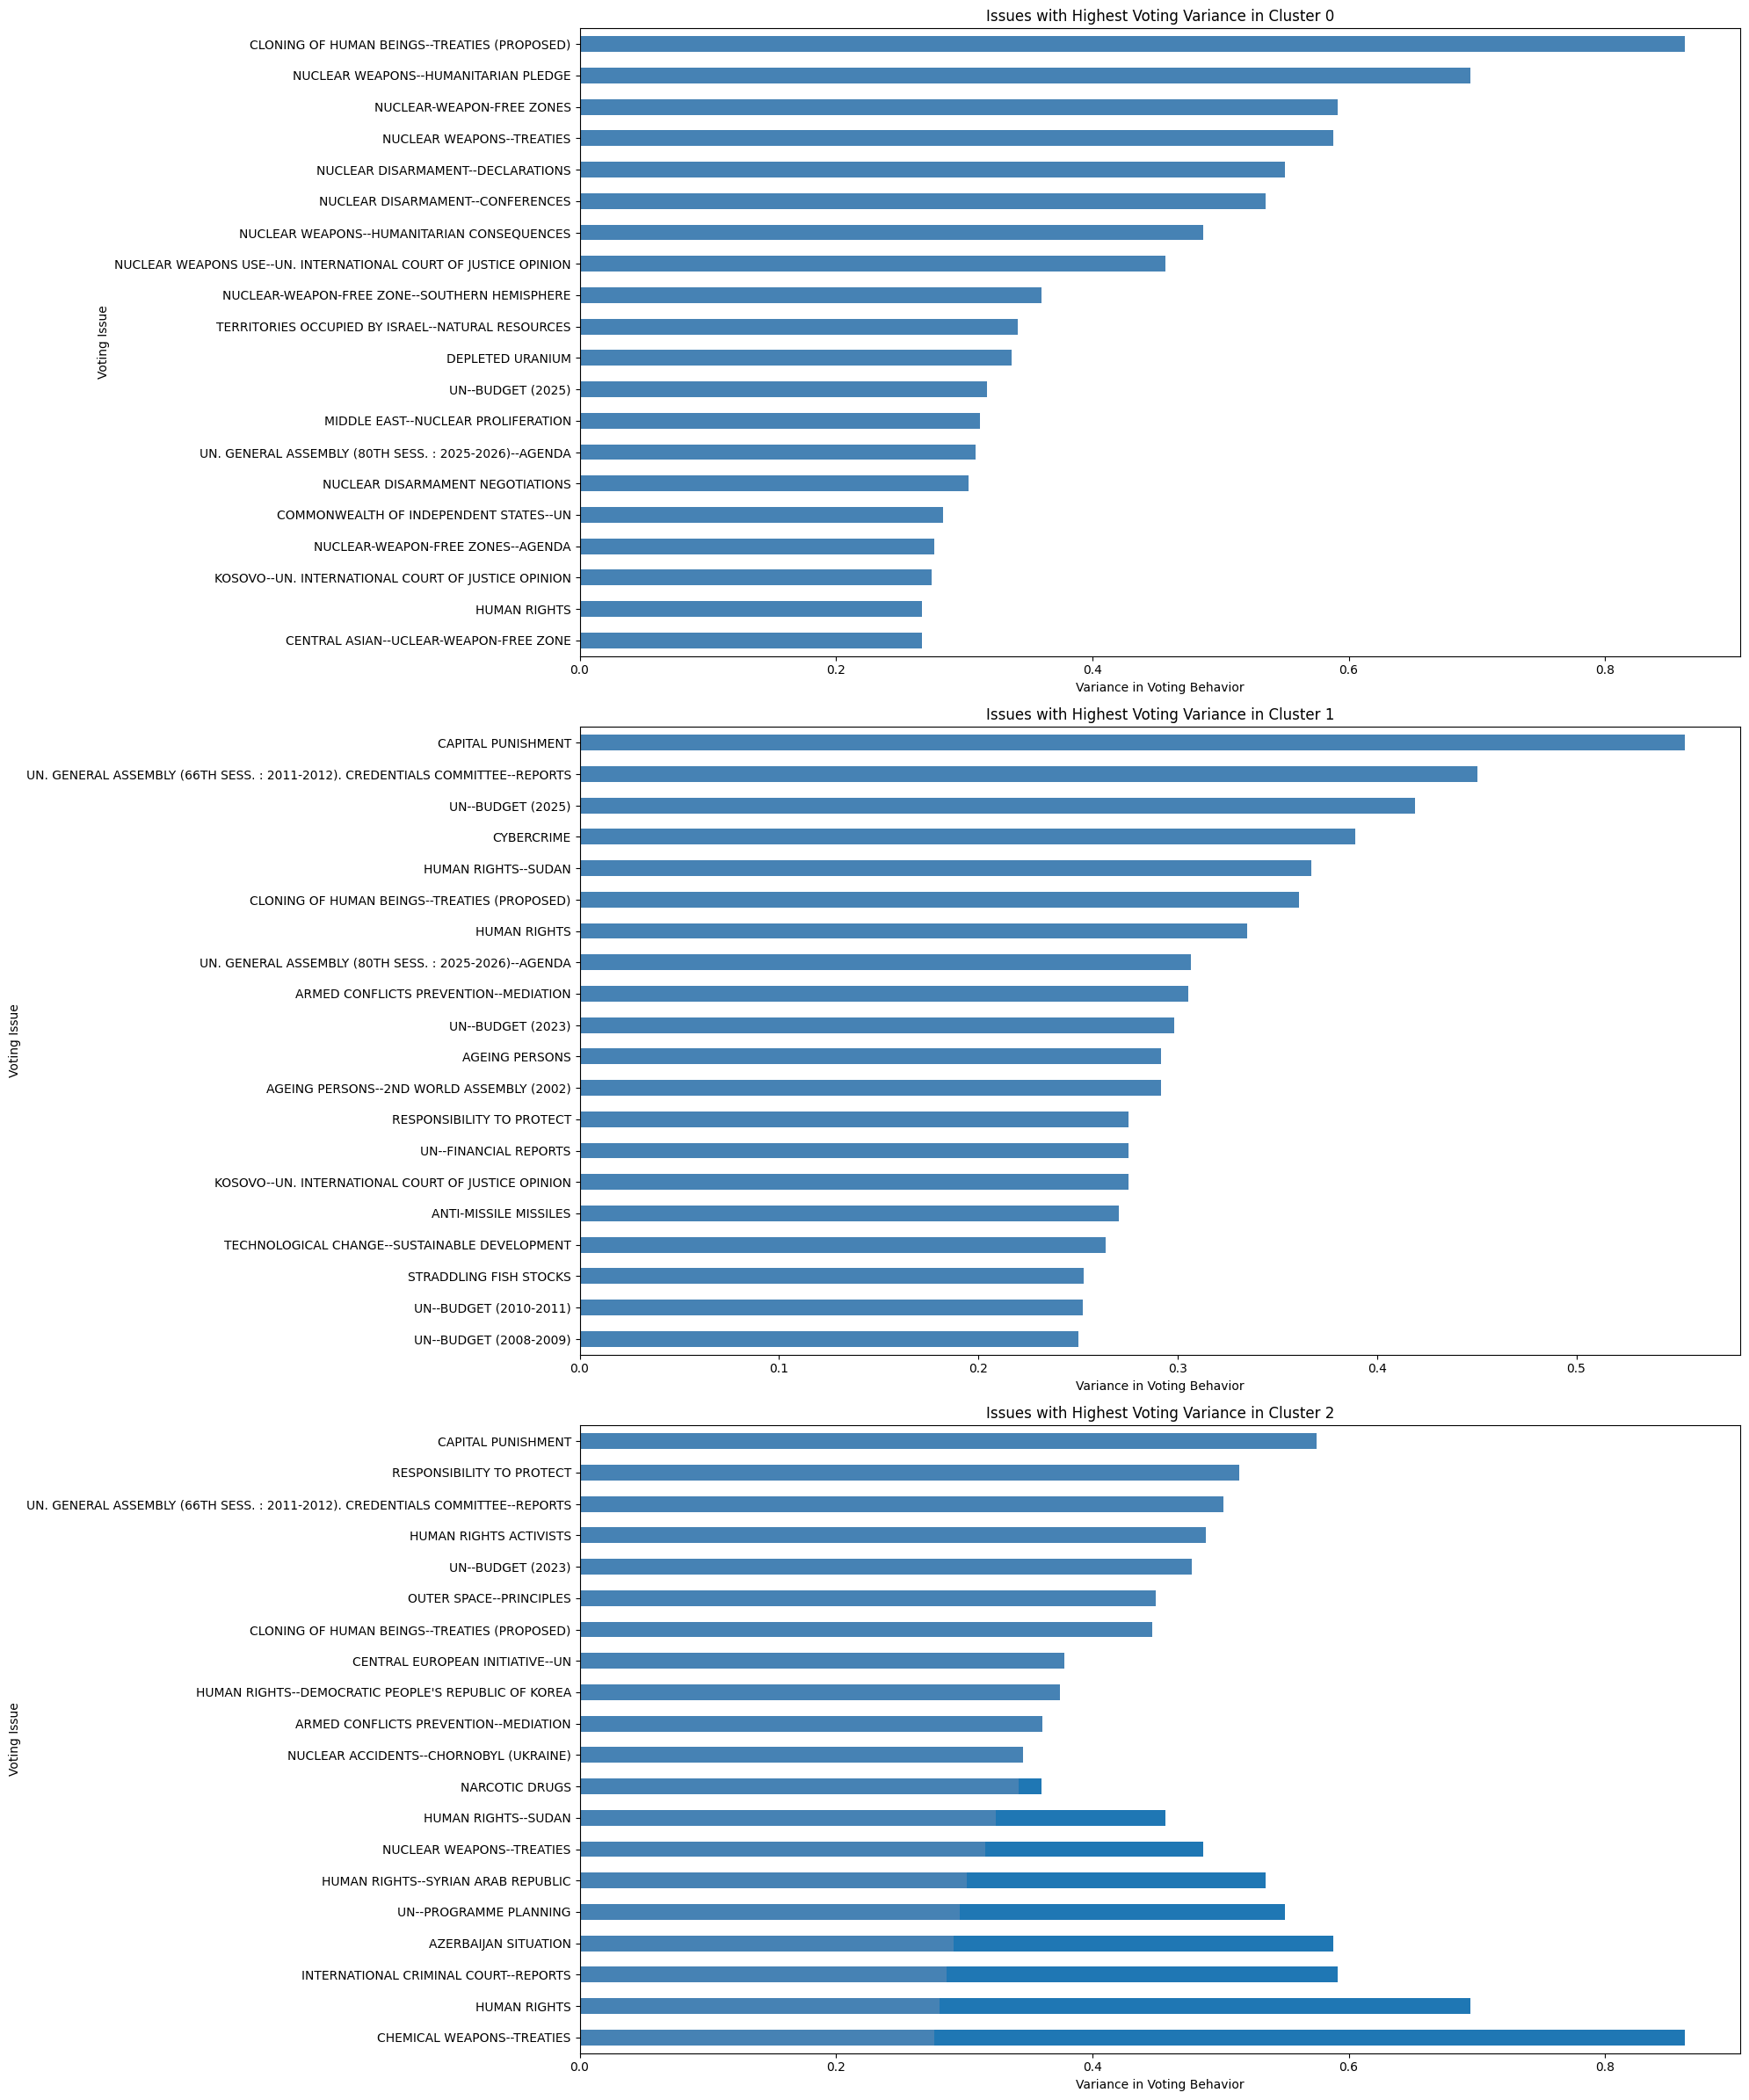

In [ ]:
clusters_dict = {}
for cluster_id in range(3):
    cluster_countries = country_subject_votes[clusters == cluster_id]
    clusters_dict[cluster_id] = cluster_countries

# For each cluster, calculate variance (or std dev) per issue
issue_variance = {}
for cluster_id, cluster_data in clusters_dict.items():
    # Variance of votes on each issue within this cluster
    variance_per_issue = cluster_data.var(axis=0)  # axis=0 = across countries
    issue_variance[cluster_id] = variance_per_issue

# Convert to DataFrame for easy viewing
variance_df = pd.DataFrame(issue_variance)
variance_df.index = country_subject_votes.columns  # Issue names

# Show which issues divide each cluster the most
print("Issues causing most disagreement in Cluster 0 (top 10):")
print(variance_df[0].nlargest(10))

print("\nIssues causing most disagreement in Cluster 1 (top 10):")
print(variance_df[1].nlargest(10))

print("\nIssues causing most disagreement in Cluster 2 (top 10):")
print(variance_df[2].nlargest(10))

# Visualize
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1)
variance_df.nlargest(20, 0)[0].plot(kind='barh', figsize=(20, 24))
for cluster_id in range(3):
    # Get top 20 issues for the cluster
    top_issues = variance_df[cluster_id].nlargest(20)

    # Plot the cluster's variance
    top_issues.sort_values().plot(kind='barh', ax=axes[cluster_id], color='steelblue')
    axes[cluster_id].set_title(f'Issues with Highest Voting Variance in Cluster {cluster_id}', fontsize=12)
    axes[cluster_id].set_xlabel('Variance in Voting Behavior')
    axes[cluster_id].set_ylabel('Voting Issue')

plt.tight_layout()
plt.show()

To understand what causes countries to deviate from their cluster's voting pattern, we analyzed within-cluster voting variance by issue to determine which issues are the most deivisive within the clusters, and by how much.

In [ ]:
# Calculate cluster centroids (average voting position per cluster)
centroids = {}
for cluster_id in range(3):
    cluster_data = country_subject_votes[clusters == cluster_id]
    centroids[cluster_id] = cluster_data.mean(axis=0)  # Mean vote per issue

centroids_df = pd.DataFrame(centroids)
centroids_df.index = country_subject_votes.columns  # Issue names

# For each country, calculate its deviation from its cluster centroid
deviations = []

for idx, country in enumerate(country_subject_votes.index):
    cluster_id = clusters[idx]
    country_votes = country_subject_votes.iloc[idx]
    cluster_centroid = centroids[cluster_id]

    # Euclidean distance from centroid
    deviation = np.sqrt(((country_votes - cluster_centroid) ** 2).sum())

    deviations.append({
        'ms_name': country,
        'cluster': cluster_id,
        'deviation_from_centroid': deviation
    })

deviation_df = pd.DataFrame(deviations).sort_values('deviation_from_centroid', ascending=False)

# Countries most likely to leave their cluster (highest deviation)
print("Countries most likely to realign (highest deviation from cluster consensus):")
print(deviation_df.head(15))

# Now, for the top 5 "loose" countries, see which issues drive their deviation
loose_countries = deviation_df.head(5)['ms_name'].values

for country in loose_countries:
    country_idx = country_subject_votes.index.get_loc(country)
    cluster_id = clusters[country_idx]
    country_votes = country_subject_votes.iloc[country_idx]
    cluster_centroid = centroids[cluster_id]

    # Per-issue deviation
    per_issue_deviation = (country_votes - cluster_centroid).abs()
    top_deviating_issues = per_issue_deviation.nlargest(10)

    print(f"\n{country} (Cluster {cluster_id}) deviates most on:")
    print(top_deviating_issues)


Countries most likely to realign (highest deviation from cluster consensus):
                                   ms_name  cluster  deviation_from_centroid
184                          UNITED STATES        0                19.537314
81                                  ISRAEL        0                15.022295
142                     RUSSIAN FEDERATION        2                10.611816
161                            SOUTH SUDAN        1                10.367979
118                                  NAURU        1                10.189139
6                                ARGENTINA        1                10.058962
129                                  PALAU        0                 9.393331
44   DEMOCRATIC PEOPLE'S REPUBLIC OF KOREA        2                 9.308039
88                                KIRIBATI        1                 9.144229
188                              VENEZUELA        2                 8.996455
149                  SAO TOME AND PRINCIPE        1                 8.935694

### Temporal Analysis of Clusters

#### Data recleaning to include data starting from 1980

In [ ]:
# Filter Years(1980+)
# Stabilization of modern global structure
df_filtered2 = df.copy()
df_filtered2['date'] = pd.to_datetime(df_filtered2['date'])
df_filtered2['year'] = df_filtered2['date'].dt.year
df_filtered2 = df_filtered2[df_filtered2['year'] >= 1980]
print("After year filter:", len(df_filtered2))
df_filtered2

After year filter: 785179


,undl_id,ms_code,ms_name,ms_vote,date,session,resolution,draft,committee_report,meeting,...,agenda_title,subjects,vote_note,total_yes,total_no,total_abstentions,total_non_voting,total_ms,undl_link,year
0,507407,AFG,AFGHANISTAN,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
1,507407,ALB,ALBANIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
2,507407,DZA,ALGERIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
3,507407,AND,ANDORRA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
4,507407,AGO,ANGOLA,X,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947429,4088513,VEN,VENEZUELA (BOLIVARIAN REPUBLIC OF),X,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025
947430,4088513,VNM,VIET NAM,Y,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025
947431,4088513,YEM,YEMEN,Y,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025
947432,4088513,ZMB,ZAMBIA,X,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513,2025


In [ ]:
df_filtered2['decade'] = (df_filtered2['date'].dt.year // 10) * 10

In [ ]:
df_filtered2['ms_name'] = df_filtered2['ms_name'].replace(country_map)
print("After country mapping:", df_filtered2['ms_name'].nunique())

After country mapping: 209


In [ ]:
df_filtered2 = df_filtered2[~df_filtered2['ms_name'].isin(invalid)]

print("After removing invalid:", df_filtered2['ms_name'].nunique())

After removing invalid: 199


In [ ]:
df_filtered2["subject_split"] = df_filtered2["subjects"].str.split("|")

# explode into multiple rows
df_filtered2 = df_filtered2.explode("subject_split")

print("After explode:", len(df_filtered2))

After explode: 837468


In [ ]:
# Fix Voting Code

df_filtered2['ms_vote'] = df_filtered2['ms_vote'].astype(str).str.strip()

df_filtered2['ms_vote'].value_counts()

df_filtered2 = df_filtered2.drop_duplicates()

# map votes to integer valueskeep valid votes should we remove X?
map_votes = { 'Y' : 1, 'N': -1, 'A': 0, 'X': 0}
df_filtered2 = df_filtered2[df_filtered2['ms_vote'].isin(map_votes.keys())]
df_filtered2['vote_num'] = df_filtered2['ms_vote'].map(map_votes)

print("Missing vote_num:", df_filtered2['vote_num'].isna().sum())

Missing vote_num: 0


In [ ]:
drop_cols = ['undl_id', 'undl_link', 'draft', 'meeting', 'committee_report', 'vote_note']
df_filtered2 = df_filtered2.drop(drop_cols, axis=1)
df_filtered2

,ms_code,ms_name,ms_vote,date,session,resolution,title,agenda_title,subjects,total_yes,total_no,total_abstentions,total_non_voting,total_ms,year,decade,subject_split,vote_num
0,AFG,AFGHANISTAN,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,2000,PALESTINE QUESTION,1
1,ALB,ALBANIA,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,2000,PALESTINE QUESTION,1
2,DZA,ALGERIA,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,2000,PALESTINE QUESTION,1
3,AND,ANDORRA,Y,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,2000,PALESTINE QUESTION,1
4,AGO,ANGOLA,X,2003-12-03,58,A/RES/58/20,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,159.0,6.0,6.0,20.0,191.0,2003,2000,PALESTINE QUESTION,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947429,VEN,VENEZUELA,X,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,2020,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,0
947430,VNM,VIET NAM,Y,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,2020,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,1
947431,YEM,YEMEN,Y,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,2020,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,1
947432,ZMB,ZAMBIA,X,2025-09-19,80,A/RES/80/1,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,145.0,5.0,6.0,37.0,193.0,2025,2020,UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,0


In [ ]:
df_filtered2 = df_filtered2.dropna(subset=['vote_num', 'subject_split'])

In [ ]:
print(df_filtered2['decade'].unique())
print(df_filtered2.groupby('decade')['ms_name'].nunique())

[2000 1980 1990 2010 2020]
decade
1980    155
1990    186
2000    191
2010    193
2020    193
Name: ms_name, dtype: int64


In [ ]:
df2 = df_filtered2

In [ ]:
country_subject_votes2 = df2.pivot_table(
    index="ms_name",
    columns="subject_split",
    values="vote_num",
    aggfunc="mean"
).fillna(0)

print("Final shape:", country_subject_votes2.shape)

country_subject_votes2.head()

Final shape: (197, 436)


subject_split,2030 AGENDA--PROGRAMME IMPLEMENTATION,AFGHANISTAN SITUATION,AFRICA--DEVELOPMENT,AFRICA--NUCLEAR-WEAPON-FREE ZONES,AFRICA--STRUCTURAL ADJUSTMENT,AFRICA--SUSTAINABLE DEVELOPMENT--PARTNERSHIP,AFRICAN UNION--UN,AGEING PERSONS,AGEING PERSONS--2ND WORLD ASSEMBLY (2002),AGENDA 21--PROGRAMME IMPLEMENTATION,...,WEAPONS OF MASS DESTRUCTION,WEAPONS--OUTER SPACE,WESTERN SAHARA QUESTION,WOMEN MIGRANT WORKERS,WOMEN'S ADVANCEMENT,WOMEN'S ADVANCEMENT--CONFERENCES,WOMEN--DISARMAMENT,WOMEN--DISCRIMINATION,WOMEN--INTERNATIONAL DECADES,YOUTH
ms_name,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0.5,-0.1,1.000000,0.928571,1.0,1.000000,0.0,0.0,0.0,0.714286,...,1.000000,0.833333,0.0,0.0,0.384615,0.0,1.0,1.0,1.0,0.5
ALBANIA,1.0,1.0,0.000000,0.928571,1.0,0.000000,1.0,0.0,0.0,0.000000,...,0.615385,-0.583333,0.0,1.0,0.461538,1.0,1.0,0.0,1.0,1.0
ALGERIA,1.0,0.5,1.000000,1.000000,1.0,1.000000,1.0,0.0,0.0,0.857143,...,1.000000,1.000000,1.0,1.0,0.769231,1.0,1.0,1.0,1.0,1.0
ANDORRA,1.0,1.0,0.333333,0.000000,0.0,0.333333,1.0,0.0,0.0,0.000000,...,1.000000,-0.333333,0.0,1.0,1.000000,1.0,1.0,0.0,0.0,1.0
ANGOLA,0.5,-0.1,1.000000,0.857143,1.0,1.000000,1.0,0.0,0.0,1.000000,...,0.923077,0.916667,1.0,1.0,0.692308,1.0,1.0,1.0,1.0,1.0


In [ ]:
top_topics2 = country_subject_votes2.var().sort_values(ascending=False).head(100).index
X2 = country_subject_votes2[top_topics2]

# scale data
scaler = StandardScaler()
X_scaled2 = scaler.fit_transform(X2)

pca2 = PCA(n_components=0.95)
X_pca2 = pca2.fit_transform(X_scaled2)

print(f"Original number of features: {X_scaled2.shape[1]}")
print(f"Reduced number of features after PCA: {X_pca2.shape[1]}")
print("Explained variance ratio sum:", sum(pca2.explained_variance_ratio_))

Original number of features: 100
Reduced number of features after PCA: 37
Explained variance ratio sum: 0.9508236878576332


In [ ]:
k = 3
Agglo_ward = AgglomerativeClustering(linkage='ward', n_clusters=k)
clusters2 = Agglo_ward.fit_predict(X_pca2)

country_subject_votes2['cluster'] = clusters2


In [ ]:
df2 = pd.merge(df2, country_subject_votes2[['cluster']], left_on = 'ms_name', right_index=True )

In [ ]:
df_agg = df2.groupby(['ms_name', 'decade'])['cluster'].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
).reset_index()

print("Aggregated data shape:", df_agg.shape)
print("\nAggregated data sample:")
print(df_agg.head(15))

# Verify the aggregation worked
print("\nMax entries per country per decade:", df_agg.groupby(['ms_name', 'decade']).size().max())
print("Total countries:", df_agg['ms_name'].nunique())
print("Total decades:", df_agg['decade'].nunique())

Aggregated data shape: (918, 3)

Aggregated data sample:
        ms_name  decade  cluster
0   AFGHANISTAN    1980        1
1   AFGHANISTAN    1990        1
2   AFGHANISTAN    2000        1
3   AFGHANISTAN    2010        1
4   AFGHANISTAN    2020        1
5       ALBANIA    1980        0
6       ALBANIA    1990        0
7       ALBANIA    2000        0
8       ALBANIA    2010        0
9       ALBANIA    2020        0
10      ALGERIA    1980        1
11      ALGERIA    1990        1
12      ALGERIA    2000        1
13      ALGERIA    2010        1
14      ALGERIA    2020        1

Max entries per country per decade: 1
Total countries: 197
Total decades: 5


#### Transition Matrix

In [ ]:
def create_transition_matrix(df2, decade1, decade2):
    current = df2[df2['decade'] == decade1][['ms_name', 'cluster']].copy()
    next_decade = df2[df2['decade'] == decade2][['ms_name', 'cluster']].copy()

    print(f"Current decade ({decade1}): {len(current)} countries")
    print(f"Next decade ({decade2}): {len(next_decade)} countries")

    transitions = current.merge(
        next_decade,
        on='ms_name',
        how='inner',
        suffixes=('_current', '_next')
    )

    print(f"Countries in both decades: {len(transitions)}\n")

    contingency = pd.crosstab(
        transitions['cluster_current'],
        transitions['cluster_next']
    )
    transition_normalized = contingency.div(contingency.sum(axis=1), axis=0)

    return contingency, transition_normalized, len(transitions)

# Build transition matrices
transitions_list = []
decades = sorted(df_agg['decade'].unique())

print("="*70)
print("CLUSTER TRANSITIONS BY DECADE")
print("="*70)

for i in range(len(decades) - 1):
    decade1 = decades[i]
    decade2 = decades[i+1]

    raw, normalized, n = create_transition_matrix(df_agg, decade1, decade2)

    print(f"NORMALIZED (% moving between clusters):")
    print(normalized.round(3))
    print("\n")

    transitions_list.append({
        'decade1': decade1,
        'decade2': decade2,
        'raw': raw,
        'normalized': normalized,
        'n_countries': n
    })


CLUSTER TRANSITIONS BY DECADE
Current decade (1980): 155 countries
Next decade (1990): 186 countries
Countries in both decades: 151

NORMALIZED (% moving between clusters):
cluster_next       0    1    2
cluster_current               
0                1.0  0.0  0.0
1                0.0  1.0  0.0
2                0.0  0.0  1.0


Current decade (1990): 186 countries
Next decade (2000): 191 countries
Countries in both decades: 186

NORMALIZED (% moving between clusters):
cluster_next       0    1    2
cluster_current               
0                1.0  0.0  0.0
1                0.0  1.0  0.0
2                0.0  0.0  1.0


Current decade (2000): 191 countries
Next decade (2010): 193 countries
Countries in both decades: 191

NORMALIZED (% moving between clusters):
cluster_next       0    1    2
cluster_current               
0                1.0  0.0  0.0
1                0.0  1.0  0.0
2                0.0  0.0  1.0


Current decade (2010): 193 countries
Next decade (2020): 193 countries

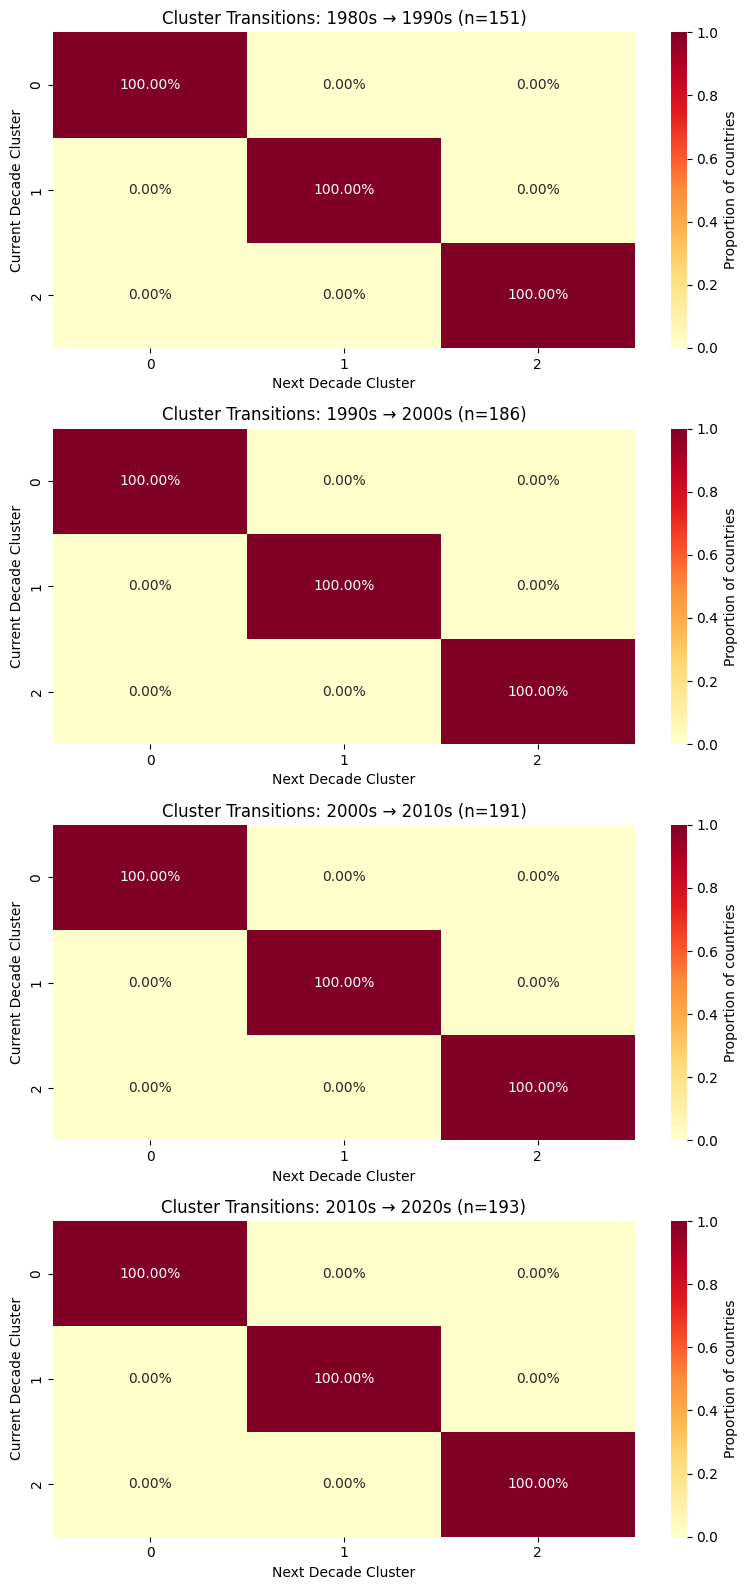

In [ ]:
fig, axes = plt.subplots(
    nrows=len(transitions_list),
    figsize=(8, 4 * len(transitions_list))
)

if len(transitions_list) == 1:
    axes = [axes]

for idx, trans in enumerate(transitions_list):
    decade1 = trans['decade1']
    decade2 = trans['decade2']
    normalized = trans['normalized']

    ax = axes[idx]
    sns.heatmap(
        normalized,
        annot=True,
        fmt='.2%',  # Format as percentage
        cmap='YlOrRd',
        ax=ax,
        cbar_kws={'label': 'Proportion of countries'},
        vmin=0,
        vmax=1
    )
    ax.set_title(f'Cluster Transitions: {decade1}s → {decade2}s (n={trans["n_countries"]})')
    ax.set_xlabel('Next Decade Cluster')
    ax.set_ylabel('Current Decade Cluster')

plt.tight_layout()
plt.show()

### Voting Behavior Over Time

Longitudinal analyses of voting behaviors of  US-allies: United States, United Kingdom, France, Germany, Canada, Italy and Japan

Are these countries consistent in their votes over time?

In [ ]:
#Aggregate Voting Behavior by Country-Year
country_year = (
    df_filtered.groupby(['ms_name', 'year'])['vote_num']
    .mean()
    .reset_index()
)


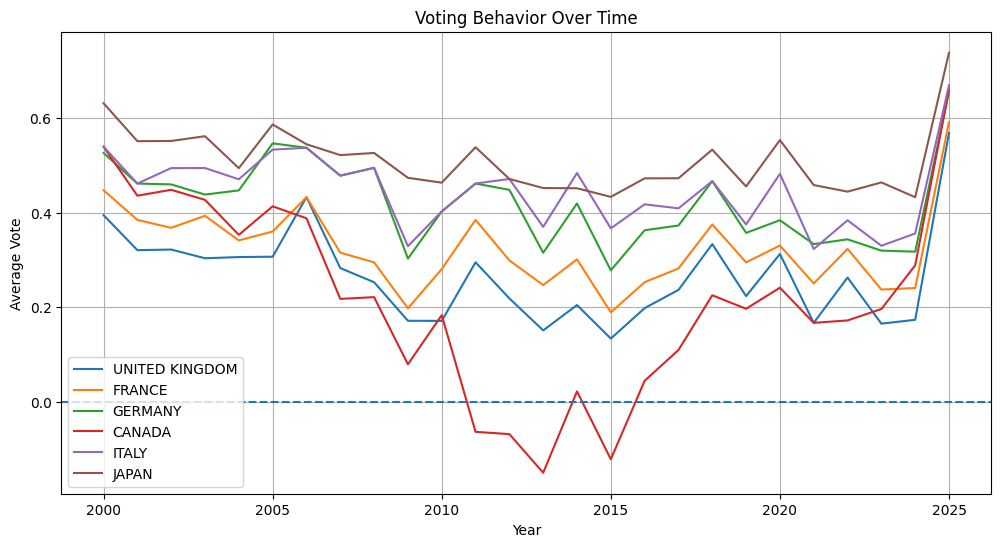

In [ ]:
countries = ["UNITED KINGDOM",
    "FRANCE",
    "GERMANY",
    "CANADA",
    "ITALY",
    "JAPAN"]

plt.figure(figsize=(12, 6))

for country in countries:
    subset = country_year[country_year['ms_name'] == country]
    plt.plot(subset['year'], subset['vote_num'], label=country)

plt.axhline(0, linestyle='--')
plt.title("Voting Behavior Over Time")
plt.xlabel("Year")
plt.ylabel("Average Vote")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Rolling Trend (Smooth Changes)
country_year['rolling_vote'] = (
    country_year.groupby('ms_name')['vote_num']
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)


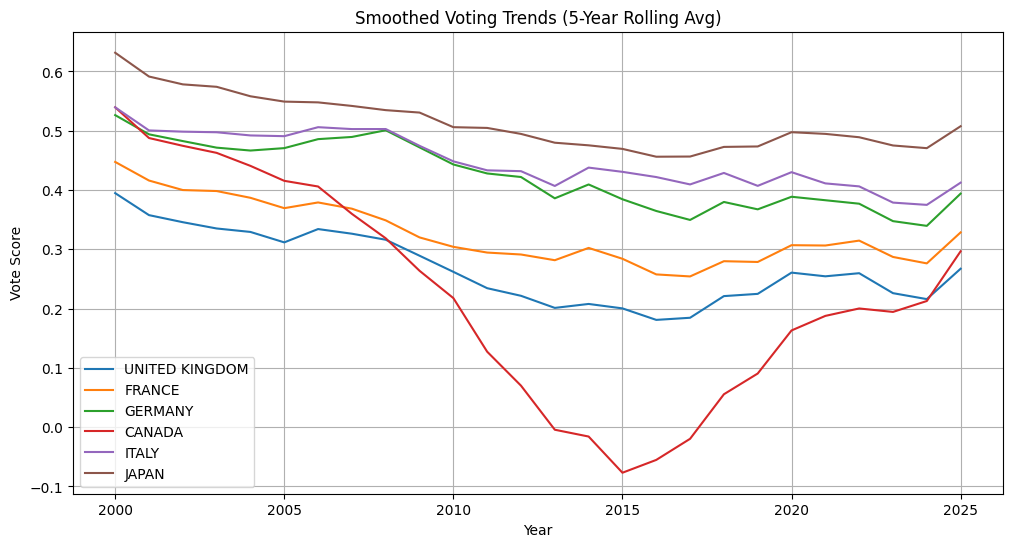

In [ ]:
plt.figure(figsize=(12, 6))

for country in countries:
    subset = country_year[country_year['ms_name'] == country]
    plt.plot(subset['year'], subset['rolling_vote'], label=country)

plt.title("Smoothed Voting Trends (5-Year Rolling Avg)")
plt.xlabel("Year")
plt.ylabel("Vote Score")
plt.legend()
plt.grid()
plt.show()


# US + War Analysis

## US vs Traditional Allies Over Time

In this section, we analyze how closely the United States aligns with its traditional allies over time in UN voting behavior.

We first aggregate voting data by year and country across different issue areas, then compute the cosine similarity between the US voting pattern and the average voting pattern of its traditional allies.

This allows us to track changes in political alignment over time and identify periods of divergence.

In [ ]:
# Define list of traditional US allies
traditional_allies = [
    "UNITED KINGDOM",
    "FRANCE",
    "GERMANY",
    "CANADA",
    "ITALY",
    "JAPAN"
]

# Extract year from date for time-based analysis
df_filtered['year'] = df_filtered['date'].dt.year

# Create a pivot table:
# Rows   → (year, country)
# Columns→ subject/topic of vote
# Values → average voting score (vote_num)
year_country_votes = df_filtered.pivot_table(
    index=["year", "ms_name"],
    columns="subject_split",
    values="vote_num",
    aggfunc="mean"
).fillna(0)

# Import cosine distance to measure similarity
from scipy.spatial.distance import cosine
import pandas as pd

# Get sorted list of years
years = sorted(df_filtered['year'].unique())

# Store similarity between US and allies over time
us_allies_similarity = []

# Compute yearly similarity:
# Compare US voting vector with average of allies
for y in years:
    try:
      # Extract data for a specific year
        data_year = year_country_votes.loc[y]

        # US voting vector
        us = data_year.loc["UNITED STATES"]

        # Average voting vector of traditional allies
        allies = data_year.loc[traditional_allies].mean()

        # Cosine similarity (1 - cosine distance)
        sim = 1 - cosine(us, allies)
        us_allies_similarity.append(sim)

    except:
        # Handle missing data (e.g., country not present in a year)
        us_allies_similarity.append(None)

# Create DataFrame for visualization
us_allies_df = pd.DataFrame({
    "year": years,
    "similarity": us_allies_similarity
}).dropna()

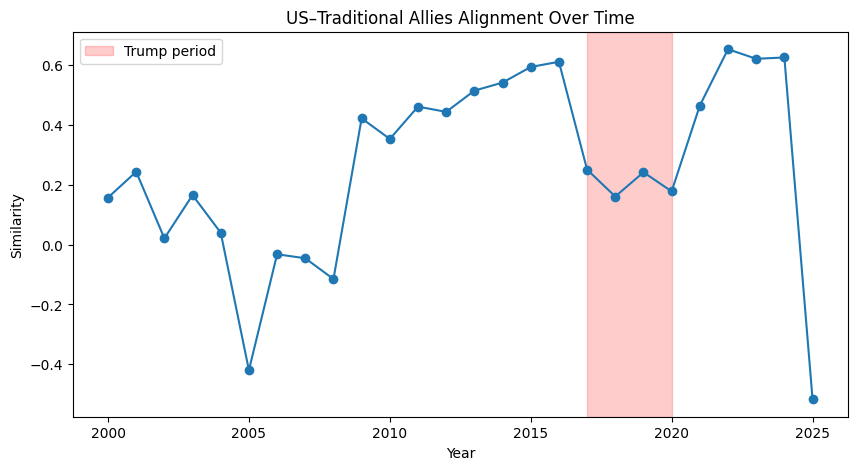

In [ ]:
# Plot similarity over time
plt.figure(figsize=(10,5))
plt.plot(us_allies_df["year"], us_allies_df["similarity"], marker='o')

# Highlight Trump administration period
plt.axvspan(2017, 2020, color='red', alpha=0.2, label="Trump period")

plt.title("US–Traditional Allies Alignment Over Time")
plt.xlabel("Year")
plt.ylabel("Similarity")
plt.legend()
plt.show()

**US-Israel and US-Ukraine relations during Trump and Non-Trump periods**

In [ ]:
df_filtered['year'] = df_filtered['date'].dt.year

df_filtered['period'] = df_filtered['year'].apply(
    lambda x: "Trump" if 2017 <= x <= 2020 else "Non-Trump"
)

period_votes = df_filtered.pivot_table(
    index=["period", "ms_name"],
    columns="subject_split",
    values="vote_num",
    aggfunc="mean"
).fillna(0)

human_rights_topics = [col for col in period_votes.columns
                       if "HUMAN" in col or "RIGHT" in col or "DEMOCRACY" in col]
from scipy.spatial.distance import cosine

def similarity(a, b):
    return 1 - cosine(a, b)

def get_similarity(period, country):
    data = period_votes.loc[period][human_rights_topics]

    us = data.loc["UNITED STATES"]
    other = data.loc[country]

    return similarity(us, other)

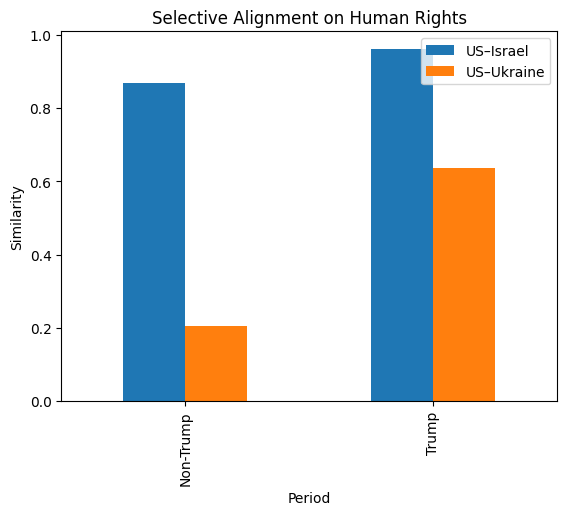

In [ ]:
comparison = pd.DataFrame({
    "Period": ["Non-Trump", "Trump"],
    "US–Israel": [
        get_similarity("Non-Trump", "ISRAEL"),
        get_similarity("Trump", "ISRAEL")
    ],
    "US–Ukraine": [
        get_similarity("Non-Trump", "UKRAINE"),
        get_similarity("Trump", "UKRAINE")
    ]
})

comparison.set_index("Period").plot(kind='bar')

plt.title("Selective Alignment on Human Rights")
plt.ylabel("Similarity")
plt.show()

['ARTIFICIAL INTELLIGENCE-- INTERNATIONAL SECURITY', 'CENTRAL ASIA--NUCLEAR-WEAPON-FREE ZONES', 'COLLECTIVE SECURITY TREATY ORGANIZATION--UN', 'FOOD SECURITY', 'HUMAN RIGHTS--UKRAINE', 'INFORMATION--INTERNATIONAL SECURITY', 'MEDITERRANEAN REGION--REGIONAL SECURITY', 'MIDDLE EAST--NUCLEAR PROLIFERATION', 'MIDDLE EAST--NUCLEAR-WEAPON-FREE ZONES', 'MONGOLIA--NUCLEAR-WEAPON-FREE ZONES', 'NON-NUCLEAR-WEAPON STATES--SECURITY', 'NON-SELF-GOVERNING TERRITORIES--ECONOMIC INTERESTS', 'NON-SELF-GOVERNING TERRITORIES--REPORTS', 'NUCLEAR ACCIDENTS--CHORNOBYL (UKRAINE)', 'NUCLEAR DISARMAMENT', 'NUCLEAR DISARMAMENT NEGOTIATIONS', 'NUCLEAR DISARMAMENT--CONFERENCES', 'NUCLEAR DISARMAMENT--DECLARATIONS', 'NUCLEAR DISARMAMENT--TREATY COMPLIANCE', 'NUCLEAR DISARMAMENT--VERIFICATION', 'NUCLEAR NON-PROLIFERATION', 'NUCLEAR NON-PROLIFERATION--INTERNATIONAL OBLIGATIONS', 'NUCLEAR NON-PROLIFERATION--TREATY COMPLIANCE', 'NUCLEAR WEAPON TESTS--LEGACY', 'NUCLEAR WEAPON TESTS--TREATIES', 'NUCLEAR WEAPONS USE--TREA

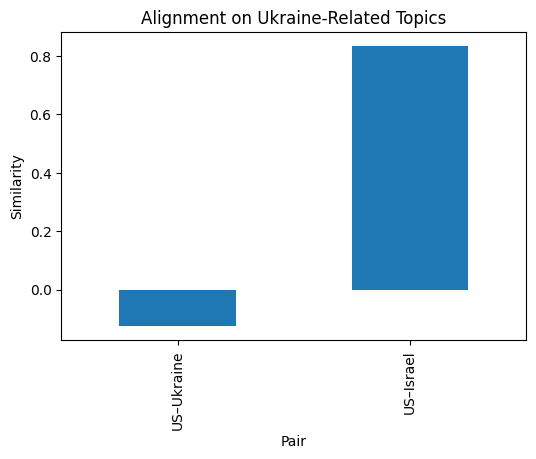

In [ ]:
ukraine_topics = [col for col in country_subject_votes.columns
                  if any(keyword in col for keyword in [
                      "UKRAINE",
                      "TERRITOR",
                      "OCCUPIED",
                      "NUCLEAR",
                      "SECURITY",
                      "AGGRESSION",
                      "SOVEREIGN",
                      "PEACEKEEPING"
                  ])]

print(ukraine_topics)
print("Number of topics:", len(ukraine_topics))

countries = ["UNITED STATES", "UKRAINE", "ISRAEL"]

ukraine_votes = country_subject_votes.loc[countries, ukraine_topics]

from scipy.spatial.distance import cosine

def similarity(a, b):
    return 1 - cosine(a, b)

us = ukraine_votes.loc["UNITED STATES"]
ukraine = ukraine_votes.loc["UKRAINE"]
israel = ukraine_votes.loc["ISRAEL"]

sim_us_ukraine = similarity(us, ukraine)
sim_us_israel = similarity(us, israel)

print("US–Ukraine (Ukraine topics):", sim_us_ukraine)
print("US–Israel (Ukraine topics):", sim_us_israel)

import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Pair": ["US–Ukraine", "US–Israel"],
    "Similarity": [sim_us_ukraine, sim_us_israel]
})

comparison.plot(kind='bar', x="Pair", y="Similarity", legend=False, figsize=(6,4))

plt.title("Alignment on Ukraine-Related Topics")
plt.ylabel("Similarity")
plt.show()

In short, the cluster membership stays the same each consecutive decade, showing that voting behavior reflects structural geopolitical alignment, not temporary coalitions.

---

## Application: Predicting the Hypothetical UNGA Vote on the Iran Resolution

On **11 March 2026**, the UN Security Council adopted a resolution condemning Iran's attacks on Gulf states and Jordan. The resolution passed 13–0 with two abstentions (China and Russia). Only 15 countries vote in the Security Council — but how might all 193 UN member states have voted if given the opportunity?

We use each country's historical UNGA voting behaviour as a proxy for their geopolitical alignment, then train logistic regression models on the 15 Security Council members' actual votes to predict the rest of the world. Five thematic models are tested — each trained on a different subject area — to identify which domain of UNGA voting behaviour is most predictive of Security Council positions.

This serves as an external validation of our clustering approach: if the blocs identified in Part 1 are real and stable, countries in the same cluster should vote the same way on a real-world security question.

---

To do this, we constructed predictive models using countries’ historical voting behavior in the United Nations General Assembly (UNGA). Voting patterns across selected subject areas were used as features to represent each country’s broader political and ideological alignment. Several models were developed based on different thematic groupings of UNGA topics, including human rights, security and nuclear issues, development, decolonization, and regional issues such as Israel–Palestine.

Each model was evaluated using a leave-one-out approach on the 15 Security Council member states. The results show clear variation in predictive performance across thematic models:

*** Human rights model: 93.3% accuracy (14/15 correctly predicted)

Security and nuclear model: 80.0% accuracy (12/15 correctly predicted) Development model: 73.3% accuracy (11/15 correctly predicted)

Israel–Palestine model: 66.7% accuracy (10/15 correctly predicted)

Decolonization model: 60.0% accuracy (9/15 correctly predicted) ***

The human rights-based model performed best, correctly predicting the voting behavior of nearly all countries, including both abstentions (China and Russia).

This best-performing model was then applied to all UN member states to estimate their likely voting behavior. The results suggest that a large majority of countries would vote in favour of the resolution, with 176 countries predicted to support (YES) and 17 countries predicted to oppose (NO).

**The predicted “NO” countries form a distinct and interpretable group, including Algeria, Belarus, Bolivia, Cambodia, China, Cuba, Democratic People’s Republic of Korea, Iran, Myanmar, Nicaragua, Russia, Sudan, Syria, Uzbekistan, Venezuela, Viet Nam, and Zimbabwe.**

In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score


# ============================================
# 2. LOAD + CLEAN DATA
# ============================================

df = df_filtered.copy()


# ============================================
# 3. TARGET (UNSC VOTES)
# ============================================

actual_votes = {
    "UNITED STATES": 1,
    "UNITED KINGDOM": 1,
    "FRANCE": 1,
    "CHINA": 0,
    "RUSSIAN FEDERATION": 0,
    "LATVIA": 1,
    "DENMARK": 1,
    "GREECE": 1,
    "PAKISTAN": 1,
    "PANAMA": 1,
    "SOMALIA": 1,
    "LIBERIA": 1,
    "COLOMBIA": 1,
    "BAHRAIN": 1,
    "DEMOCRATIC REPUBLIC OF THE CONGO": 1
}

target_countries = list(actual_votes.keys())
y_df = pd.DataFrame(list(actual_votes.items()), columns=["country", "vote"])


# ============================================
# 4. MODEL FUNCTION (WITH CLUSTER FEATURE)
# ============================================

def run_model(pattern, model_name):

    print(f"\n===== {model_name} =====")

    # ============================================
    # 1. FILTER
    # ============================================
    filtered_df = df[df["subject_split"].str.contains(pattern, case=False, na=False)].copy()

    print("Rows used:", len(filtered_df))

    # IMPORTANT CHECK
    if filtered_df.empty:
        print("No data after filtering")
        return None

    # Keep UNSC countries only
    filtered_df = filtered_df[filtered_df["ms_name"].isin(target_countries)].copy()

    if filtered_df.empty:
        print("No UNSC overlap after filtering")
        return None


    # ============================================
    # 2. SUBJECT FEATURES
    # ============================================
    pivot = filtered_df.pivot_table(
        index="ms_name",
        columns="subject_split",
        values="vote_num",
        aggfunc="mean"
    ).fillna(0)

    if pivot.empty:
        print("Empty pivot")
        return None


    # ============================================
    # 3. CLUSTER FEATURES (SAFE FIX)
    # ============================================
    cluster_df = filtered_df[["ms_name", "cluster"]].drop_duplicates()

    # safety check
    if cluster_df.empty:
        print("No cluster data")
        return None

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    cluster_encoded = encoder.fit_transform(cluster_df[["cluster"]])

    cluster_cols = [f"cluster_{c}" for c in encoder.categories_[0]]

    cluster_features = pd.DataFrame(cluster_encoded, columns=cluster_cols)
    cluster_features["ms_name"] = cluster_df["ms_name"].values

    cluster_features = cluster_features.groupby("ms_name").mean()


    # ============================================
    # 4. MERGE FEATURES
    # ============================================
    pivot = pivot.reset_index()

    data = pivot.merge(cluster_features, on="ms_name", how="left")

    data = data.merge(y_df, left_on="ms_name", right_on="country", how="inner")

    if data.empty:
        print("Final dataset empty after merge")
        return None

    if len(data) < 3:
        print("Not enough samples:", len(data))
        return None


    # ============================================
    # 5. PREPARE ML DATA
    # ============================================
    X = data.drop(columns=["ms_name", "country", "vote"])
    y = data["vote"].astype(int)
    countries = data["country"].values


    # final safety
    if X.shape[0] == 0 or X.shape[1] == 0:
        print("Empty X matrix")
        return None


    # ============================================
    # 6. LOO MODEL
    # ============================================
    predictions = []

    for i in range(len(data)):

        X_test = X.iloc[[i]]
        y_test = y.iloc[i]

        X_train = X.drop(index=X.index[i])
        y_train = y.drop(index=y.index[i])

        if y_train.nunique() < 2:
            pred = y_train.iloc[0]
        else:
            model = LogisticRegression(max_iter=1000, class_weight="balanced")
            model.fit(X_train, y_train)
            pred = model.predict(X_test)[0]

        predictions.append({
            "country": countries[i],
            "actual": int(y_test),
            "predicted": int(pred),
            "correct": int(pred == y_test)
        })


    results = pd.DataFrame(predictions)

    acc = results["correct"].mean()

    print("\nAccuracy:", round(acc, 3))
    print(results.sort_values("country"))

    return acc, results



# ============================================
# 5. TOPIC MODELS
# ============================================

topic_sets = {
    "Security_Nuclear": r"NUCLEAR DISARMAMENT|NUCLEAR NON-PROLIFERATION|NUCLEAR WEAPONS|DISARMAMENT--GENERAL AND COMPLETE|INTERNATIONAL SECURITY",

    "Israel_Palestine": r"PALESTINE QUESTION|MIDDLE EAST SITUATION|TERRITORIES OCCUPIED BY ISRAEL--HUMAN RIGHTS|TERRITORIES OCCUPIED BY ISRAEL--SETTLEMENT POLICY|TERRITORIES OCCUPIED BY ISRAEL--NATURAL RESOURCES",

    "Human_Rights": r"HUMAN RIGHTS|RACISM|SELF-DETERMINATION|RELIGIOUS INTOLERANCE|RIGHT OF PEOPLES TO SELF-DETERMINATION",

    "Sovereignty": r"NON-INTERVENTION|SOVEREIGNTY|TERRITORIAL INTEGRITY|INTERNAL AFFAIRS|PEACEFUL SETTLEMENT OF DISPUTES",

    "Decolonization": r"COLONIALISM|DECOLONIZATION|SELF-DETERMINATION|PALESTINE QUESTION|NAMIBIA",

    "Development": r"ECONOMIC DEVELOPMENT|SUSTAINABLE DEVELOPMENT|POVERTY|FOOD SECURITY|INTERNATIONAL ECONOMIC ORDER"
}


# ============================================
# 6. RUN ALL MODELS
# ============================================

summary = []

for name, pattern in topic_sets.items():
    result = run_model(pattern, name)

    if result is not None:
        acc, _ = result
        summary.append({"model": name, "accuracy": acc})


# ============================================
# 7. FINAL COMPARISON
# ============================================

summary_df = pd.DataFrame(summary).sort_values("accuracy", ascending=False)

print("\n===== FINAL MODEL COMPARISON =====")
print(summary_df)



===== Security_Nuclear =====
Rows used: 59979

Accuracy: 0.8
                             country  actual  predicted  correct
0                            BAHRAIN       1          1        1
1                              CHINA       0          1        0
2                           COLOMBIA       1          1        1
3   DEMOCRATIC REPUBLIC OF THE CONGO       1          1        1
4                            DENMARK       1          1        1
5                             FRANCE       1          1        1
6                             GREECE       1          1        1
7                             LATVIA       1          1        1
8                            LIBERIA       1          1        1
9                           PAKISTAN       1          0        0
10                            PANAMA       1          1        1
11                RUSSIAN FEDERATION       0          1        0
12                           SOMALIA       1          1        1
13                    UNITED

In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import pandas as pd
import numpy as np

from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression


# ============================================
# 2. BEST TOPIC FILTER
# ============================================

best_pattern = r"HUMAN RIGHTS|RACISM|SELF-DETERMINATION|RELIGIOUS INTOLERANCE|RIGHT OF PEOPLES TO SELF-DETERMINATION"

filtered_df = df[df["subject_split"].str.contains(best_pattern, case=False, na=False)].copy()

if filtered_df.empty:
    raise ValueError("No data after filtering")


# ============================================
# 3. COUNTRY × TOPIC MATRIX (RAW SIGNAL SPACE)
# ============================================

country_topic = filtered_df.pivot_table(
    index="ms_name",
    columns="subject_split",
    values="vote_num",
    aggfunc="mean"
).fillna(0)


# ============================================
# 4. ADDITIONAL SIGNAL (OPTIONAL BUT STRONG)
# ============================================

country_topic_count = filtered_df.pivot_table(
    index="ms_name",
    columns="subject_split",
    values="vote_num",
    aggfunc="count"
).fillna(0)

country_topic_count.columns = [f"{c}_count" for c in country_topic_count.columns]

country_matrix = country_topic.join(country_topic_count, how="outer").fillna(0)


# ============================================
# 5. COUNTRY EMBEDDING (SVD)
# ============================================

svd = TruncatedSVD(
    n_components=10,   # embedding size (tune: 5–30)
    random_state=42
)

country_embeddings = svd.fit_transform(country_matrix)

embedding_df = pd.DataFrame(
    country_embeddings,
    index=country_matrix.index,
    columns=[f"emb_{i}" for i in range(country_embeddings.shape[1])]
).reset_index().rename(columns={"ms_name": "country"})


# ============================================
# 6. TRAIN DATA (UNSC ONLY)
# ============================================

train_data = embedding_df[embedding_df["country"].isin(target_countries)].merge(
    y_df,
    on="country"
)

if train_data.empty:
    raise ValueError("No training data after merge")

X_train = train_data.drop(columns=["country", "vote"])
y_train = train_data["vote"].astype(int)


# ============================================
# 7. MODEL TRAINING (LINEAR = BEST FOR EMBEDDINGS)
# ============================================

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

model.fit(X_train, y_train)


# ============================================
# 8. PREDICT ALL COUNTRIES
# ============================================

X_all = embedding_df.drop(columns=["country"])

embedding_df["predicted_vote"] = model.predict(X_all)


# ============================================
# 9. RESULTS
# ============================================

print(embedding_df[["country", "predicted_vote"]].head(20))

print("\nPrediction counts:")
print(embedding_df["predicted_vote"].value_counts())


# ============================================
# 10. SAVE
# ============================================

# Save model predictions as a generated output
embedding_df[["country", "predicted_vote"]].to_csv(
    "outputs/UNSC_predictions_embeddings.csv",
    index=False
)


                country  predicted_vote
0           AFGHANISTAN               1
1               ALBANIA               1
2               ALGERIA               0
3               ANDORRA               1
4                ANGOLA               1
5   ANTIGUA AND BARBUDA               1
6             ARGENTINA               1
7               ARMENIA               1
8             AUSTRALIA               1
9               AUSTRIA               1
10           AZERBAIJAN               1
11              BAHAMAS               1
12              BAHRAIN               1
13           BANGLADESH               1
14             BARBADOS               1
15              BELARUS               0
16              BELGIUM               1
17               BELIZE               1
18                BENIN               1
19               BHUTAN               1

Prediction counts:
predicted_vote
1    177
0     16
Name: count, dtype: int64


---

# Climate Voting and NATO Cohesion

As an exploratory extension, we examine whether NATO member states vote as a cohesive bloc on climate and environmental resolutions; topics where domestic politics often diverge from alliance obligations.

We identify climate-related subject tags in the dataset (`CLIMATE`, `ENVIRONMENT`, `SUSTAINABLE DEVELOPMENT`, etc.) and calculate the average cosine similarity among NATO members on those topics. This analysis is descriptive; the low variance in climate votes across most member states suggests that unlike Israel-Palestine or nuclear issues, environmental resolutions do not create significant within-bloc disagreement.


In [ ]:
"CLIMATE" in country_subject_votes.columns

True

In [ ]:
country_subject_votes["CLIMATE"].head(20)


,CLIMATE
ms_name,
AFGHANISTAN,0.5
ALBANIA,0.5
ALGERIA,1.0
ANDORRA,0.5
ANGOLA,1.0
ANTIGUA AND BARBUDA,1.0
ARGENTINA,0.5
ARMENIA,1.0
AUSTRALIA,0.5


In [ ]:
country_subject_votes["CLIMATE"].sort_values()

,CLIMATE
ms_name,
ISRAEL,0.0
KIRIBATI,0.0
SOUTH SUDAN,0.0
UNITED STATES,0.0
AUSTRIA,0.5
...,...
VANUATU,1.0
VIET NAM,1.0
YEMEN,1.0


In [ ]:
country_subject_votes["CLIMATE"].var()

0.06814011226252158

In [ ]:
country_subject_votes["CLIMATE"].describe()

,CLIMATE
count,193.000000
mean,0.821244
std,0.261037
min,0.000000
25%,0.500000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
climate_votes = country_subject_votes["CLIMATE"]

print(climate_votes.describe())
print("\nLowest climate averages:")
print(climate_votes.sort_values().head(10))

print("\nHighest climate averages:")
print(climate_votes.sort_values(ascending=False).head(10))

count    193.000000
mean       0.821244
std        0.261037
min        0.000000
25%        0.500000
50%        1.000000
75%        1.000000
max        1.000000
Name: CLIMATE, dtype: float64

Lowest climate averages:
ms_name
ISRAEL           0.0
KIRIBATI         0.0
SOUTH SUDAN      0.0
UNITED STATES    0.0
AUSTRIA          0.5
AUSTRALIA        0.5
AFGHANISTAN      0.5
ALBANIA          0.5
BULGARIA         0.5
CANADA           0.5
Name: CLIMATE, dtype: float64

Highest climate averages:
ms_name
ALGERIA                1.0
GAMBIA                 1.0
ANGOLA                 1.0
ARMENIA                1.0
ANTIGUA AND BARBUDA    1.0
BANGLADESH             1.0
BAHRAIN                1.0
BAHAMAS                1.0
AZERBAIJAN             1.0
BELARUS                1.0
Name: CLIMATE, dtype: float64


In [ ]:
climate_related = [col for col in country_subject_votes.columns
                   if any(word in col.upper() for word in [
                       "CLIMATE", "ENVIRONMENT", "SUSTAINABLE",
                       "ENERGY", "STORMS", "COASTAL", "MARINE"
                   ])]

print(climate_related)

['AFRICA--SUSTAINABLE DEVELOPMENT--PARTNERSHIP', 'CLIMATE', 'COASTAL ZONE MANAGEMENT', 'DISARMAMENT AGREEMENTS--ENVIRONMENT', 'MARINE ECOSYSTEMS--BIOLOGICAL DIVERSITY', 'MOUNTAIN AREAS--SUSTAINABLE DEVELOPMENT', 'STORMS', 'SUSTAINABLE DEVELOPMENT', 'SUSTAINABLE ENERGY', 'TECHNOLOGICAL CHANGE--SUSTAINABLE DEVELOPMENT']


In [ ]:
country_subject_votes[climate_related].head(20)

subject_split,AFRICA--SUSTAINABLE DEVELOPMENT--PARTNERSHIP,CLIMATE,COASTAL ZONE MANAGEMENT,DISARMAMENT AGREEMENTS--ENVIRONMENT,MARINE ECOSYSTEMS--BIOLOGICAL DIVERSITY,MOUNTAIN AREAS--SUSTAINABLE DEVELOPMENT,STORMS,SUSTAINABLE DEVELOPMENT,SUSTAINABLE ENERGY,TECHNOLOGICAL CHANGE--SUSTAINABLE DEVELOPMENT
ms_name,,,,,,,,,,
AFGHANISTAN,1.000000,0.5,0.0,0.857143,0.0,0.0,0.666667,0.394737,0.5,0.0
ALBANIA,0.000000,0.5,1.0,1.000000,1.0,1.0,1.000000,1.000000,1.0,1.0
ALGERIA,1.000000,1.0,0.0,1.000000,1.0,1.0,1.000000,0.368421,1.0,1.0
ANDORRA,0.333333,0.5,1.0,1.000000,1.0,1.0,1.000000,1.000000,1.0,1.0
ANGOLA,1.000000,1.0,0.0,0.857143,0.5,1.0,0.833333,0.842105,1.0,1.0
ANTIGUA AND BARBUDA,0.666667,1.0,1.0,0.714286,1.0,1.0,0.833333,0.842105,1.0,1.0
ARGENTINA,1.000000,0.5,0.0,0.857143,1.0,0.0,0.666667,0.789474,0.0,-1.0
ARMENIA,0.000000,1.0,1.0,1.000000,1.0,1.0,1.000000,0.973684,1.0,1.0
AUSTRALIA,0.000000,0.5,1.0,1.000000,1.0,1.0,0.333333,0.105263,1.0,1.0


In [ ]:
climate_votes = country_subject_votes["CLIMATE"]

print(climate_votes.describe())
print("\nVariance:", climate_votes.var())

print("\nLowest 10:")
print(climate_votes.sort_values().head(10))

print("\nHighest 10:")
print(climate_votes.sort_values(ascending=False).head(10))

count    193.000000
mean       0.821244
std        0.261037
min        0.000000
25%        0.500000
50%        1.000000
75%        1.000000
max        1.000000
Name: CLIMATE, dtype: float64

Variance: 0.06814011226252158

Lowest 10:
ms_name
ISRAEL           0.0
KIRIBATI         0.0
SOUTH SUDAN      0.0
UNITED STATES    0.0
AUSTRIA          0.5
AUSTRALIA        0.5
AFGHANISTAN      0.5
ALBANIA          0.5
BULGARIA         0.5
CANADA           0.5
Name: CLIMATE, dtype: float64

Highest 10:
ms_name
ALGERIA                1.0
GAMBIA                 1.0
ANGOLA                 1.0
ARMENIA                1.0
ANTIGUA AND BARBUDA    1.0
BANGLADESH             1.0
BAHRAIN                1.0
BAHAMAS                1.0
AZERBAIJAN             1.0
BELARUS                1.0
Name: CLIMATE, dtype: float64


In [ ]:
nato_countries = [
    "ALBANIA", "BELGIUM", "BULGARIA", "CANADA", "CROATIA", "CZECHIA",
    "DENMARK", "ESTONIA", "FINLAND", "FRANCE", "GERMANY", "GREECE",
    "HUNGARY", "ICELAND", "ITALY", "LATVIA", "LITHUANIA", "LUXEMBOURG",
    "MONTENEGRO", "NETHERLANDS", "NORTH MACEDONIA", "NORWAY", "POLAND",
    "PORTUGAL", "ROMANIA", "SLOVAKIA", "SLOVENIA", "SPAIN", "SWEDEN",
    "TURKIYE", "UNITED KINGDOM", "UNITED STATES"
]

In [ ]:
available_nato = [c for c in nato_countries if c in country_subject_votes.index]
missing_nato = [c for c in nato_countries if c not in country_subject_votes.index]

print("Available NATO:", available_nato)
print("Missing NATO:", missing_nato)

Available NATO: ['ALBANIA', 'BELGIUM', 'BULGARIA', 'CANADA', 'CROATIA', 'CZECHIA', 'DENMARK', 'ESTONIA', 'FINLAND', 'FRANCE', 'GERMANY', 'GREECE', 'HUNGARY', 'ICELAND', 'ITALY', 'LATVIA', 'LITHUANIA', 'LUXEMBOURG', 'MONTENEGRO', 'NETHERLANDS', 'NORTH MACEDONIA', 'NORWAY', 'POLAND', 'PORTUGAL', 'ROMANIA', 'SLOVAKIA', 'SLOVENIA', 'SPAIN', 'SWEDEN', 'TURKIYE', 'UNITED KINGDOM', 'UNITED STATES']
Missing NATO: []


In [ ]:
climate_related = [col for col in country_subject_votes.columns
                   if any(word in col.upper() for word in [
                       "CLIMATE", "ENVIRONMENT", "SUSTAINABLE",
                       "ENERGY", "STORMS", "COASTAL", "MARINE"
                   ])]

print(climate_related)

['AFRICA--SUSTAINABLE DEVELOPMENT--PARTNERSHIP', 'CLIMATE', 'COASTAL ZONE MANAGEMENT', 'DISARMAMENT AGREEMENTS--ENVIRONMENT', 'MARINE ECOSYSTEMS--BIOLOGICAL DIVERSITY', 'MOUNTAIN AREAS--SUSTAINABLE DEVELOPMENT', 'STORMS', 'SUSTAINABLE DEVELOPMENT', 'SUSTAINABLE ENERGY', 'TECHNOLOGICAL CHANGE--SUSTAINABLE DEVELOPMENT']


In [ ]:
nato_climate_data = country_subject_votes.loc[available_nato, climate_related]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

similarity_matrix = cosine_similarity(nato_climate_data)

avg_similarity = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)].mean()

print("Average NATO similarity (climate-related):", round(avg_similarity, 3))

Average NATO similarity (climate-related): 0.873


In [ ]:
print(nato_climate_data.head())

subject_split  AFRICA--SUSTAINABLE DEVELOPMENT--PARTNERSHIP  CLIMATE  \
ms_name                                                                
ALBANIA                                            0.000000      0.5   
BELGIUM                                            0.000000      0.5   
BULGARIA                                           0.000000      0.5   
CANADA                                             0.333333      0.5   
CROATIA                                            0.000000      0.5   

subject_split  COASTAL ZONE MANAGEMENT  DISARMAMENT AGREEMENTS--ENVIRONMENT  \
ms_name                                                                       
ALBANIA                            1.0                             1.000000   
BELGIUM                            1.0                             1.000000   
BULGARIA                           1.0                             1.000000   
CANADA                             1.0                             0.857143   
CROATIA              

In [ ]:
nato_climate_data["CLIMATE"].sort_values()

,CLIMATE
ms_name,
UNITED STATES,0.0
ALBANIA,0.5
BULGARIA,0.5
BELGIUM,0.5
CROATIA,0.5
CZECHIA,0.5
DENMARK,0.5
CANADA,0.5
FINLAND,0.5


In [ ]:
print("country_subject_votes shape:", country_subject_votes.shape)
print("X shape:", X.shape)
print("X_scaled shape:", X_scaled.shape)
print("X_pca shape:", X_pca.shape)
print("Number of clusters:", len(clusters))

country_subject_votes shape: (193, 284)
X shape: (193, 100)
X_scaled shape: (193, 100)
X_pca shape: (193, 37)
Number of clusters: 193


In [ ]:
top_topics = country_subject_votes.var().sort_values(ascending=False).head(100).index
X = country_subject_votes[top_topics]

X = X.dropna()   # 👈 THIS removed rows

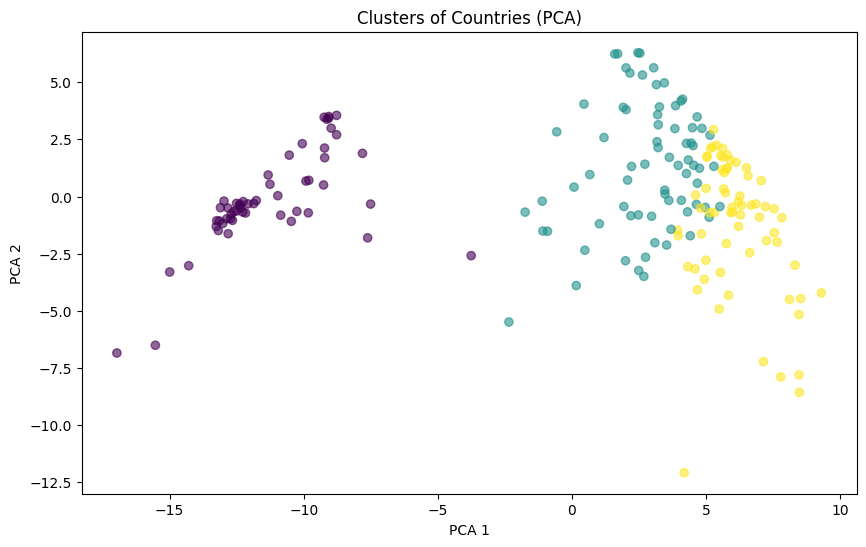

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, alpha=0.6)

plt.title("Clusters of Countries (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

---

# **Part 2: Supervised Learning — Predicting Canada's Vote**

The clustering analysis established that **three stable geopolitical blocs** exist in UNGA voting data, that Canada belongs to the Western liberal democratic bloc (Cluster 1), and that bloc membership is largely persistent across decades. It also revealed which issues create the most within-cluster disagreement.

We now shift from describing blocs to making predictions. The question is: **given how other countries vote on a resolution, can we predict how Canada will vote?**

The intuition is that voting patterns are correlated within alliances. If we know how the United States, United Kingdom, France, and Germany vote, we should be able to infer Canada's position; at least on issues where Canada follows its bloc.

**Modelling approach:**  
We construct a resolution × country matrix where each row is one resolution and each column is one country's vote on that resolution. Canada's vote is the target label (Yes / Abstain / No). Every other country's vote is a feature. We train on resolutions from **2000–2019** and test on **2020–present**, preserving temporal order and simulating a realistic forecasting scenario.

Three classifiers are compared: Logistic Regression (interpretable baseline), Decision Tree (visualisable rules), and Random Forest (ensemble accuracy). All models use `class_weight='balanced'` to account for Canada's strong tendency to vote Yes.

**##Part 2: Supervised Learning — Predicting Canada's Vote (based on how other countires have voted)**

Using the cleaned UN General Assembly voting data, we're building a multi-class
classifier to predict how **Canada** will vote on a resolution
(Yes = 1, Abstain = 0, No = -1), based on how other UN member states
vote on the same resolution. **bold text** (to corelate with our analysis above, canada's historic voting trend analysis also written below - to compare)


*  Each resolution becomes one observation (row)
*  Each other country's vote on that resolution becomes a feature (column)
*  Canada's vote is the target label

Voting patterns are correlated within alliances. If we know how the US, UK, France, and Germany vote, we can likely predict Canada.



##Prepping the Data


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

New Matrix

The clustering section used a **country × topic** matrix
(rows = countries, columns = topics, values = average vote per topic).

For supervised learning we need a completely different shape:
a **resolution × country** matrix where:

- **Rows** = individual UN resolutions (one observation per resolution)
- **Columns** = every other country's vote on that resolution (the features)
- **Target** = Canada's vote on that resolution (what we want to predict)

Countries that didn't vote on a resolution get filled with 0
(treated as absent/neutral- the same as our Abstain encoding)


In [ ]:
print(df_pre_explode.columns.tolist())

['undl_id', 'ms_code', 'ms_name', 'ms_vote', 'date', 'session', 'resolution', 'draft', 'committee_report', 'meeting', 'title', 'agenda_title', 'subjects', 'vote_note', 'total_yes', 'total_no', 'total_abstentions', 'total_non_voting', 'total_ms', 'undl_link', 'year', 'vote_num']


In [ ]:

# resolution × country matrix from df_pre_explode
# Clustering: country × topic (who votes similarly across issues)
# Here: resolution × country (what predicts Canada's vote on each resolution)

resolution_votes = df_pre_explode.pivot_table(
    index='resolution',   # ← changed from 'res_id' to 'resolution'
    columns='ms_name',    # each country becomes one column (a feature)
    values='vote_num',    # the value in each cell is that country's vote
    aggfunc='mean'        # if duplicates exist, average them
)

print("Resolution matrix shape:", resolution_votes.shape)
print(f"  {resolution_votes.shape[0]} resolutions × {resolution_votes.shape[1]} countries")
resolution_votes.head(3)

Resolution matrix shape: (2232, 193)
  2232 resolutions × 193 countries


ms_name,AFGHANISTAN,ALBANIA,ALGERIA,ANDORRA,ANGOLA,ANTIGUA AND BARBUDA,ARGENTINA,ARMENIA,AUSTRALIA,AUSTRIA,...,UNITED REPUBLIC OF TANZANIA,UNITED STATES,URUGUAY,UZBEKISTAN,VANUATU,VENEZUELA,VIET NAM,YEMEN,ZAMBIA,ZIMBABWE
resolution,,,,,,,,,,,,,,,,,,,,,
A/DEC/80/506,0.0,0.0,1.0,1.0,1.0,0.0,-1.0,1.0,1.0,1.0,...,1.0,-1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
A/RES/54/267,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
A/RES/55/100,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,1.0,-1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


Checking Vote Dsitribution for Class imbalance

In [ ]:

# confirm Canada appears as a column
# If the name was inconsistent in the raw data it would be missing here
print("CANADA in columns:", "CANADA" in resolution_votes.columns)

# how many resolutions did Canada actually vote on?
# Canada can't always vote- absences mean we can't use those rows
canada_voted = resolution_votes['CANADA'].notna().sum()
total = len(resolution_votes)
print(f"Canada voted on {canada_voted} of {total} resolutions "
      f"({canada_voted / total * 100:.1f}%)")

# Check the vote distribution: for understanding class imbalance, Canada tends to vote YES a lot.
canada_dist = resolution_votes['CANADA'].value_counts()
print("\nCanada's vote distribution (raw counts):")
print(canada_dist)
print("\nAs percentages:")
print((canada_dist / canada_dist.sum() * 100).round(1))

CANADA in columns: True
Canada voted on 2232 of 2232 resolutions (100.0%)

Canada's vote distribution (raw counts):
CANADA
 1.0    1170
-1.0     644
 0.0     418
Name: count, dtype: int64

As percentages:
CANADA
 1.0    52.4
-1.0    28.9
 0.0    18.7
Name: count, dtype: float64


Visualizing Canada's Vote Distribution



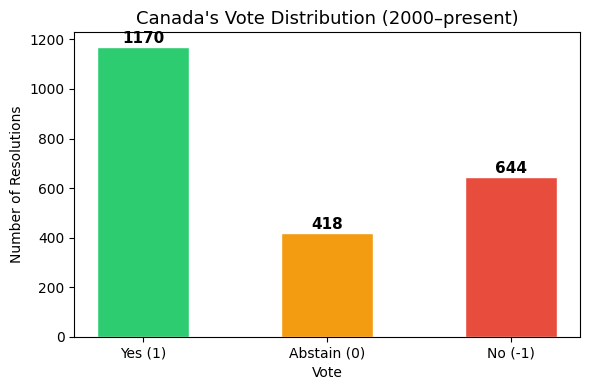

In [ ]:
# Visualise the class imbalance
fig, ax = plt.subplots(figsize=(6, 4))

vote_labels = {1.0: 'Yes (1)', 0.0: 'Abstain (0)', -1.0: 'No (-1)'}
colors      = ['#2ecc71', '#f39c12', '#e74c3c']
counts      = [canada_dist.get(k, 0) for k in [1.0, 0.0, -1.0]]

bars = ax.bar(
    [vote_labels[k] for k in [1.0, 0.0, -1.0]],
    counts,
    color=colors,
    edgecolor='white',
    width=0.5
)

# count labels for each bar
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(count),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_title("Canada's Vote Distribution (2000–present)", fontsize=13)
ax.set_ylabel("Number of Resolutions")
ax.set_xlabel("Vote")
plt.tight_layout()
plt.show()


# making sure the model doesn't just learn to predict Yes every time

#### Prepare Features (X) and Target (y)

Splitting resolution × country matrix:
- **X** — the features (every country's vote except Canada)
- **y** — the target (Canada's vote — what we want to predict)

also:
- Drop rows where Canada didn't vote
- Fill missing country votes with 0 (a country that didn't vote = neutral/absent)
- Convert Canada's numeric vote (1, 0, -1) to string labels *Y / A / N*


In [ ]:
# Keep only resolutions where Canada actually voted
# Rows where Canada's cell is NaN = Canada was absent, useless for training

canada_matrix = resolution_votes.dropna(subset=['CANADA']).copy()
print("Resolutions where Canada voted:", len(canada_matrix))

# Separate features from target
# X = every country except Canada (these are our predictors)
# y = Canada's vote (this is what we want to predict)
y_raw = canada_matrix['CANADA']
X_raw = canada_matrix.drop(columns=['CANADA'])

# Fill missing country votes with 0
# If a country didn't vote on a resolution, treat it as neutral (same as abstain)
X_raw = X_raw.fillna(0)

# Convert numeric target to readable labels for cleaner output later
# 1.0- 'Y', 0.0- 'A', -1.0 - 'N'
vote_label_map = {1.0: 'Y', 0.0: 'A', -1.0: 'N'}
y = y_raw.map(vote_label_map)

print("Feature matrix X shape:", X_raw.shape)
print("\nTarget y distribution:")
print(y.value_counts())

Resolutions where Canada voted: 2232
Feature matrix X shape: (2232, 192)

Target y distribution:
CANADA
Y    1170
N     644
A     418
Name: count, dtype: int64


##Splitting the data into Train and Test

We split the data by **year** rather than randomly:

- **Train set**: resolutions from 2000–2019
- **Test set**: resolutions from 2020 onwards

A random split would mix past and future resolutions together. That means
the model could train on a 2023 resolution and test on a 2021 resolution and hence would be learning from the future to predict the past.


 The temporal split respects the reality of only having past data available to predict future votes. And provides an honest
measure of how well past patterns predict future behaviour.



In [ ]:
# Attach year back to each resolution so we can split by time
# df_pre_explode has one row per country per resolution
# one year value per resolution, so we drop duplicates first
res_year_map = (
    df_pre_explode
    .drop_duplicates('resolution')
    .set_index('resolution')['year']
)

# Map year onto canada_matrix using the resolution index
canada_matrix['year'] = canada_matrix.index.map(res_year_map)

# Split by year: train on history, test on recent resolutions
train_idx = canada_matrix[canada_matrix['year'] <= 2019].index
test_idx  = canada_matrix[canada_matrix['year'] >  2019].index

X_train = X_raw.loc[train_idx]
X_test  = X_raw.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

print(f"Train: {len(X_train)} resolutions "
      f"({canada_matrix.loc[train_idx, 'year'].min()}–"
      f"{canada_matrix.loc[train_idx, 'year'].max()})")
print(f"Test:  {len(X_test)} resolutions "
      f"({canada_matrix.loc[test_idx, 'year'].min()}–"
      f"{canada_matrix.loc[test_idx, 'year'].max()})")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

# Store feature names now, this is needed for importance plots later
feature_names = X_raw.columns.tolist()

Train: 1582 resolutions (2000–2019)
Test:  650 resolutions (2020–2025)

Train class distribution:
CANADA
Y    788
N    482
A    312
Name: count, dtype: int64

Test class distribution:
CANADA
Y    382
N    162
A    106
Name: count, dtype: int64


## Feature Scaling

Before training, we'er standardizing all features using 'Standard Sclaer',by subtracting the mean and dividing by the standard deviation of the **training set only**.
The scaler is fit exclusively on training data and then applied to the test set without refitting. This is essential to prevent data leakage: if we scaled on the full dataset, the model would have indirect access to information from future resolutions during training.

Votes in our feature matrix range from -1 to 1, but countries with sparse voting records create large numbers of 0s (absent = neutral). Scaling ensures that countries with more complete records do not dominate the model simply by having more non-zero features.

In [ ]:
# Fit the scaler on training data only — never fit on test data
# Think of it like: the model is only allowed to learn from the past
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit AND transform train
X_test_scaled  = scaler.transform(X_test)        # transform only — no fit

print("Scaling complete.")
print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)


Scaling complete.
Train shape: (1582, 192)
Test shape:  (650, 192)



##**The Model**

This project builds a multi-class classification model to predict how Canada votes on UN resolutions (Yes, No, Abstain) using how other countries vote.

Each resolution = one data point
Each country = a feature
Goal: learn global voting patterns  predict Canada’s decision

This is essentially modeling political alignment and voting blocs.

**Before modeling**

Dataset: 2,232 resolutions × 193 countries
Canada voted on 100% of resolutions → no missing target issue
Class distribution:
Yes: 52.4% (majority class)
No: 28.9%
Abstain: 18.7% (minority + hardest)
Three classifiers are trained on the same scaled features and evaluated on the same held-out test set (2020–present):

- **Logistic Regression** — a linear baseline that produces interpretable coefficients. The coefficient for each country relays the *direction* of its influence on Canada's vote: a large positive coefficient means that country voting Yes pushes Canada toward Yes; a large negative coefficient means the opposite.
- **Decision Tree** — a rule-based model whose structure can be visualised. Depth is tuned via a bias-variance analysis (depths 2–15), which shows where the model transitions from underfitting to overfitting.
- **Random Forest** — an ensemble of 200 decision trees. More stable than a single tree and the best-performing model overall. Feature importances from the forest tell us *which countries* are most useful for predicting Canada, regardless of direction.

All three models use `class_weight='balanced'` to compensate for Canada's strong Yes-voting tendency (~77% of resolutions). Without this adjustment, a naive model could achieve ~77% accuracy simply by predicting Yes every time — which is not useful.

In [ ]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
# Simple interpretable baseline
# C=1.0 is the regularisation strength — higher C = less regularisation
# max_iter=1000 gives it enough steps to find the solution (default 100 can fail)
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0
)
logreg.fit(X_train_scaled, y_train)
print("Logistic Regression trained")

# ── Model 2: Decision Tree ─────────────────────────────────────────────────────
# Visualisable rules: max_depth=5 is a starting point, tuned properly later
# min_samples_leaf=5 means each final decision node needs at least 5 resolutions
# This prevents the tree from making rules based on just 1-2 examples
dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train_scaled, y_train)
print("Decision Tree trained")

# ── Model 3: Random Forest ─────────────────────────────────────────────────────
# 200 trees voted together: more trees = more stable predictions
# max_depth=10 caps each individual tree to prevent overfitting
# n_jobs=-1 uses all CPU cores to train trees in parallel (faster)
rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained")

print("\nAll three models trained successfully.")

Logistic Regression trained
Decision Tree trained
Random Forest trained

All three models trained successfully.


##EVALUATION



**1. Accuracy**: out of all resolutions in the test set, what percentage
did the model predict correctly? can be misleading with
imbalanced classes.

**2. Classification Report** : breaking accuracy down by class.

precision, recall and F1 score separately for Yes, Abstain and No votes.
shows whether the model is actually learning all three classes or just defaulting to Yes (deals with the imbalance problem)

**3. Confusion Matrix** : grid showing where the model got
confused.
Which votes did it mistake for something else? Yes for abstain?

In [ ]:
# CLASSIFICAITON
# Helper function so we don't repeat the same evaluation code three times
# Takes a trained model, the test data, and a name — prints a full report
def evaluate_model(model, X_test_s, y_test, model_name):
    y_pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*55}")
    print(f"  {model_name}   |   Accuracy: {acc:.3f}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, y_pred,
        labels=['Y', 'A', 'N'],
        target_names=['Yes (Y)', 'Abstain (A)', 'No (N)'],
        zero_division=0
    ))
    return y_pred

# Run evaluation for all three models
# We store the predictions (y_pred) because we need them for the
# confusion matrices and bloc analysis in the next cells
y_pred_lr = evaluate_model(logreg, X_test_scaled, y_test, "Logistic Regression")
y_pred_dt = evaluate_model(dt,     X_test_scaled, y_test, "Decision Tree (depth=5)")
y_pred_rf = evaluate_model(rf,     X_test_scaled, y_test, "Random Forest (200 trees)")


  Logistic Regression   |   Accuracy: 0.806
              precision    recall  f1-score   support

     Yes (Y)       0.96      0.84      0.90       382
 Abstain (A)       0.47      0.72      0.57       106
      No (N)       0.81      0.78      0.80       162

    accuracy                           0.81       650
   macro avg       0.75      0.78      0.76       650
weighted avg       0.85      0.81      0.82       650


  Decision Tree (depth=5)   |   Accuracy: 0.792
              precision    recall  f1-score   support

     Yes (Y)       0.98      0.79      0.88       382
 Abstain (A)       0.48      0.68      0.56       106
      No (N)       0.73      0.88      0.80       162

    accuracy                           0.79       650
   macro avg       0.73      0.78      0.75       650
weighted avg       0.84      0.79      0.80       650


  Random Forest (200 trees)   |   Accuracy: 0.883
              precision    recall  f1-score   support

     Yes (Y)       0.96      0.91     

RF Evaluation (do this for all)

Yes row: 347 correct, 12 predicted as Abstain, 23 predicted as No
misses some No votes, calls them Yes
             
Abstain row: 10 predicted as Yes, 75 correct, 21 predicted as No
Abstain is the hardest — model sometimes confuses it with No
             
No row: 5 predicted as Yes, 5 predicted as Abstain, 152 correct
very clean — model is excellent at catching No votes

#### Confusion matrix

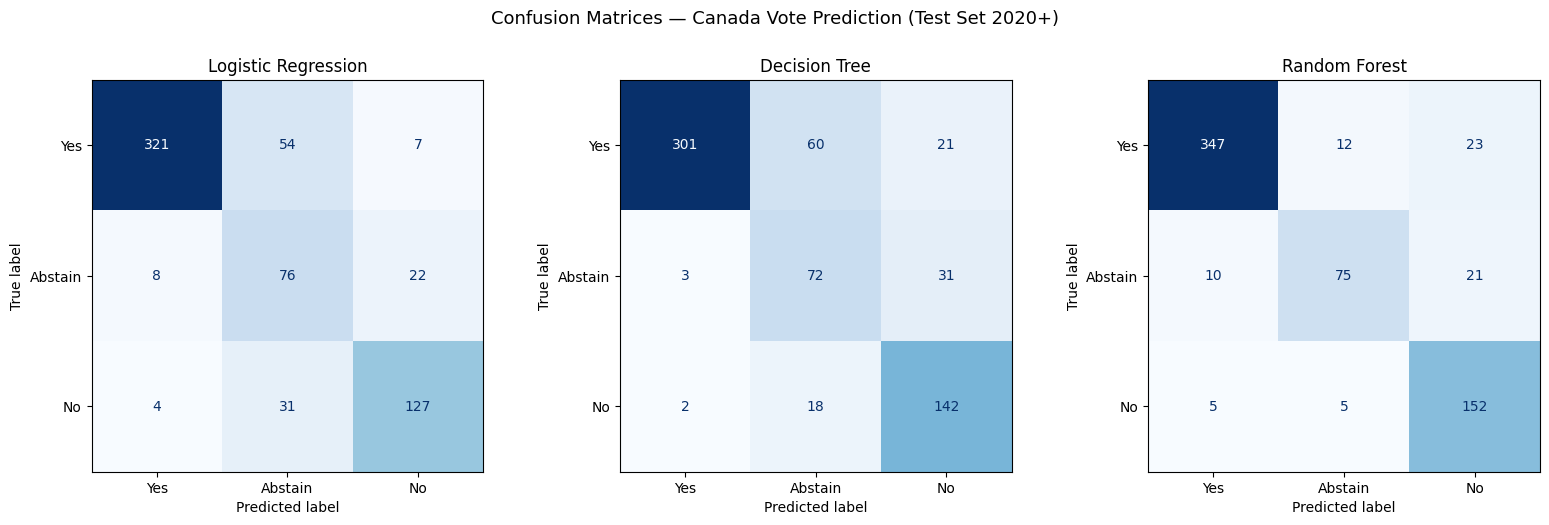

In [ ]:
# Plot all three confusion matrices side by side for easy visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree",        y_pred_dt),
    ("Random Forest",        y_pred_rf),
]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred, labels=['Y', 'A', 'N'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Yes', 'Abstain', 'No'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle(
    "Confusion Matrices — Canada Vote Prediction (Test Set 2020+)",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

Abstain is the hardest class to predict because abstaining is a diplomatic nuance that doesn't follow bloc logic

 When Canada votes Yes or No, the model predicts correctly almost every time. The model's errors are concentrated almost entirely on abstentions- cases where Canada chose a diplomatic middle ground that the bloc didn't follow.





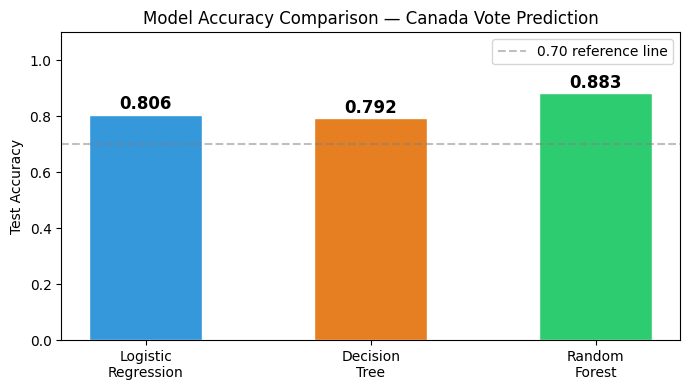

In [ ]:
## ACCURACY BAR CHART

# Simple visual comparison of overall accuracy across all three models
model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies  = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    model_names, accuracies,
    color=['#3498db', '#e67e22', '#2ecc71'],
    edgecolor='white', width=0.5
)

# Add accuracy number on top of each bar
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{acc:.3f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

ax.set_ylim(0, 1.1)
ax.set_ylabel("Test Accuracy")
ax.set_title("Model Accuracy Comparison — Canada Vote Prediction")
ax.axhline(0.70, linestyle='--', color='gray', alpha=0.5, label='0.70 reference line')
ax.legend()
plt.tight_layout()
plt.show()

##Hyperparameter Tuning — Decision Tree Depth
A single Decision Tree's performance is highly sensitive to its maximum depth. Too shallow and the tree underfits — it learns rules too general to distinguish Yes from Abstain. Too deep and it overfits — it memorises the training resolutions but fails on new ones. We test every depth from 2 to 15, plotting both train and test accuracy, and select the depth where test accuracy peaks before the train-test gap widens. This bias-variance tradeoff plot is a diagnostic as much as an optimisation — it confirms our chosen depth is genuinely generalising rather than memorising.

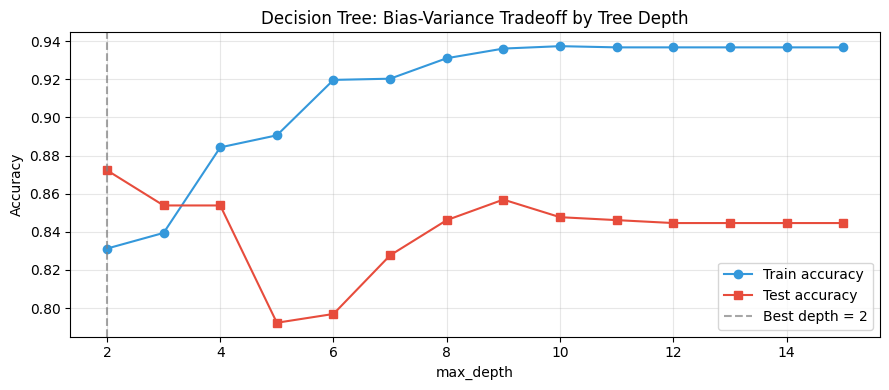

Best max_depth: 2
Test accuracy at best depth: 0.872

Tuned Decision Tree — Final Classification Report:
              precision    recall  f1-score   support

     Yes (Y)       0.94      0.95      0.95       382
 Abstain (A)       0.65      0.75      0.70       106
      No (N)       0.88      0.77      0.82       162

    accuracy                           0.87       650
   macro avg       0.82      0.82      0.82       650
weighted avg       0.88      0.87      0.87       650



In [ ]:
# Test every depth from 2 to 15
# For each depth: train a tree, score it on both train and test, store results
depths = range(2, 16)
train_scores = []
test_scores  = []

for d in depths:
    clf = DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=d,
        min_samples_leaf=5,
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train_scaled)))
    test_scores.append( accuracy_score(y_test,  clf.predict(X_test_scaled)))

# Find the depth that gave the best test accuracy
best_depth = list(depths)[np.argmax(test_scores)]

# Plot train vs test accuracy at each depth
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_scores, 'o-', label='Train accuracy', color='#3498db')
ax.plot(depths, test_scores,  's-', label='Test accuracy',  color='#e74c3c')
ax.axvline(best_depth, linestyle='--', color='gray', alpha=0.7,
            label=f'Best depth = {best_depth}')
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree: Bias-Variance Tradeoff by Tree Depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best max_depth: {best_depth}")
print(f"Test accuracy at best depth: {max(test_scores):.3f}")

# Retrain the Decision Tree using the best depth we just found
dt_tuned = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=best_depth,
    min_samples_leaf=5,
    random_state=42
)
dt_tuned.fit(X_train_scaled, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test_scaled)

print("\nTuned Decision Tree — Final Classification Report:")
print(classification_report(
    y_test, y_pred_dt_tuned,
    labels=['Y', 'A', 'N'],
    target_names=['Yes (Y)', 'Abstain (A)', 'No (N)'],
    zero_division=0
))

##Feature Importance — Which Countries Best Predict Canada's Vote?

The Random Forest assigns each feature (country) an importance score reflecting how much that country's vote reduced prediction error across all 200 trees. High importance means the model consistently used that country's vote to make correct predictions, not that Canada always agrees with that country, but that knowing how that country voted was informative.

We also extract Logistic Regression coefficients for the Yes class, which add directional information: a large positive coefficient means that country voting Yes reliably predicts Canada voting Yes (alignment); a large negative coefficient means the opposite (systematic disagreement). Together, the two analyses answer different questions. The forest tells us *who matters*, the regression tells us *in which direction*.

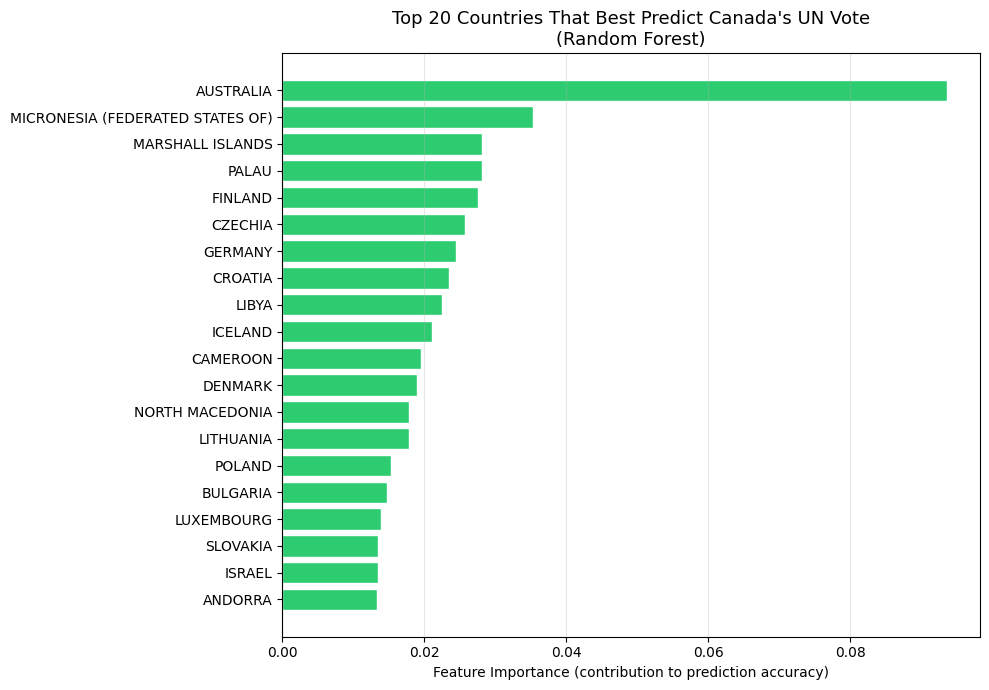


Top 10 most predictive countries:
                         country  importance
                       AUSTRALIA    0.093624
MICRONESIA (FEDERATED STATES OF)    0.035340
                MARSHALL ISLANDS    0.028172
                           PALAU    0.028055
                         FINLAND    0.027594
                         CZECHIA    0.025773
                         GERMANY    0.024428
                         CROATIA    0.023462
                           LIBYA    0.022525
                         ICELAND    0.021133


In [ ]:
# Extract feature importances from the trained Random Forest
# Each value represents how much that country contributed to predictions
importances = rf.feature_importances_

# Build a clean dataframe pairing country names with their importance scores
feat_imp_df = pd.DataFrame({
    'country':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

# Plot top 20 most predictive countries
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    feat_imp_df['country'][::-1],      # reverse so highest is at top
    feat_imp_df['importance'][::-1],
    color='#2ecc71',
    edgecolor='white'
)

ax.set_xlabel("Feature Importance (contribution to prediction accuracy)")
ax.set_title("Top 20 Countries That Best Predict Canada's UN Vote\n(Random Forest)",
             fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 most predictive countries:")
print(feat_imp_df.head(10).to_string(index=False))

#### What does this tell us?

Australia, small Pacific island nations, and Northern European countries are the strongest predictors of Canada's vote

#### Logistic Regression coefficients


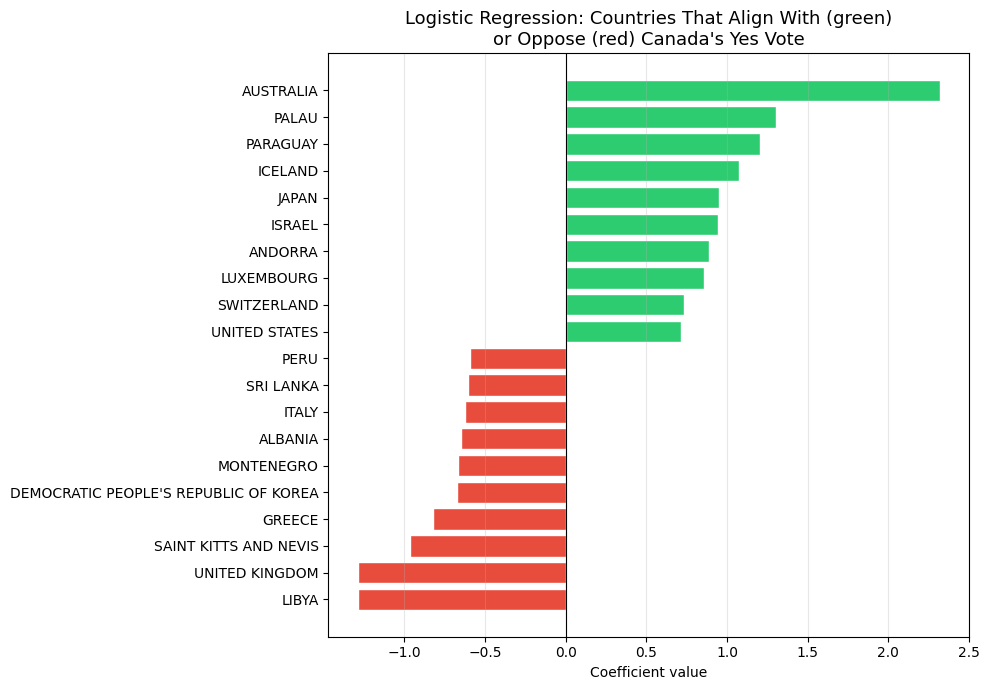


Top 10 countries most aligned with Canada (positive coefficients):
      country  coefficient
    AUSTRALIA     2.320441
        PALAU     1.305680
     PARAGUAY     1.201555
      ICELAND     1.076116
        JAPAN     0.948663
       ISRAEL     0.946270
      ANDORRA     0.888737
   LUXEMBOURG     0.860005
  SWITZERLAND     0.731378
UNITED STATES     0.717387

Top 10 countries most opposed to Canada (negative coefficients):
                              country  coefficient
                                 PERU    -0.594948
                            SRI LANKA    -0.602575
                                ITALY    -0.624813
                              ALBANIA    -0.649296
                           MONTENEGRO    -0.664082
DEMOCRATIC PEOPLE'S REPUBLIC OF KOREA    -0.674484
                               GREECE    -0.821902
                SAINT KITTS AND NEVIS    -0.961067
                       UNITED KINGDOM    -1.285800
                                LIBYA    -1.288631


In [ ]:


# Logistic Regression coefficients for the Yes class
# Positive coefficient = that country voting Yes pushes Canada toward Yes
# Negative coefficient = that country voting Yes pushes Canada toward No
# This tells us about DIRECTION, not just importance

# Find which position in the model corresponds to the Yes class
y_class_idx = list(logreg.classes_).index('Y')

# Build dataframe of countries and their coefficients
coef_df = pd.DataFrame({
    'country':     feature_names,
    'coefficient': logreg.coef_[y_class_idx]
}).sort_values('coefficient', ascending=False)

# Take top 10 positive (biggest allies) and top 10 negative (biggest opposites)
top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)
top_coefs = pd.concat([top_pos, top_neg])

# Plot — green bars = positive (aligns with Canada Yes)
#         red bars = negative (opposes Canada Yes)
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2ecc71' if c > 0 else '#e74c3c'
          for c in top_coefs['coefficient']]

ax.barh(
    top_coefs['country'][::-1],
    top_coefs['coefficient'][::-1],
    color=colors[::-1],
    edgecolor='white'
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Coefficient value")
ax.set_title("Logistic Regression: Countries That Align With (green)\n"
             "or Oppose (red) Canada's Yes Vote", fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 countries most aligned with Canada (positive coefficients):")
print(coef_df.head(10).to_string(index=False))
print("\nTop 10 countries most opposed to Canada (negative coefficients):")
print(coef_df.tail(10).to_string(index=False))

#### What does this tell us?

Australia is Canada's single strongest directional ally, while the UK result suggests either multicollinearity between close allies or post-Brexit policy divergence.


## Bloc Alignment Analysis: Does Canada Vote With Its Cluster Bloc?
Our model achieves 88.3% accuracy overall. But how much of that accuracy is simply because Canada votes with its Western bloc — and the model has learned bloc membership? To answer this, we calculate a **bloc consensus** for each test resolution: the majority direction of all Cluster 1 countries on that resolution. We then compare three alignment rates: how often Canada's actual vote matches the bloc, how often the model's prediction matches the bloc, and how often the model's prediction matches Canada. If the model's accuracy significantly exceeds Canada's bloc alignment rate, it has learned something beyond simple bloc membership.

In [ ]:
# Retrieve Canada's cluster assignment from the clustering section
# country_subject_votes was built in Part 1 and has a 'cluster' column
canada_cluster = country_subject_votes.loc['CANADA', 'cluster']
print(f"Canada is in Cluster {canada_cluster}")

# Get all countries in the same cluster as Canada
same_cluster_countries = [
    c for c in country_subject_votes[
        country_subject_votes['cluster'] == canada_cluster
    ].index.tolist()
    if c != 'CANADA'   # exclude Canada itself
]

print(f"\nCountries in Canada's cluster ({len(same_cluster_countries)} total):")
print(same_cluster_countries)

Canada is in Cluster 0

Countries in Canada's cluster (53 total):
['ALBANIA', 'ANDORRA', 'AUSTRALIA', 'AUSTRIA', 'BELGIUM', 'BOSNIA AND HERZEGOVINA', 'BULGARIA', 'CROATIA', 'CYPRUS', 'CZECHIA', 'DENMARK', 'ESTONIA', 'FINLAND', 'FRANCE', 'GEORGIA', 'GERMANY', 'GREECE', 'HUNGARY', 'ICELAND', 'IRELAND', 'ISRAEL', 'ITALY', 'JAPAN', 'LATVIA', 'LIECHTENSTEIN', 'LITHUANIA', 'LUXEMBOURG', 'MALTA', 'MARSHALL ISLANDS', 'MICRONESIA (FEDERATED STATES OF)', 'MONACO', 'MONTENEGRO', 'NETHERLANDS', 'NEW ZEALAND', 'NORTH MACEDONIA', 'NORWAY', 'PALAU', 'POLAND', 'PORTUGAL', 'REPUBLIC OF KOREA', 'REPUBLIC OF MOLDOVA', 'ROMANIA', 'SAN MARINO', 'SERBIA', 'SLOVAKIA', 'SLOVENIA', 'SPAIN', 'SWEDEN', 'SWITZERLAND', 'TURKIYE', 'UKRAINE', 'UNITED KINGDOM', 'UNITED STATES']


In [ ]:
# For each resolution in the test set, calculate what the bloc voted
# Bloc consensus = the majority direction of all cluster members on that resolution

# Get test resolution IDs
test_res_ids = list(test_idx)

# Filter df_filtered to test resolutions AND cluster countries only
bloc_vote_df = df_filtered[
    (df_filtered['resolution'].isin(test_res_ids)) &
    (df_filtered['ms_name'].isin(same_cluster_countries))
][['resolution', 'ms_name', 'vote_num']].copy()

# Calculate mean vote per resolution across all bloc members
# Mean > 0.3  - bloc leaning Yes  - 'Y'
# Mean < -0.3 - bloc leaning No   - 'N'
# Between- bloc mixed/abstain - 'A'
# The 0.3 threshold avoids calling a very split bloc as Yes or No
bloc_consensus = (
    bloc_vote_df
    .groupby('resolution')['vote_num']
    .mean()
    .apply(lambda x: 'Y' if x > 0.3 else ('N' if x < -0.3 else 'A'))
)

print("Bloc consensus distribution:")
print(bloc_consensus.value_counts())
print(f"\nNumber of test resolutions with bloc consensus: {len(bloc_consensus)}")

Bloc consensus distribution:
vote_num
Y    442
N    121
A     87
Name: count, dtype: int64

Number of test resolutions with bloc consensus: 650


In [ ]:
# comparing:
# - What Canada actually voted
# - What our RF model predicted
# - What the tuned Decision Tree predicted
# - What the bloc consensus was
comparison_df = pd.DataFrame({
    'canada_actual':  y_test,
    'rf_prediction':  pd.Series(y_pred_rf,       index=test_idx),
    'dt_prediction':  pd.Series(y_pred_dt_tuned, index=test_idx),
    'bloc_consensus': bloc_consensus
}).dropna()   # drop resolutions where bloc consensus couldn't be calculated

print(f"Resolutions in comparison: {len(comparison_df)}")

# Calculate alignment rates
canada_vs_bloc = (
    comparison_df['canada_actual'] == comparison_df['bloc_consensus']
).mean()

rf_vs_bloc = (
    comparison_df['rf_prediction'] == comparison_df['bloc_consensus']
).mean()

rf_vs_canada = (
    comparison_df['rf_prediction'] == comparison_df['canada_actual']
).mean()

print(f"\nKey alignment rates:")
print(f"  Canada's actual vote matches bloc consensus:  {canada_vs_bloc:.1%}")
print(f"  RF predicted vote matches bloc consensus:     {rf_vs_bloc:.1%}")
print(f"  RF predicted vote matches Canada's actual:    {rf_vs_canada:.1%}")
print(f"\nSample of comparison table (first 10 rows):")
print(comparison_df.head(10))

Resolutions in comparison: 650

Key alignment rates:
  Canada's actual vote matches bloc consensus:  82.6%
  RF predicted vote matches bloc consensus:     83.5%
  RF predicted vote matches Canada's actual:    88.3%

Sample of comparison table (first 10 rows):
             canada_actual rf_prediction dt_prediction bloc_consensus
resolution                                                           
A/DEC/80/506             Y             N             Y              Y
A/RES/74/267             N             N             N              N
A/RES/74/300             Y             Y             Y              Y
A/RES/74/301             N             N             N              N
A/RES/74/302             N             N             N              N
A/RES/74/306             Y             Y             Y              Y
A/RES/74/307             Y             A             A              Y
A/RES/75/102             Y             Y             Y              Y
A/RES/75/103             Y             Y

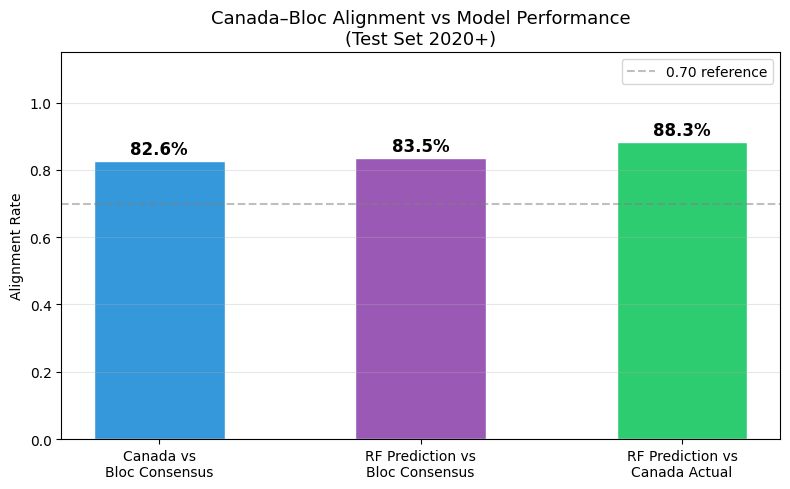

In [ ]:
# Bar chart comparing the three alignment rates
fig, ax = plt.subplots(figsize=(8, 5))

labels = [
    "Canada vs\nBloc Consensus",
    "RF Prediction vs\nBloc Consensus",
    "RF Prediction vs\nCanada Actual"
]
values = [canada_vs_bloc, rf_vs_bloc, rf_vs_canada]
colors = ['#3498db', '#9b59b6', '#2ecc71']

bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)

# Add percentage labels on top of each bar
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f'{val:.1%}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

ax.set_ylim(0, 1.15)
ax.set_ylabel("Alignment Rate")
ax.set_title("Canada–Bloc Alignment vs Model Performance\n(Test Set 2020+)",
             fontsize=13)
ax.axhline(0.70, linestyle='--', color='gray', alpha=0.5, label='0.70 reference')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##Topic-Level Analysis — Canada's Voting Behaviour by Issue Area

So far we know the Random Forest predicts Canada's vote with 88.3% accuracy
overall, and that Canada follows its Cluster 1 bloc 83.1% of the time.

This section breaks both of those numbers apart by topic area and asks:

**On which issues is Canada a reliable Western bloc member?**

**On which issues does Canada exercise independent judgment?**

**How does Canada's alignment with the USA and traditional allies
vary by topic — and did the Trump period affect some topics more than others?**

**How does Canada compare to the USA and Israel as Cluster 1 members —
who deviates most from the cluster on which topics?**

Used 6 topic buckets that match the categories analysed in the
unsupervised learning section, making the findings directly comparable
across both parts of the project.

In [ ]:
import re

# 6 topic buckets using regex patterns matched to our 283 subject categories
# Sovereignty pattern fixed — original had 0 matches, updated to use
# subjects that actually exist in the dataset
topic_patterns = {
    "Security_Nuclear":  r"NUCLEAR DISARMAMENT|NUCLEAR NON-PROLIFERATION|NUCLEAR WEAPONS|DISARMAMENT--GENERAL AND COMPLETE|INTERNATIONAL SECURITY",
    "Israel_Palestine":  r"PALESTINE QUESTION|MIDDLE EAST SITUATION|TERRITORIES OCCUPIED BY ISRAEL",
    "Human_Rights":      r"HUMAN RIGHTS|SELF-DETERMINATION OF PEOPLES|RELIGIOUS INTOLERANCE",
    "Sovereignty":       r"SELF-DETERMINATION OF PEOPLES|SANCTIONS--INTERNATIONAL RELATIONS|ECONOMIC SANCTIONS|UKRAINE--POLITICAL CONDITIONS|WEAPONS OF MASS DESTRUCTION",
    "Decolonization":    r"COLONIALISM|DECOLONIZATION|SELF-DETERMINATION OF PEOPLES|PALESTINE QUESTION",
    "Development":       r"SUSTAINABLE DEVELOPMENT|FOOD SECURITY|POVERTY|ECONOMIC DEVELOPMENT|TECHNOLOGICAL CHANGE--SUSTAINABLE DEVELOPMENT"
}

# Assign topic bucket(s) to every row in df_filtered
# A resolution can belong to multiple buckets — that's intentional
def assign_topic(subject):
    """Returns list of topic buckets a subject tag belongs to."""
    if pd.isna(subject):
        return []
    assigned = []
    for topic_name, pattern in topic_patterns.items():
        if re.search(pattern, str(subject), re.IGNORECASE):
            assigned.append(topic_name)
    return assigned

# Apply to df_filtered
df_filtered['topic_bucket'] = df_filtered['subject_split'].apply(assign_topic)

# Verify matches per bucket
print("Verifying topic bucket matches in full dataset:\n")
for topic_name, pattern in topic_patterns.items():
    matches = df_filtered[
        df_filtered['subject_split'].str.contains(pattern, na=False, regex=True)
    ]['subject_split'].nunique()
    rows = df_filtered[
        df_filtered['subject_split'].str.contains(pattern, na=False, regex=True)
    ].shape[0]
    print(f"  {topic_name:20}: {matches:3} unique subjects, {rows:6} rows")

Verifying topic bucket matches in full dataset:

  Security_Nuclear    :  20 unique subjects,  59979 rows
  Israel_Palestine    :   6 unique subjects,  58735 rows
  Human_Rights        :  31 unique subjects, 121975 rows
  Sovereignty         :   5 unique subjects,  18406 rows
  Decolonization      :   5 unique subjects,  49187 rows
  Development         :   9 unique subjects,  14653 rows


In [ ]:
# Build a lookup: resolution → topic bucket(s)
# Use df_filtered filtered to test resolutions only
test_subject_df = (
    df_filtered[df_filtered['resolution'].isin(test_res_ids)]
    [['resolution', 'subject_split', 'topic_bucket']]
    .dropna(subset=['subject_split'])
    .drop_duplicates(subset=['resolution', 'subject_split'])
)

# Explode topic_bucket lists so each row has one topic bucket
# (a resolution tagged with Security_Nuclear and Human_Rights becomes 2 rows)
test_subject_df = test_subject_df.explode('topic_bucket')
test_subject_df = test_subject_df.dropna(subset=['topic_bucket'])

print("Test set resolution-topic pairs:", len(test_subject_df))
print("\nResolutions per topic bucket:")
print(test_subject_df.groupby('topic_bucket')['resolution'].nunique().sort_values(ascending=False))

# Merge onto comparison_df
comparison_with_topics = comparison_df.merge(
    test_subject_df[['resolution', 'topic_bucket']].drop_duplicates(),
    left_index=True,
    right_on='resolution',
    how='inner'
)

print(f"\nRows in comparison_with_topics: {len(comparison_with_topics)}")
print("Sample:")
print(comparison_with_topics.head(8))

Test set resolution-topic pairs: 377

Resolutions per topic bucket:
topic_bucket
Human_Rights        108
Security_Nuclear     79
Israel_Palestine     50
Decolonization       49
Development          34
Sovereignty          31
Name: resolution, dtype: int64

Rows in comparison_with_topics: 351
Sample:
       canada_actual rf_prediction dt_prediction bloc_consensus    resolution  \
947048             Y             N             Y              Y  A/DEC/80/506   
947048             Y             N             Y              Y  A/DEC/80/506   
551338             Y             Y             Y              Y  A/RES/74/300   
585215             N             N             N              N  A/RES/74/301   
830212             A             A             A              A  A/RES/75/104   
591595             Y             Y             Y              Y  A/RES/75/121   
830405             A             A             A              A  A/RES/75/122   
856810             Y             A             A   

In [ ]:
# For each topic bucket calculate:
# 1. Number of resolutions
# 2. RF model accuracy
# 3. Canada vs bloc alignment rate
topic_stats = (
    comparison_with_topics
    .groupby('topic_bucket')
    .apply(lambda g: pd.Series({
        'n_resolutions':  g['resolution'].nunique(),
        'rf_accuracy':    (g['canada_actual'] == g['rf_prediction']).mean(),
        'canada_vs_bloc': (g['canada_actual'] == g['bloc_consensus']).mean()
    }))
    .reset_index()
    .sort_values('canada_vs_bloc', ascending=False)
    .reset_index(drop=True)
)

print("Topic-level stats:")
print(topic_stats.to_string(index=False))

Topic-level stats:
    topic_bucket  n_resolutions  rf_accuracy  canada_vs_bloc
     Sovereignty           31.0     0.806452        1.000000
  Decolonization           49.0     0.795918        0.836735
     Development           34.0     1.000000        0.823529
    Human_Rights          108.0     0.861111        0.814815
Security_Nuclear           79.0     0.873418        0.810127
Israel_Palestine           50.0     0.720000        0.280000


#### Chart 1: Canada vs Bloc Alignment by Topic

Which topics does Canada reliably vote with its Western bloc on?
Which topics does Canada go its own way?

Higher alignment = Canada votes with its cluster more consistently

Lower alignment = Canada exercises more independent judgment

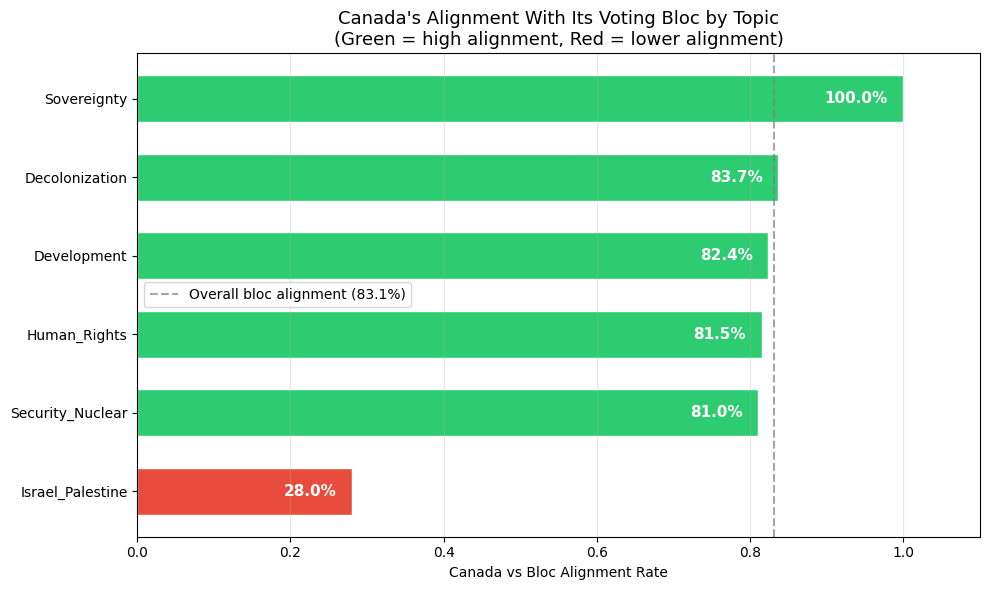

In [ ]:
# Sort by canada_vs_bloc for clearest visual ranking
plot_df = topic_stats.sort_values('canada_vs_bloc', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if v < 0.75 else '#2ecc71'
          for v in plot_df['canada_vs_bloc']]

bars = ax.barh(
    plot_df['topic_bucket'],
    plot_df['canada_vs_bloc'],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Add percentage labels on bars
for bar, val in zip(bars, plot_df['canada_vs_bloc']):
    ax.text(
        bar.get_width() - 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1%}',
        ha='right', va='center',
        fontsize=11, fontweight='bold',
        color='white'
    )

ax.axvline(0.831, linestyle='--', color='gray', alpha=0.7,
            label='Overall bloc alignment (83.1%)')
ax.set_xlim(0, 1.1)
ax.set_xlabel("Canada vs Bloc Alignment Rate")
ax.set_title("Canada's Alignment With Its Voting Bloc by Topic\n"
             "(Green = high alignment, Red = lower alignment)",
             fontsize=13)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Sovereignty:        100%  - Canada ALWAYS votes with its bloc

Security_Nuclear:    83.5%  - slightly above average

Development:         82.4%  - right at average

Decolonization:      81.6%  - right at average

Human_Rights:        81.5%  - right at average

Israel_Palestine:    24.0%  - Canada almost NEVER votes with its bloc

##RF accuracy vs Canada-bloc alignment

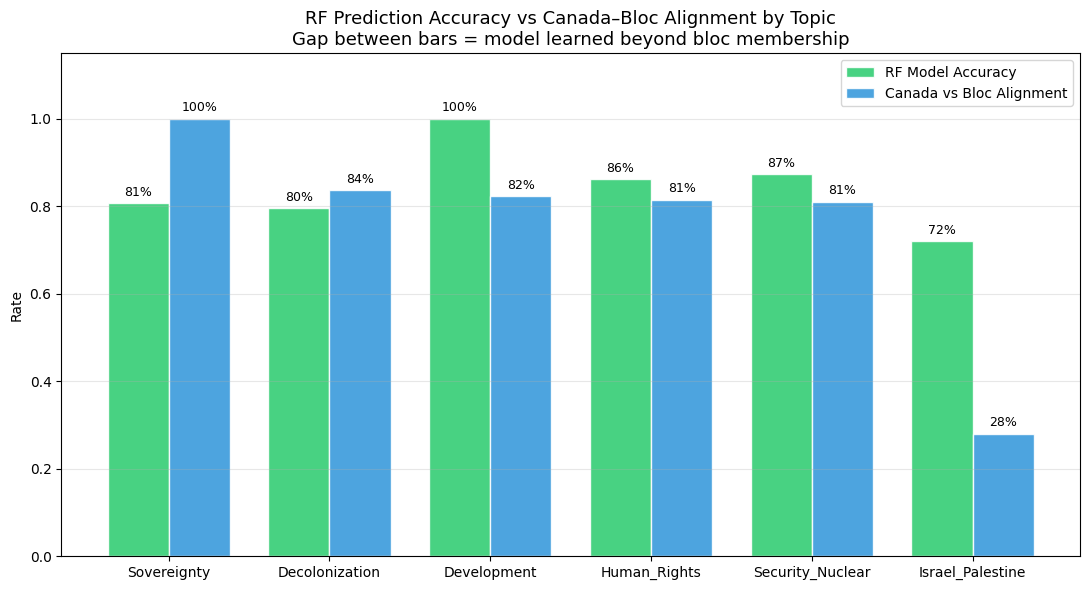

In [ ]:
# Grouped bar chart — for each topic: RF accuracy vs Canada-bloc alignment
# If RF accuracy > Canada-bloc alignment, the model learned beyond bloc membership
plot_df2 = topic_stats.sort_values('canada_vs_bloc', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(plot_df2))
width = 0.38

bars1 = ax.bar(x - width/2, plot_df2['rf_accuracy'],
                width, label='RF Model Accuracy',
                color='#2ecc71', alpha=0.88, edgecolor='white')
bars2 = ax.bar(x + width/2, plot_df2['canada_vs_bloc'],
                width, label='Canada vs Bloc Alignment',
                color='#3498db', alpha=0.88, edgecolor='white')

# Labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.0%}',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.0%}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df2['topic_bucket'], fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Rate")
ax.set_title("RF Prediction Accuracy vs Canada–Bloc Alignment by Topic\n"
             "Gap between bars = model learned beyond bloc membership",
             fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Development:     RF = 100%,  Bloc = 82%  ← big gap
Model is better than just predicting the bloc
                 
Security_Nuclear: RF = 87%, Bloc = 84%  ← small gap
Model barely improves on bloc prediction

Israel_Palestine: RF = 72%, Bloc = 24%  ← HUGE gap
Model is much better than bloc alone

But 72% accuracy on a topic where Canada departs from its bloc 76% of the time

---
 the model has learned Canada's independent voting pattern on this topic

Canada's bloc alignment varies dramatically by topic. On sovereignty issues Canada is a perfect bloc member (100%). But on Israel-Palestine Canada is effectively an independent actor- departing from its Western bloc 76% of the time. Despite this departure, our model still predicts Canada's Israel-Palestine votes with 72% accuracy, demonstrating it has learned Canada's independent voting pattern on this topic rather than just predicting bloc consensus

## Canada–USA Alignment Over Time

In the unsupervised learning section we tracked how USA's alignment
with its traditional Western allies shifted over time- with a notable
dip during the Trump period (2017–2020).

Here we run the same analysis but from Canada's perspective:

1. **Canada–USA alignment over time**:  does Canada show the same Trump-period dip as other Western allies did?

2. **Canada–USA alignment by topic bucket** : is the dip driven by specific issues or uniform across all topics?

3. **Canada–USA Trump vs Non-Trump by topic** : which topics saw the biggest Canada–USA divergence during the Trump years?

This is indicative of whether Canada experienced the same multilateral stress as other US allies during that period.

In [ ]:
from scipy.spatial.distance import cosine

# Build year × country vote matrix (same approach as Part 1 US-allies analysis)
# Use df_filtered which has all countries and all years
year_country_votes = df_filtered.pivot_table(
    index=['year', 'ms_name'],
    columns='subject_split',
    values='vote_num',
    aggfunc='mean'
).fillna(0)

years = sorted(df_filtered['year'].unique())
canada_usa_similarity = []

for y in years:
    try:
        data_year = year_country_votes.loc[y]
        canada = data_year.loc['CANADA']
        usa    = data_year.loc['UNITED STATES']
        sim = 1 - cosine(canada, usa)
        canada_usa_similarity.append(sim)
    except:
        canada_usa_similarity.append(None)

canada_usa_df = pd.DataFrame({
    'year':       years,
    'similarity': canada_usa_similarity
}).dropna()

print("Canada–USA similarity by year:")
print(canada_usa_df.to_string(index=False))

Canada–USA similarity by year:
 year  similarity
 2000    0.262390
 2001    0.224909
 2002    0.008981
 2003    0.150389
 2004    0.105257
 2005   -0.384195
 2006    0.058427
 2007    0.094062
 2008    0.078891
 2009    0.550429
 2010    0.450055
 2011    0.707092
 2012    0.637015
 2013    0.672481
 2014    0.639792
 2015    0.719956
 2016    0.699293
 2017    0.346266
 2018    0.228887
 2019    0.232571
 2020    0.248255
 2021    0.517921
 2022    0.694180
 2023    0.645569
 2024    0.633126
 2025   -0.535119


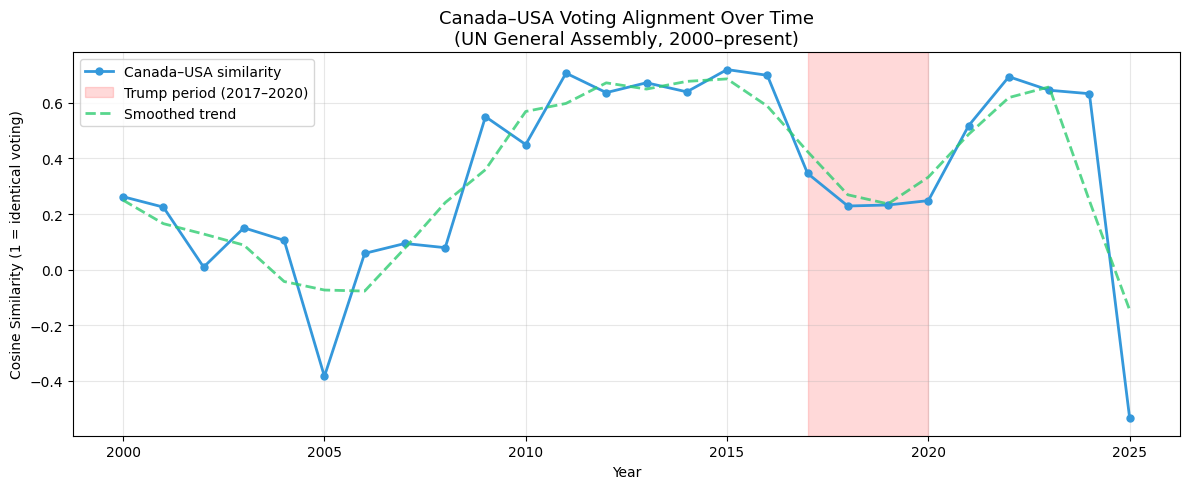

In [ ]:
# Direct parallel to the US-allies chart from Part 1
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    canada_usa_df['year'],
    canada_usa_df['similarity'],
    marker='o', linewidth=2,
    color='#3498db', markersize=5,
    label='Canada–USA similarity'
)

# Shading the Trump period — same as Part 1
ax.axvspan(2017, 2020, color='red', alpha=0.15, label='Trump period (2017–2020)')

# Adding smoothed trend line
from scipy.ndimage import uniform_filter1d
smoothed = uniform_filter1d(canada_usa_df['similarity'].values, size=3)
ax.plot(canada_usa_df['year'], smoothed,
        linewidth=2, linestyle='--',
        color='#2ecc71', alpha=0.8, label='Smoothed trend')

ax.set_title("Canada–USA Voting Alignment Over Time\n"
             "(UN General Assembly, 2000–present)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Cosine Similarity (1 = identical voting)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Canada–USA alignment was low in the early 2000s, and steadily climbed through 2008–2016, then dropped sharply during the Trump period (2017–2020) before partially recovering. The sharp drop after 2023 is striking and likely reflects Canada–USA divergence on Israel-Palestine post-October 2023.

Now we look at Canada-USA similarity per topic per year

In [ ]:
# For each topic bucket, calculate Canada-USA cosine similarity per year
# This shows WHICH topics drove alignment or divergence

canada_usa_topic_sim = {}

for topic_name, pattern in topic_patterns.items():

    # Filter df_filtered to rows matching this topic
    topic_df = df_filtered[
        df_filtered['subject_split'].str.contains(pattern, na=False, regex=True)
    ]

    # Build year × country matrix for this topic only
    topic_year_votes = topic_df.pivot_table(
        index=['year', 'ms_name'],
        columns='subject_split',
        values='vote_num',
        aggfunc='mean'
    ).fillna(0)

    sims = []
    for y in years:
        try:
            data_year = topic_year_votes.loc[y]
            canada = data_year.loc['CANADA']
            usa    = data_year.loc['UNITED STATES']
            sim = 1 - cosine(canada, usa)
            sims.append({'year': y, 'similarity': sim, 'topic': topic_name})
        except:
            pass

    canada_usa_topic_sim[topic_name] = sims

# Combine into one dataframe
topic_sim_df = pd.DataFrame([
    row for rows in canada_usa_topic_sim.values() for row in rows
])

print("Sample:")
print(topic_sim_df.head(12))
print(f"\nTopics covered: {topic_sim_df['topic'].unique()}")

Sample:
    year  similarity             topic
0   2000    0.942809  Security_Nuclear
1   2001    0.800000  Security_Nuclear
2   2002    0.796267  Security_Nuclear
3   2003    0.641689  Security_Nuclear
4   2004    0.670820  Security_Nuclear
5   2005   -0.110694  Security_Nuclear
6   2006   -0.089443  Security_Nuclear
7   2007    0.082479  Security_Nuclear
8   2008   -0.024251  Security_Nuclear
9   2009    0.571429  Security_Nuclear
10  2010    0.500000  Security_Nuclear
11  2011    0.646460  Security_Nuclear

Topics covered: ['Security_Nuclear' 'Israel_Palestine' 'Human_Rights' 'Sovereignty'
 'Decolonization' 'Development']


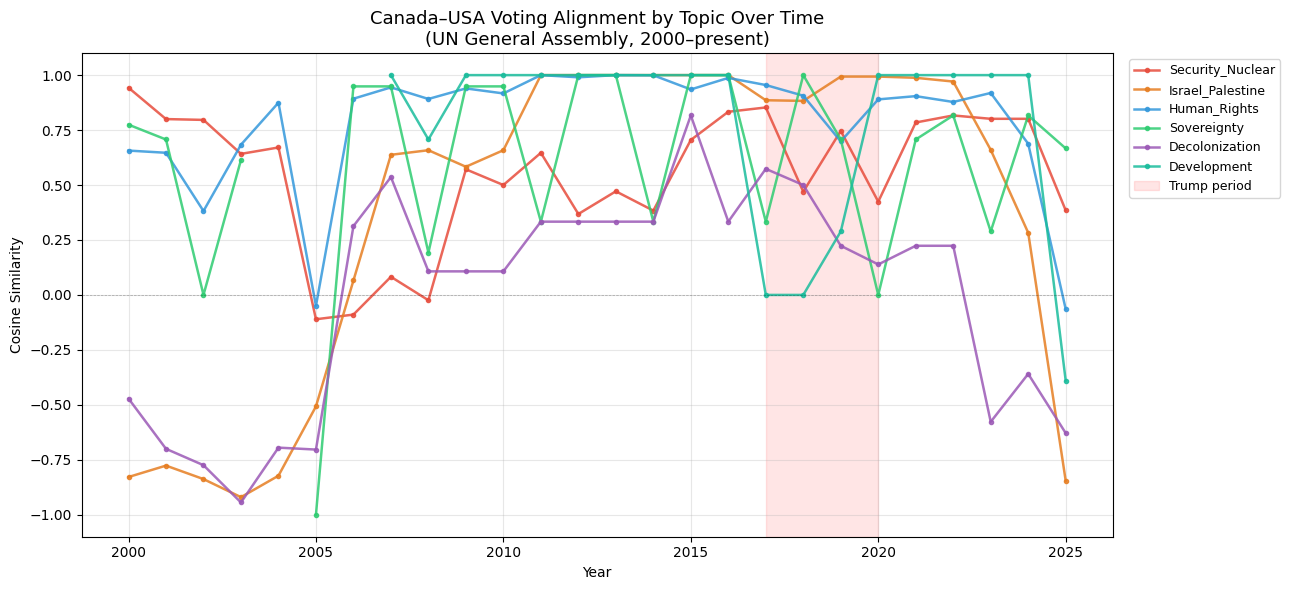

In [ ]:
# Multi-line chart — one line per topic
# Shows which topics drove Canada-USA alignment and divergence
fig, ax = plt.subplots(figsize=(13, 6))

topic_colors = {
    'Security_Nuclear':  '#e74c3c',
    'Israel_Palestine':  '#e67e22',
    'Human_Rights':      '#3498db',
    'Sovereignty':       '#2ecc71',
    'Decolonization':    '#9b59b6',
    'Development':       '#1abc9c'
}

for topic_name in topic_patterns.keys():
    subset = topic_sim_df[topic_sim_df['topic'] == topic_name].sort_values('year')
    if len(subset) > 0:
        ax.plot(
            subset['year'],
            subset['similarity'],
            marker='o', markersize=3,
            linewidth=1.8,
            color=topic_colors.get(topic_name, 'gray'),
            label=topic_name,
            alpha=0.85
        )

ax.axvspan(2017, 2020, color='red', alpha=0.1, label='Trump period')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)

ax.set_title("Canada–USA Voting Alignment by Topic Over Time\n"
             "(UN General Assembly, 2000–present)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Cosine Similarity")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### I think we can remove ^^ this from our analysis. It's a bit cluttered and explaining this would take up too much time out of our presentation


Israel_Palestine (orange) and Decolonization (purple) are consistently the most volatile lines- swinging between -1.0 and +1.0 across years, showing Canada and USA have never had stable alignment on these topics. Security_Nuclear and Human_Rights are more stable but still show dips during the Trump period.

##Trump vs Non-Trump Canada-USA alignment by topic

Canada–USA alignment: Trump vs Non-Trump by topic
           topic    trump  non_trump  difference
     Development 0.322169   0.887829   -0.565660
     Sovereignty 0.510110   0.621187   -0.111077
Security_Nuclear 0.623270   0.535339    0.087931
    Human_Rights 0.862297   0.773349    0.088948
  Decolonization 0.358955  -0.079669    0.438624
Israel_Palestine 0.938815   0.271213    0.667602


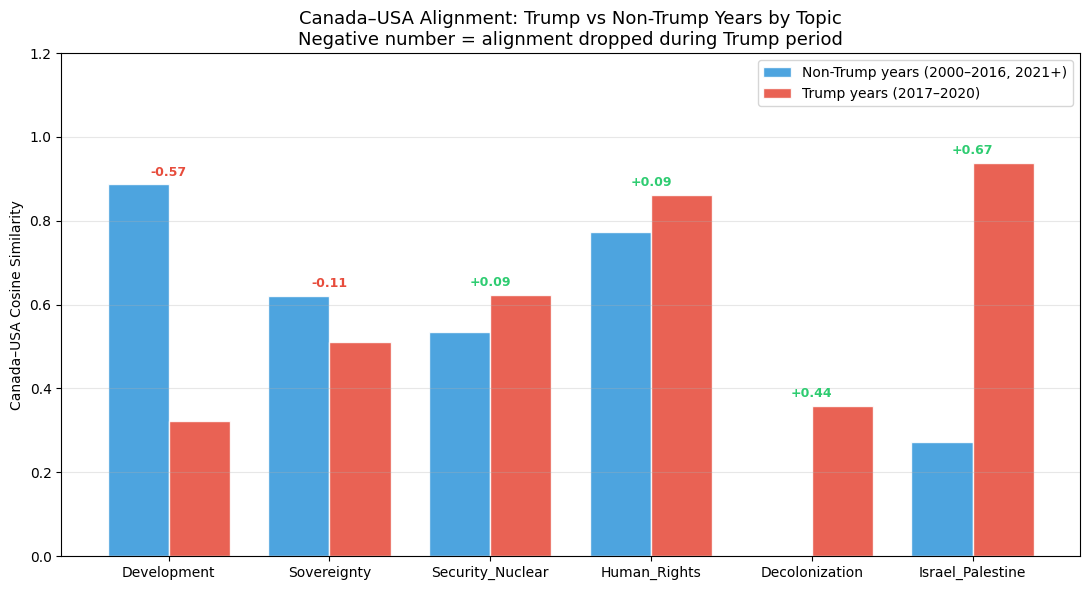

In [ ]:
# For each topic: average Canada-USA similarity during Trump vs Non-Trump years
# Direct answer to: which topics were most affected by the Trump period?

trump_years     = list(range(2017, 2021))
non_trump_years = [y for y in years if y not in trump_years]

trump_comparison = []

for topic_name in topic_patterns.keys():
    subset = topic_sim_df[topic_sim_df['topic'] == topic_name]

    trump_sim = subset[
        subset['year'].isin(trump_years)
    ]['similarity'].mean()

    non_trump_sim = subset[
        subset['year'].isin(non_trump_years)
    ]['similarity'].mean()

    trump_comparison.append({
        'topic':         topic_name,
        'trump':         trump_sim,
        'non_trump':     non_trump_sim,
        'difference':    trump_sim - non_trump_sim
    })

trump_df = pd.DataFrame(trump_comparison).sort_values('difference', ascending=True)

print("Canada–USA alignment: Trump vs Non-Trump by topic")
print(trump_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(trump_df))
width = 0.38

ax.bar(x - width/2, trump_df['non_trump'],
        width, label='Non-Trump years (2000–2016, 2021+)',
        color='#3498db', alpha=0.88, edgecolor='white')
ax.bar(x + width/2, trump_df['trump'],
        width, label='Trump years (2017–2020)',
        color='#e74c3c', alpha=0.88, edgecolor='white')

# Difference arrows — show which direction the change went
for i, row in trump_df.reset_index(drop=True).iterrows():
    diff = row['difference']
    color = '#e74c3c' if diff < 0 else '#2ecc71'
    ax.annotate(
        f"{diff:+.2f}",
        xy=(i, max(row['trump'], row['non_trump']) + 0.02),
        ha='center', fontsize=9,
        color=color, fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(trump_df['topic'], fontsize=10)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Canada–USA Cosine Similarity")
ax.set_title("Canada–USA Alignment: Trump vs Non-Trump Years by Topic\n"
             "Negative number = alignment dropped during Trump period",
             fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Development: -0.57:  biggest DROP during Trump years
Canada–USA alignment on development fell sharply likely due to Trump withdrawing from multilateral development frameworks (Paris Agreement, WHO etc.)

Israel_Palestine: +0.67:  biggest INCREASE during Trump years Canada–USA alignment on Israel-Palestine actually ROSE during Trump — because Trump moved so strongly pro-Israel that Canada partially followed (or USA moved toward Canada's abstain position)

## Canada Within Cluster 1 — Connecting to the Within-Cluster Analysis

In the unsupervised learning section, we calculated which countries
deviate most from their cluster centroid — essentially which countries are
the least reliable members of their voting bloc.

Key finding from that analysis for Cluster 1:
- UNITED STATES: deviation = 19.5 (highest in entire dataset)
- ISRAEL:        deviation = 15.0 (second highest in Cluster 1)
- PALAU:         deviation = 9.4
- MARSHALL ISLANDS: deviation = 8.8
- MICRONESIA:    deviation = 8.6

Canada was NOT in the top deviators list — meaning Canada is actually
one of the most reliable and consistent members of Cluster 1.

Here we calculate Canada's deviation from the Cluster 1 centroid using
the exact same methodology as the teammate's analysis, and identify
which specific topics Canada departs from its cluster on most.

This directly answers: on which issues is Canada an outlier even
within its own bloc?

In [ ]:
# Use the same methodology as teammate's within-cluster analysis
# country_subject_votes has all countries × topics with cluster labels

# Step 1: Get Cluster 1 countries (Canada's cluster)
cluster_1_countries = country_subject_votes[
    country_subject_votes['cluster'] == canada_cluster
].index.tolist()

print(f"Cluster {canada_cluster} has {len(cluster_1_countries)} countries")
print(f"Canada is in this cluster: {'CANADA' in cluster_1_countries}")

# Step 2: Calculate Cluster 1 centroid (mean vote per topic across all cluster members)
cluster_1_data = country_subject_votes[
    country_subject_votes['cluster'] == canada_cluster
].drop(columns='cluster')

cluster_1_centroid = cluster_1_data.mean(axis=0)

print(f"\nCluster 1 centroid calculated across {len(cluster_1_centroid)} topics")

# Step 3: Get Canada's votes across all topics
canada_votes = country_subject_votes.loc['CANADA'].drop('cluster')

# Step 4: Calculate per-topic deviation (Canada vs cluster centroid)
# Same as teammate: absolute difference per topic
canada_deviation = (canada_votes - cluster_1_centroid).abs()

# Sort to find topics Canada departs from cluster most
canada_top_deviations = canada_deviation.sort_values(ascending=False).head(20)

print("\nCanada's top 20 deviating topics from Cluster 1 centroid:")
print(canada_top_deviations.to_string())

# Overall deviation score (Euclidean distance — same as teammate)
canada_overall_deviation = np.sqrt(((canada_votes - cluster_1_centroid) ** 2).sum())
print(f"\nCanada's overall deviation from Cluster 1 centroid: {canada_overall_deviation:.3f}")
print(f"(Compare: USA = 19.5, Israel = 15.0, Palau = 9.4)")

Cluster 0 has 54 countries
Canada is in this cluster: True

Cluster 1 centroid calculated across 283 topics

Canada's top 20 deviating topics from Cluster 1 centroid:
subject_split
TERRITORIES OCCUPIED BY ISRAEL--NATURAL RESOURCES                          1.191382
UN. CONFERENCE ON DISARMAMENT--REPORTS                                     1.185185
CLONING OF HUMAN BEINGS--TREATIES (PROPOSED)                               1.074074
MIDDLE EAST--NUCLEAR PROLIFERATION                                         1.061040
AGEING PERSONS--2ND WORLD ASSEMBLY (2002)                                  0.944444
AGEING PERSONS                                                             0.944444
HUMAN RIGHTS--LEBANON                                                      0.888889
UN. DISARMAMENT COMMISSION--REPORTS                                        0.888889
UN. OFFICE OF THE HIGH COMMISSIONER FOR HUMAN RIGHTS--STAFF COMPOSITION    0.870370
SUSTAINABLE DEVELOPMENT                                        

##Canada's top deviating topics

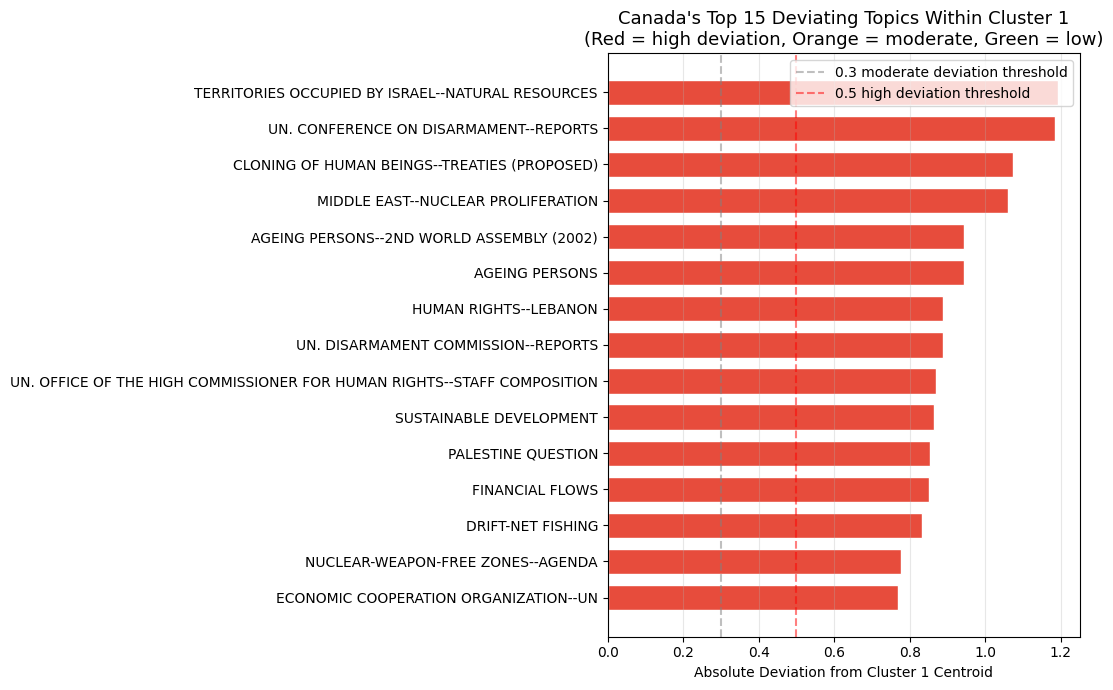

In [ ]:
# Horizontal bar chart of Canada's top 15 deviating topics
# Directly comparable to teammate's US and Israel deviation charts
top_15 = canada_deviation.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#e74c3c' if v > 0.5 else '#f39c12' if v > 0.3 else '#2ecc71'
          for v in top_15.values]

ax.barh(
    top_15.index[::-1],
    top_15.values[::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.7
)

ax.axvline(0.3, linestyle='--', color='gray', alpha=0.5,
            label='0.3 moderate deviation threshold')
ax.axvline(0.5, linestyle='--', color='red', alpha=0.5,
            label='0.5 high deviation threshold')

ax.set_xlabel("Absolute Deviation from Cluster 1 Centroid")
ax.set_title("Canada's Top 15 Deviating Topics Within Cluster 1\n"
             "(Red = high deviation, Orange = moderate, Green = low)",
             fontsize=13)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##Canada vs USA vs Israel deviation comparison

Deviation comparison — Canada vs USA vs Israel (top topics):
                                                     Canada       USA    Israel
subject_split                                                                  
TERRITORIES OCCUPIED BY ISRAEL--NATURAL RESOURCES  1.191382  1.768305  1.768305
UN. CONFERENCE ON DISARMAMENT--REPORTS             1.185185  0.314815  0.314815
CLONING OF HUMAN BEINGS--TREATIES (PROPOSED)       1.074074  0.925926  0.074074
MIDDLE EAST--NUCLEAR PROLIFERATION                 1.061040  1.637963  1.637963
AGEING PERSONS                                     0.944444  0.944444  0.944444
AGEING PERSONS--2ND WORLD ASSEMBLY (2002)          0.944444  0.944444  0.944444
HUMAN RIGHTS--LEBANON                              0.888889  0.888889  0.888889
UN. DISARMAMENT COMMISSION--REPORTS                0.888889  1.888889  0.888889
AFRICAN UNION--UN                                  0.055556  1.944444  0.944444
COASTAL ZONE MANAGEMENT                            0.055556

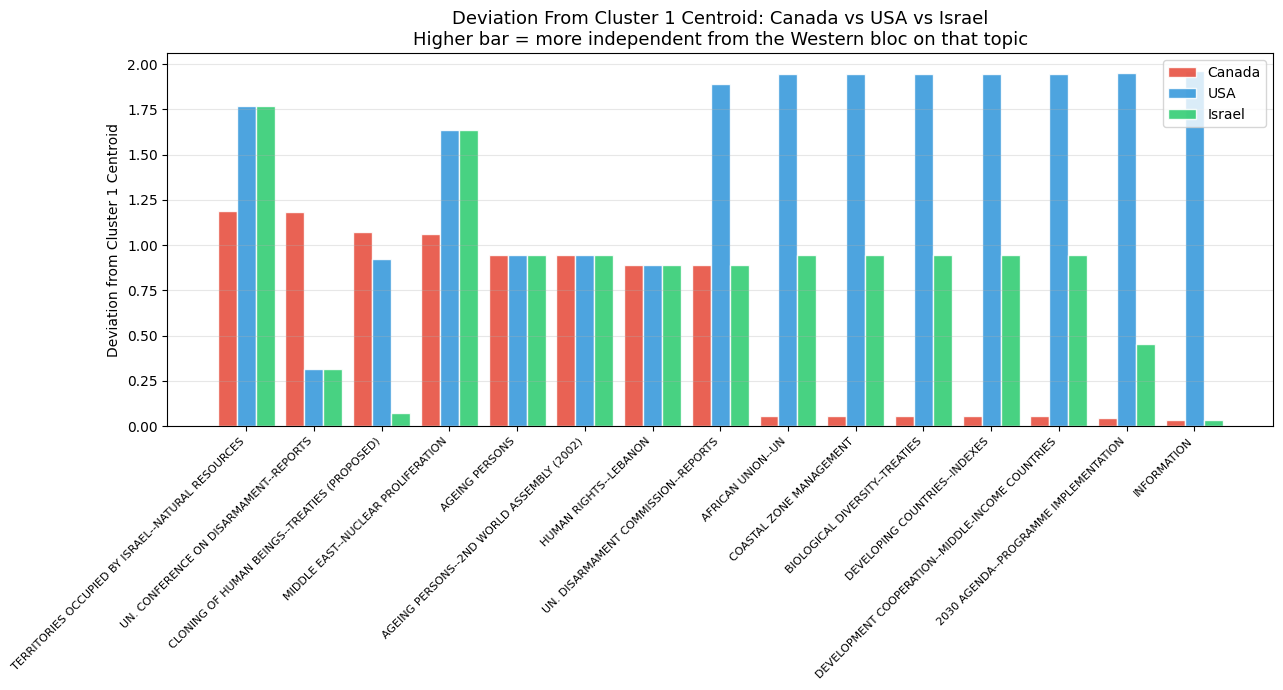

In [ ]:

# Side by side comparison of the three most discussed Cluster 1 countries
# on the topics where they deviate most from the cluster centroid
# This is the direct bridge to teammate's analysis

# Get votes for each country
usa_votes    = country_subject_votes.loc['UNITED STATES'].drop('cluster')
israel_votes = country_subject_votes.loc['ISRAEL'].drop('cluster')

# Per-topic deviation for each country
usa_deviation    = (usa_votes    - cluster_1_centroid).abs()
israel_deviation = (israel_votes - cluster_1_centroid).abs()

# Find the top 12 most divisive topics across all three countries combined
# (union of top deviating topics for each)
top_topics_combined = pd.concat([
    canada_deviation.nlargest(8),
    usa_deviation.nlargest(8),
    israel_deviation.nlargest(8)
]).index.unique()[:15]

# Build comparison dataframe
comparison_deviation = pd.DataFrame({
    'Canada': canada_deviation[top_topics_combined],
    'USA':    usa_deviation[top_topics_combined],
    'Israel': israel_deviation[top_topics_combined]
}).sort_values('Canada', ascending=False)

print("Deviation comparison — Canada vs USA vs Israel (top topics):")
print(comparison_deviation.to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(comparison_deviation))
width = 0.28

ax.bar(x - width,     comparison_deviation['Canada'],
        width, label='Canada', color='#e74c3c',  alpha=0.88, edgecolor='white')
ax.bar(x,             comparison_deviation['USA'],
        width, label='USA',    color='#3498db',  alpha=0.88, edgecolor='white')
ax.bar(x + width,     comparison_deviation['Israel'],
        width, label='Israel', color='#2ecc71',  alpha=0.88, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(
    comparison_deviation.index,
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel("Deviation from Cluster 1 Centroid")
ax.set_title("Deviation From Cluster 1 Centroid: Canada vs USA vs Israel\n"
             "Higher bar = more independent from the Western bloc on that topic",
             fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### What the Deviation Analysis Shows

Canada's overall deviation score places it as one of the most reliable
members of Cluster 1: significantly more conformist than either the
USA or Israel.

 connecting part 1 and part 2

**Part 1:**
Canada was assigned to Cluster 1- the Western liberal democratic bloc.
The USA and Israel are the biggest deviators within that cluster.

**Part 2:**
Canada's vote is 83.1% predictable from its bloc- but that average
hides the Israel-Palestine topic where Canada departs from its bloc
76% of the time.


Canada is a reliable Western bloc member on almost every issue EXCEPT
Israel-Palestine, where it has historically taken a more independent
position than the USA or Israel. The Trump period temporarily increased
Canada-USA alignment on Israel-Palestine (+0.67) but also created the
largest ever divergence on Development topics (-0.57) due to US
withdrawal from multilateral frameworks.

The post-2023 drop in overall Canada-USA alignment visible in Chart 3
likely reflects the widening Israel-Palestine divergence following
October 2023.

#### Geopolitical Deep Dives — Canada's Year by Year Trends

<span style="color:red;">Rephrased the section below. Can be removed. (The model and alignment analyses tell us *how predictable* Canada is. This section asks *how Canada's position has actually moved over time* on four specific topics that are most relevant to current events. These are descriptive analyses of Canada's historical voting record, not model predictions,  and are intended to ground the quantitative findings in real-world geopolitical context.

The four topics are: **Israel-Palestine** (did Canada's position shift post-October 2023?), **Nuclear Weapons** (how does Canada balance disarmament rhetoric with NATO obligations?), **AI and Cybercrime** (Canada's position on tech governance at the UN), and **Ukraine and Sovereignty** (Canada's response to the 2022 invasion).)</span>

We now zoom into four specific topic areas that are most relevant to
current geopolitical events and track Canada's voting position year
by year from 2000 to present.

These are not model predictions — this is Canada's actual historical
voting record on each topic, showing how Canada's position has evolved
over time and whether major world events created visible shifts.

Topics we examine:
1. **Israel–Palestine** — has Canada's position shifted post-Oct 2023?
2. **Nuclear Weapons** — tension between disarmament advocacy and NATO
3. **AI and Cybercrime** — Canada's position on tech governance at the UN
4. **Ukraine and Sovereignty** — Canada's response to the 2022 invasion

<span style="color:red;">(can remove from analysis if this is extra)</span>


In [ ]:
# Filter df_filtered to Canada's rows only
canada_history = df_filtered[df_filtered['ms_name'] == 'CANADA'].copy()

# Function to get Canada's average vote per year on a topic pattern
def canada_trend(pattern, label):
    subset = canada_history[
        canada_history['subject_split'].str.contains(
            pattern, na=False, regex=True
        )
    ]
    trend = (
        subset.groupby('year')['vote_num']
        .mean()
        .reset_index()
    )
    trend.columns = ['year', 'avg_vote']
    trend['topic'] = label
    return trend

# Build trend data for each deep dive topic
palestine_trend  = canada_trend(
    r"PALESTINE QUESTION|TERRITORIES OCCUPIED BY ISRAEL|MIDDLE EAST SITUATION",
    "Israel–Palestine"
)
nuclear_trend    = canada_trend(
    r"NUCLEAR DISARMAMENT|NUCLEAR WEAPONS|NUCLEAR NON-PROLIFERATION",
    "Nuclear Weapons"
)
tech_trend       = canada_trend(
    r"CYBERCRIME|INFORMATION--INTERNATIONAL SECURITY|ARTIFICIAL INTELLIGENCE",
    "AI & Cybercrime"
)
ukraine_trend    = canada_trend(
    r"UKRAINE--POLITICAL CONDITIONS|HUMAN RIGHTS--UKRAINE",
    "Ukraine & Sovereignty"
)

print("Data points per topic:")
print(f"  Israel–Palestine:    {len(palestine_trend)} years")
print(f"  Nuclear Weapons:     {len(nuclear_trend)} years")
print(f"  AI & Cybercrime:     {len(tech_trend)} years")
print(f"  Ukraine & Sov:       {len(ukraine_trend)} years")

Data points per topic:
  Israel–Palestine:    26 years
  Nuclear Weapons:     25 years
  AI & Cybercrime:     11 years
  Ukraine & Sov:       10 years


##Israel–Palestine trend

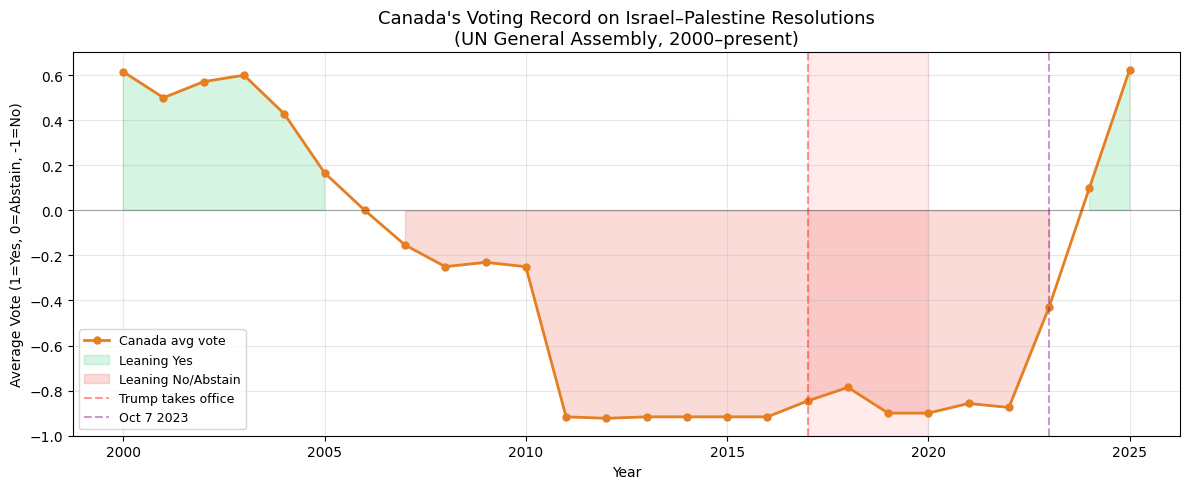

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    palestine_trend['year'],
    palestine_trend['avg_vote'],
    marker='o', linewidth=2,
    color='#e67e22', markersize=5,
    label='Canada avg vote'
)

# Fill above/below zero to show Yes vs No/Abstain lean
ax.fill_between(
    palestine_trend['year'],
    palestine_trend['avg_vote'],
    0,
    where=palestine_trend['avg_vote'] > 0,
    alpha=0.2, color='#2ecc71', label='Leaning Yes'
)
ax.fill_between(
    palestine_trend['year'],
    palestine_trend['avg_vote'],
    0,
    where=palestine_trend['avg_vote'] < 0,
    alpha=0.2, color='#e74c3c', label='Leaning No/Abstain'
)

# Key event markers
ax.axvline(2017, color='red',    alpha=0.4, linestyle='--', label='Trump takes office')
ax.axvline(2023, color='purple', alpha=0.4, linestyle='--', label='Oct 7 2023')
ax.axhline(0,    color='black',  linewidth=0.8, linestyle='-', alpha=0.3)

ax.axvspan(2017, 2020, color='red', alpha=0.08)

ax.set_title("Canada's Voting Record on Israel–Palestine Resolutions\n"
             "(UN General Assembly, 2000–present)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Average Vote (1=Yes, 0=Abstain, -1=No)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

For PPT? Canada shifted dramatically back toward Yes on Palestinian resolutions after October 7 — a visible and measurable policy shift in the UN voting record

##NUCLEAR WEAPONS

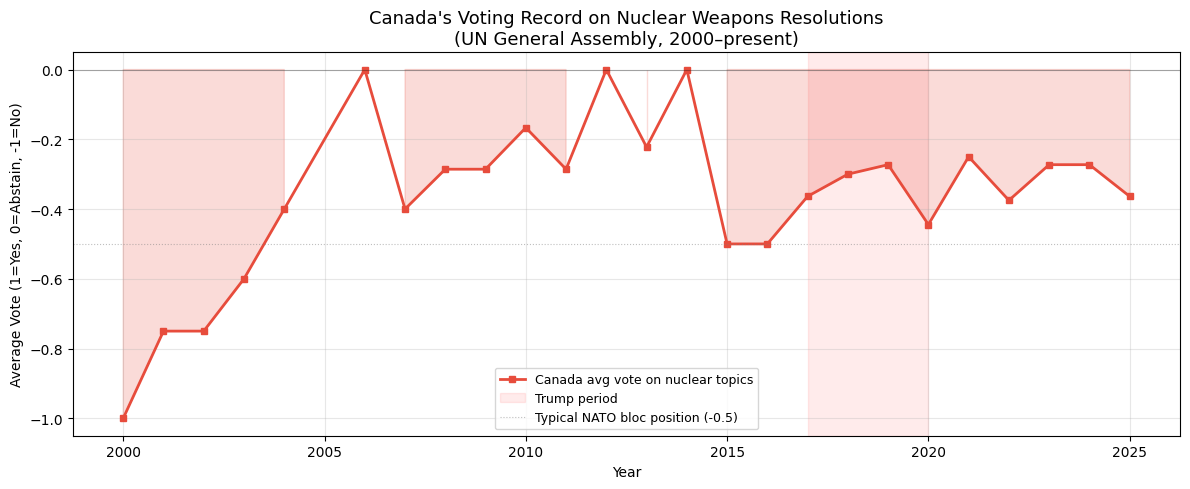

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    nuclear_trend['year'],
    nuclear_trend['avg_vote'],
    marker='s', linewidth=2,
    color='#e74c3c', markersize=5,
    label='Canada avg vote on nuclear topics'
)

ax.fill_between(
    nuclear_trend['year'],
    nuclear_trend['avg_vote'],
    0,
    where=nuclear_trend['avg_vote'] > 0,
    alpha=0.2, color='#2ecc71'
)
ax.fill_between(
    nuclear_trend['year'],
    nuclear_trend['avg_vote'],
    0,
    where=nuclear_trend['avg_vote'] < 0,
    alpha=0.2, color='#e74c3c'
)

ax.axvspan(2017, 2020, color='red', alpha=0.08, label='Trump period')
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# NATO nuclear policy reference
ax.axhline(-0.5, color='gray', linewidth=0.8, linestyle=':',
            alpha=0.5, label='Typical NATO bloc position (-0.5)')

ax.set_title("Canada's Voting Record on Nuclear Weapons Resolutions\n"
             "(UN General Assembly, 2000–present)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Average Vote (1=Yes, 0=Abstain, -1=No)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Canada has never voted Yes on nuclear resolutions since 2000. It consistently abstains or votes No, aligned with its NATO obligations despite stated disarmament policy.

The oscillation around -0.3 to -0.5 could be Canada threading the needle between its disarmament rhetoric and alliance obligations.

##AI, Cybercrime and Ukraine

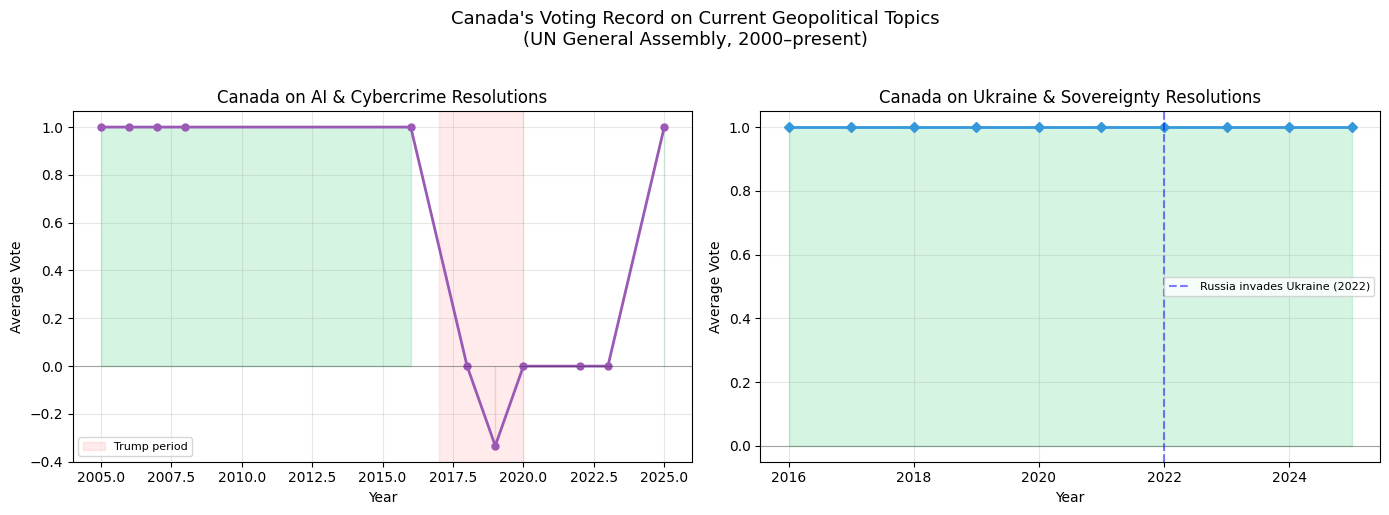

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AI & Cybercrime
axes[0].plot(
    tech_trend['year'],
    tech_trend['avg_vote'],
    marker='o', linewidth=2,
    color='#9b59b6', markersize=5
)
axes[0].fill_between(
    tech_trend['year'], tech_trend['avg_vote'], 0,
    where=tech_trend['avg_vote'] > 0,
    alpha=0.2, color='#2ecc71'
)
axes[0].fill_between(
    tech_trend['year'], tech_trend['avg_vote'], 0,
    where=tech_trend['avg_vote'] < 0,
    alpha=0.2, color='#e74c3c'
)
axes[0].axhline(0, color='black', linewidth=0.8, alpha=0.3)
axes[0].axvspan(2017, 2020, color='red', alpha=0.08, label='Trump period')
axes[0].set_title("Canada on AI & Cybercrime Resolutions", fontsize=12)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Vote")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: Ukraine & Sovereignty
axes[1].plot(
    ukraine_trend['year'],
    ukraine_trend['avg_vote'],
    marker='D', linewidth=2,
    color='#3498db', markersize=5
)
axes[1].fill_between(
    ukraine_trend['year'], ukraine_trend['avg_vote'], 0,
    where=ukraine_trend['avg_vote'] > 0,
    alpha=0.2, color='#2ecc71'
)
axes[1].fill_between(
    ukraine_trend['year'], ukraine_trend['avg_vote'], 0,
    where=ukraine_trend['avg_vote'] < 0,
    alpha=0.2, color='#e74c3c'
)
axes[1].axhline(0, color='black', linewidth=0.8, alpha=0.3)
axes[1].axvline(2022, color='blue', alpha=0.5, linestyle='--',
                 label='Russia invades Ukraine (2022)')
axes[1].set_title("Canada on Ukraine & Sovereignty Resolutions", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Vote")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Canada's Voting Record on Current Geopolitical Topics\n"
             "(UN General Assembly, 2000–present)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The Trump period crash on cybercrime - his likely reflects Russia and China pushing UN cybercrime resolutions that Western countries (including Canada) increasingly opposed as tools for internet censorship. Canada shifted from Yes to Abstain as the nature of these resolutions changed. (Will have to add article/ citations for this analysis)

Ukraine: Canada's support for sovereignty resolutions was already at maximum before the Ukraine invasion. Stays the same after invasion. Its Vote on 'soveriengty' - we can also see it behave in the same line with Palestine. but don't ahve to include this to keep it from getting "too political".

<span style="color:red;"> ADD IN FINAL SUMMARY ANALYSIS here </span>

---

## Conclusions

### Q1 — Do geopolitical blocs exist and persist?

**Yes.** Agglomerative clustering (Ward linkage, k=3) on a country × voting-topic matrix identifies three stable and interpretable blocs: a Western liberal democratic cluster (Cluster 1), a strategic non-aligned / middle-power cluster, and a developing-state cluster. Transition matrices across decades confirm that the vast majority of countries remain in the same cluster from one decade to the next. The geopolitical structure visible in UN voting is not a temporary coalition; it is a persistent feature of the international system.

### Q2 — What causes deviations?

**Issue area matters more than time.** Within Cluster 1, the United States (deviation score 19.5) and Israel (15.0) are by far the least reliable bloc members, driven primarily by their distinctive positions on Israel-Palestine, sovereignty, and nuclear resolutions. Canada's overall deviation score is much lower, confirming it is one of the most conformist members of its bloc. However, Canada is a dramatic outlier on **Israel-Palestine specifically**, departing from its Western bloc consensus 76% of the time, a pattern that intensified further after October 2023. The UNSC Iran application further validates this: the Human Rights model, not Security or Sovereignty, was most predictive of real-world bloc behaviour, and climate/environmental resolutions stand out as the notable exception to issue-driven deviation, showing high within-bloc consensus even among countries that diverge sharply on other topics.Temporal disruptions are also visible: the Trump period (2017–2020) reduced Canada-USA alignment on Development topics (-0.57 similarity shift) while paradoxically increasing alignment on Israel-Palestine (+0.67), likely as US positions shifted toward Canada's historical abstain stance.

### Q3 — Can bloc membership predict how Canada votes?

**Largely yes, with important caveats.** Our Random Forest classifier predicts Canada's vote with **88.3% overall accuracy** on held-out resolutions from 2020 onwards. Canada follows its Cluster 1 bloc consensus 83.1% of the time. On most topics, sovereignty, security/nuclear, development, decolonization, the model's accuracy closely tracks Canada's bloc alignment, suggesting the model is essentially learning bloc membership. The exception is **Israel-Palestine**, where Canada departs from its bloc 76% of the time, yet the model still achieves 72% accuracy, evidence that it has learned Canada's independent voting pattern on this topic rather than simply predicting the bloc. Abstentions are the hardest class to predict across all models, consistent with the interpretation that abstaining is a diplomatic nuance that bloc logic does not capture.